# Driver Scheduling for Ride-Hailing Service 

## Objectives

The objective of this project is to support taxi drivers and operators in making better decisions about where and when to operate in Manhattan.

Specifically, the goal is to:
- predict demand and revenue at a given location and time
- provide insights such as optimal zones and times to maximise earnings

The output of the model could be used by:
- drivers choosing where to position themselves  
- zone operators allocating groups of drivers  

## Performance Measures

Performance will be evaluated using regression metrics such as:
- Mean Squared Error  
- Root Mean Squared Error 

RMSE is preferred because:
- it is on the same scale as the target variable  
- it penalises large errors strognly  


## Imports and Configs

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DATA_DIR = Path("data")
TRIP_FILE_PATTERN = "nyc_taxi_2024-*.csv"
LOOKUP_PATH = DATA_DIR / "taxi_zone_lookup.csv"

CHUNK_SIZE = 250_000
EDA_SAMPLE_TARGET_ROWS = 300_000
RANDOM_STATE = 42

AIRPORT_LOCATION_IDS = {1, 132, 138}   # Newark, JFK, LaGuardia

## Organise the Data

### Identify Manhattan pickup zones

In [2]:
def get_trip_files(data_dir: Path, pattern: str) -> list[Path]:
    files = sorted(data_dir.glob(pattern))
    if not files:
        raise FileNotFoundError(
            f"No trip files found in {data_dir.resolve()} matching {pattern}"
        )
    return files


def load_zone_lookup(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"Missing lookup file: {path.resolve()}")

    df = pd.read_csv(path)

    required = {"LocationID", "Borough", "Zone"}
    if not required.issubset(df.columns):
        raise ValueError("Zone lookup missing required columns")

    return df


trip_files = get_trip_files(DATA_DIR, TRIP_FILE_PATTERN)
zone_lookup = load_zone_lookup(LOOKUP_PATH)

manhattan_lookup = zone_lookup[zone_lookup["Borough"] == "Manhattan"].copy()
manhattan_ids = set(manhattan_lookup["LocationID"].astype(int))

print(f"Found {len(trip_files)} files")
print(f"Manhattan zones: {len(manhattan_ids)}")

display(manhattan_lookup.head())

Found 12 files
Manhattan zones: 69


,LocationID,Borough,Zone,service_zone
3,4,Manhattan,Alphabet City,Yellow Zone
11,12,Manhattan,Battery Park,Yellow Zone
12,13,Manhattan,Battery Park City,Yellow Zone
23,24,Manhattan,Bloomingdale,Yellow Zone
40,41,Manhattan,Central Harlem,Boro Zone


### Load Raw Trip Data

In [3]:
COLS_NEEDED = [
    "tpep_pickup_datetime", "tpep_dropoff_datetime",
    "PULocationID", "DOLocationID", "trip_distance",
    "fare_amount", "tip_amount", "total_amount",
    "passenger_count", "RatecodeID", "payment_type",
    "extra", "mta_tax", "tolls_amount",
    "improvement_surcharge", "congestion_surcharge",
    "Airport_fee", "store_and_fwd_flag", "VendorID"
]

chunks = []
for file in trip_files:
    for chunk in pd.read_csv(file, chunksize=CHUNK_SIZE, usecols=COLS_NEEDED):
        chunk = chunk[chunk["PULocationID"].isin(manhattan_ids)]
        
        # Downcast floats
        float_cols = [
            "trip_distance", "fare_amount", "tip_amount", "total_amount",
            "extra", "mta_tax", "tolls_amount", "improvement_surcharge",
            "congestion_surcharge", "Airport_fee"
        ]
        for col in float_cols:
            if col in chunk.columns:
                chunk[col] = pd.to_numeric(chunk[col], errors="coerce").astype("float32")

        # Downcast ints from int64 
        int_cols = {
            "PULocationID": "int16",
            "DOLocationID": "int16", 
            "passenger_count": "int8",
            "RatecodeID": "int8",
            "payment_type": "int8",
            "VendorID": "int8"
        }
        for col, dtype in int_cols.items():
            if col in chunk.columns:
                chunk[col] = pd.to_numeric(chunk[col], errors="coerce").fillna(0).astype(dtype)

        chunks.append(chunk)

taxi_raw = pd.concat(chunks, ignore_index=True)
print(f"RAM: {taxi_raw.memory_usage(deep=True).sum() / 1e9:.2f} GB")
print(f"Shape: {taxi_raw.shape}")

/tmp/ipykernel_909702/1580658756.py:13: DtypeWarning: Columns (0: store_and_fwd_flag) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(file, chunksize=CHUNK_SIZE, usecols=COLS_NEEDED):
/tmp/ipykernel_909702/1580658756.py:13: DtypeWarning: Columns (0: store_and_fwd_flag) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(file, chunksize=CHUNK_SIZE, usecols=COLS_NEEDED):
/tmp/ipykernel_909702/1580658756.py:13: DtypeWarning: Columns (0: store_and_fwd_flag) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(file, chunksize=CHUNK_SIZE, usecols=COLS_NEEDED):
/tmp/ipykernel_909702/1580658756.py:13: DtypeWarning: Columns (0: store_and_fwd_flag) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(file, chunksize=CHUNK_SIZE, usecols=COLS_NEEDED):
/tmp/ipykernel_909702/1580658756.py:13: DtypeWarning

RAM: 8.45 GB
Shape: (36402062, 19)


## Test Set Creation

As the dataset is time based, a random split would break temporal structure and introduce data leakage. Therefore, a calendar based time split is used.

For each month, the first three weeks of data are used for training. The final week of each month is reserved for evaluation, with a further split across the year:
- Validation set: last week of each month from January to June
- Test set: last week of each month from July to December

In [4]:
def split_by_requested_periods(df):
    """
    Requested split:
      - train: first 3 weeks (days 1-21) of every month
      - validation: last 7 days of months Jan-Jun
      - test: last 7 days of months Jul-Dec

    Any gap between day 22 and the start of the final 7 days is excluded.
    This keeps the split faithful to the user request and avoids leakage.
    """
    df = df.copy()
    df["pickup_datetime"] = pd.to_datetime(df["tpep_pickup_datetime"], errors="coerce")
    df = df.dropna(subset=["pickup_datetime"])

    month = df["pickup_datetime"].dt.month
    day = df["pickup_datetime"].dt.day
    days_in_month = df["pickup_datetime"].dt.days_in_month

    is_train = day <= 21
    is_last_week = day > (days_in_month - 7)

    train = df[is_train].copy()
    val   = df[is_last_week & (month <= 6)].copy()
    test  = df[is_last_week & (month >= 7)].copy()

    assigned_mask = is_train | is_last_week
    dropped = int((~assigned_mask).sum())

    print("Requested temporal split applied:")
    print("  Train      = first 3 weeks of every month")
    print("  Validation = last 7 days of Jan-Jun")
    print("  Test       = last 7 days of Jul-Dec")
    print(f"  Excluded gap rows between these periods: {dropped:,}")

    return train, val, test

taxi_raw = taxi_raw[taxi_raw["PULocationID"].isin(manhattan_ids)]

train_df, val_df, test_df = split_by_requested_periods(taxi_raw)

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)
print(list(taxi_raw.columns))

Requested temporal split applied:
  Train      = first 3 weeks of every month
  Validation = last 7 days of Jan-Jun
  Test       = last 7 days of Jul-Dec
  Excluded gap rows between these periods: 2,909,342
Train shape: (25632734, 20)
Validation shape: (4045829, 20)
Test shape: (3814157, 20)
['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'Airport_fee']


# Remove Erroreous or Invalid

In [5]:
def filter_erroneous_records(df):
    """
    Basic sanity filtering for NYC taxi data.
    Keeps rules simple and defensible.
    """
    df = df.copy()

    #Ensure datetime parsed
    df["tpep_pickup_datetime"] = pd.to_datetime(
        df["tpep_pickup_datetime"], errors="coerce"
    )

    #Drop missing/invalid timestamps
    df = df.dropna(subset=["tpep_pickup_datetime"])

    #Drop clearly invalid fares (keep only positive, cap extreme outliers)
    if "total_amount" in df.columns:
        df = df[df["total_amount"] > 0]
        df = df[df["total_amount"] < df["total_amount"].quantile(0.999)]

    #Drop clearly invalid distances (if present)
    if "trip_distance" in df.columns:
        df = df[df["trip_distance"] > 0]
        df = df[df["trip_distance"] < df["trip_distance"].quantile(0.999)]

    #Optional: remove zero-duration or extreme durations (if dropoff exists)
    if "tpep_dropoff_datetime" in df.columns:
        df["tpep_dropoff_datetime"] = pd.to_datetime(
            df["tpep_dropoff_datetime"], errors="coerce"
        )
        valid_time = df["tpep_dropoff_datetime"] > df["tpep_pickup_datetime"]
        df = df[valid_time | df["tpep_dropoff_datetime"].isna()]

    #remove impossible passenger counts (if present)
    if "passenger_count" in df.columns:
        df = df[(df["passenger_count"] > 0) & (df["passenger_count"] <= 6)]

    return df

In [6]:
train_df = filter_erroneous_records(train_df)
val_df   = filter_erroneous_records(val_df)
test_df  = filter_erroneous_records(test_df)

# Reusable Transforms

In [7]:
def add_time_features(df):
    df = df.copy()

    df["pickup_datetime"] = pd.to_datetime(df["tpep_pickup_datetime"], errors="coerce")

    df["pickup_hour"] = df["pickup_datetime"].dt.hour
    df["pickup_dayofweek"] = df["pickup_datetime"].dt.dayofweek
    df["pickup_month"] = df["pickup_datetime"].dt.month
    df["pickup_date"] = df["pickup_datetime"].dt.date

    return df

def safe_mode(series):
    mode = series.mode()
    return mode.iloc[0] if not mode.empty else None
def aggregate_hourly(df):
    df = df.copy()

    df["pickup_datetime"] = pd.to_datetime(df["tpep_pickup_datetime"], errors="coerce")
    df["pickup_datetime_hour"] = df["pickup_datetime"].dt.floor("h")

    grouped = df.groupby(["PULocationID", "pickup_datetime_hour"])

    agg_df = grouped.agg(
        demand=("VendorID", "count"),
        avg_trip_distance=("trip_distance", "mean"),
        avg_fare=("fare_amount", "mean"),
        avg_tip=("tip_amount", "mean"),
        avg_total_amount=("total_amount", "mean"),
        total_revenue=("total_amount", "sum"),
    ).reset_index()

    return agg_df

# Data Exploration

First we explore the features and shape of the files 

In [8]:
def create_eda_sample(df, n=500_000, random_state=42):
    return df.sample(n=min(len(df), n), random_state=random_state)


train_explore = add_time_features(train_df)

# raw sample (for detailed EDA)
train_sample = create_eda_sample(train_explore)

print("Sample shape:", train_sample.shape)

# aggregated dataset (for structured analysis)
train_agg = aggregate_hourly(train_explore)

print("Aggregated shape:", train_agg.shape)

display(train_agg.head())

Sample shape: (500000, 24)
Aggregated shape: (340955, 8)


,PULocationID,pickup_datetime_hour,demand,avg_trip_distance,avg_fare,avg_tip,avg_total_amount,total_revenue
0,4,2024-01-01 00:00:00,20,3.260000,21.270000,3.514000,29.784000,595.679993
1,4,2024-01-01 01:00:00,22,3.704091,21.677273,4.015454,30.692726,675.239990
2,4,2024-01-01 02:00:00,28,3.966786,24.142857,3.630357,32.737499,916.650024
3,4,2024-01-01 03:00:00,16,3.320625,18.443750,4.198125,27.641876,442.270020
4,4,2024-01-01 04:00:00,10,1.688000,11.750000,1.492000,18.242001,182.419998


In [9]:
print(train_agg["demand"].describe())
train_agg.sort_values("demand", ascending=False).head(10)

count    340955.000000
mean         65.095089
std          81.929218
min           1.000000
25%           7.000000
50%          32.000000
75%          95.000000
max        1005.000000
Name: demand, dtype: float64


,PULocationID,pickup_datetime_hour,demand,avg_trip_distance,avg_fare,avg_tip,avg_total_amount,total_revenue
74212,79,2024-11-03 01:00:00,1005,2.298527,13.966666,2.752279,21.751671,21860.429688
293045,237,2024-12-18 18:00:00,753,1.516574,13.771581,3.232191,23.541462,17726.720703
74188,79,2024-11-02 01:00:00,723,2.265339,14.206778,3.000525,22.247856,16085.200195
152007,142,2024-12-12 21:00:00,719,2.464103,17.608067,3.680960,26.345106,18942.130859
191589,161,2024-11-14 18:00:00,694,1.988790,16.218731,3.793415,26.797247,18597.289062
292616,237,2024-11-21 18:00:00,692,1.598627,14.518786,3.337673,24.404610,16887.990234
292902,237,2024-12-12 18:00:00,692,1.487616,15.228613,3.397948,25.171358,17418.580078
148286,142,2024-05-03 22:00:00,689,2.435747,15.423947,3.265515,23.741829,16358.120117
287021,236,2024-12-18 18:00:00,688,1.575044,13.040406,3.055916,22.683647,15606.349609
168879,148,2024-11-03 01:00:00,686,2.525714,15.235277,2.869504,23.124649,15863.509766


# Demand - Location

Now we investigate the relationship between demand and location. 

### General Demand Across Locations

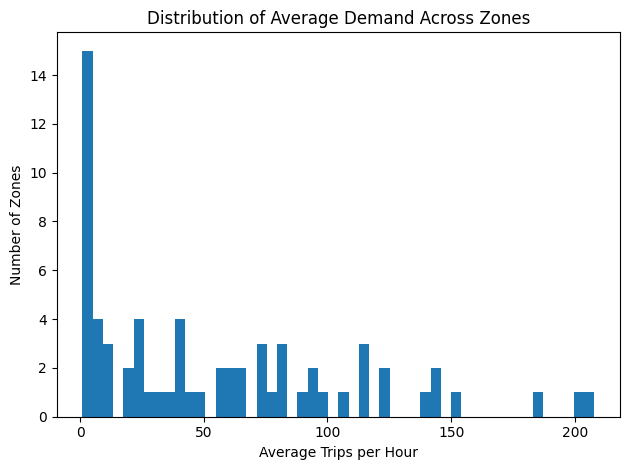

In [10]:
# average demand per zone
demand_by_zone = (
    train_agg.groupby("PULocationID")["demand"]
    .mean()
)

# plot histogram
plt.figure()
plt.hist(demand_by_zone, bins=50)

plt.title("Distribution of Average Demand Across Zones")
plt.xlabel("Average Trips per Hour")
plt.ylabel("Number of Zones")

plt.tight_layout()
plt.show()

We observe a large variation of different average demands across zones.

In [11]:
print(train_agg["demand"].describe())
train_agg.sort_values("demand", ascending=False).head(10)

count    340955.000000
mean         65.095089
std          81.929218
min           1.000000
25%           7.000000
50%          32.000000
75%          95.000000
max        1005.000000
Name: demand, dtype: float64


,PULocationID,pickup_datetime_hour,demand,avg_trip_distance,avg_fare,avg_tip,avg_total_amount,total_revenue
74212,79,2024-11-03 01:00:00,1005,2.298527,13.966666,2.752279,21.751671,21860.429688
293045,237,2024-12-18 18:00:00,753,1.516574,13.771581,3.232191,23.541462,17726.720703
74188,79,2024-11-02 01:00:00,723,2.265339,14.206778,3.000525,22.247856,16085.200195
152007,142,2024-12-12 21:00:00,719,2.464103,17.608067,3.680960,26.345106,18942.130859
191589,161,2024-11-14 18:00:00,694,1.988790,16.218731,3.793415,26.797247,18597.289062
292616,237,2024-11-21 18:00:00,692,1.598627,14.518786,3.337673,24.404610,16887.990234
292902,237,2024-12-12 18:00:00,692,1.487616,15.228613,3.397948,25.171358,17418.580078
148286,142,2024-05-03 22:00:00,689,2.435747,15.423947,3.265515,23.741829,16358.120117
287021,236,2024-12-18 18:00:00,688,1.575044,13.040406,3.055916,22.683647,15606.349609
168879,148,2024-11-03 01:00:00,686,2.525714,15.235277,2.869504,23.124649,15863.509766


# Revenue + Location EDA

In [12]:
# Derive time components from aggregated data
train_agg["hour"] = train_agg["pickup_datetime_hour"].dt.hour
train_agg["dayofweek"] = train_agg["pickup_datetime_hour"].dt.dayofweek
train_agg["month"] = train_agg["pickup_datetime_hour"].dt.month
train_agg["date"] = train_agg["pickup_datetime_hour"].dt.date

DAY_LABELS = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
MONTH_LABELS = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

## Distribution of total_revenue

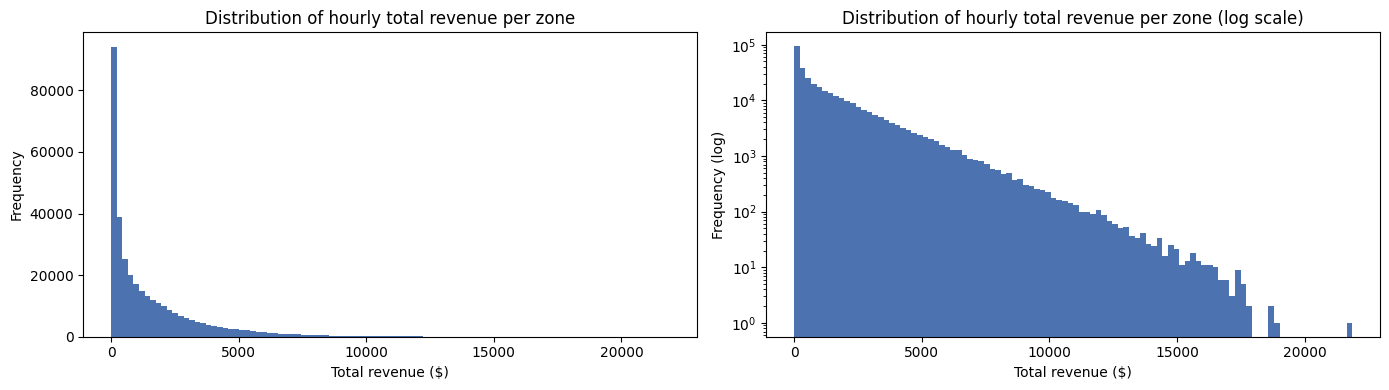

95th percentile: $5546.83
99th percentile: $8817.62
Max: $21860.43


In [13]:
plt.figure(figsize=(14, 4))

plt.subplot(1, 2, 1)
plt.hist(train_agg["total_revenue"], bins=100, color="#4C72B0", edgecolor="none")
plt.title("Distribution of hourly total revenue per zone")
plt.xlabel("Total revenue ($)")
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
plt.hist(train_agg["total_revenue"], bins=100, color="#4C72B0", edgecolor="none", log=True)
plt.title("Distribution of hourly total revenue per zone (log scale)")
plt.xlabel("Total revenue ($)")
plt.ylabel("Frequency (log)")

plt.tight_layout()
plt.show()

p95 = train_agg["total_revenue"].quantile(0.95)
p99 = train_agg["total_revenue"].quantile(0.99)
print(f"95th percentile: ${p95:.2f}")
print(f"99th percentile: ${p99:.2f}")
print(f"Max: ${train_agg['total_revenue'].max():.2f}")

Above we observe an exponential fall off in revenue as a few zones dominate followed by a long tail. 

## Top and bottom zones by mean hourly revenue

We now investigate the highest and lowest hourly zones by revenue.

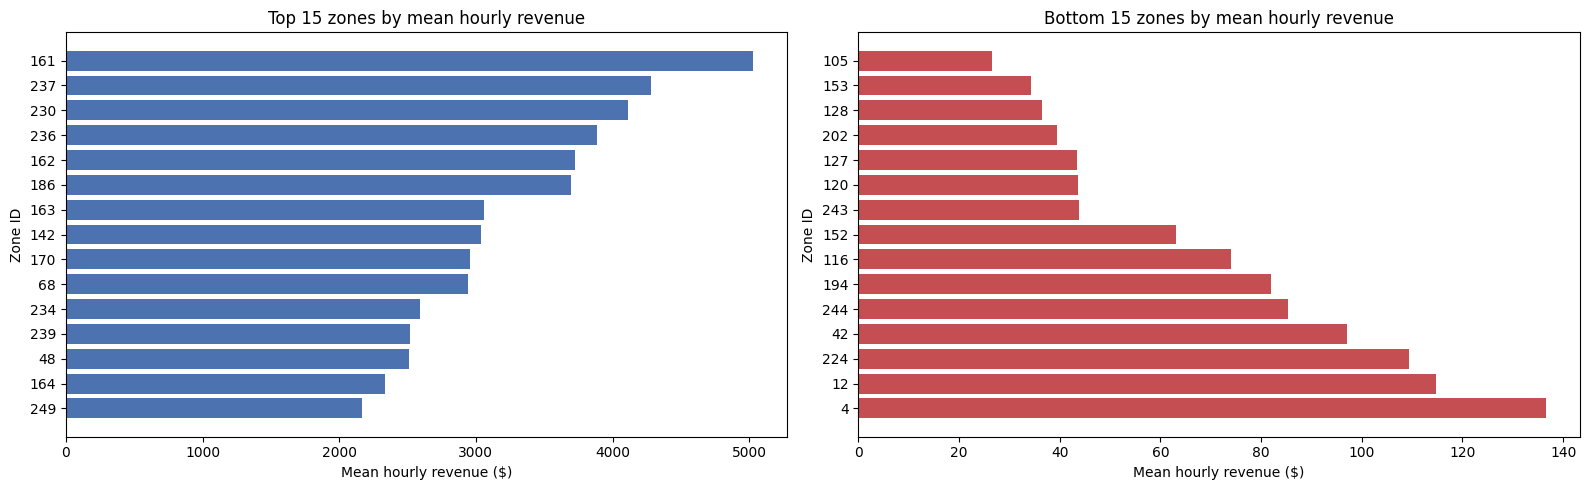

Top 5 zones by mean hourly revenue:
   PULocationID  mean_hourly_revenue
0           161          5028.978516
1           237          4283.123047
2           230          4115.706055
3           236          3889.393555
4           162          3726.354736


In [14]:
zone_revenue = (
    train_agg.groupby("PULocationID")["total_revenue"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)
zone_revenue.columns = ["PULocationID", "mean_hourly_revenue"]

top_n = 15
top_zones = zone_revenue.head(top_n)
bot_zones = zone_revenue.tail(top_n).sort_values("mean_hourly_revenue")

plt.figure(figsize=(16, 5))

plt.subplot(1, 2, 1)
plt.barh(top_zones["PULocationID"].astype(str), top_zones["mean_hourly_revenue"],
         color="#4C72B0")
plt.title(f"Top {top_n} zones by mean hourly revenue")
plt.xlabel("Mean hourly revenue ($)")
plt.ylabel("Zone ID")
plt.gca().invert_yaxis()

plt.subplot(1, 2, 2)
plt.barh(bot_zones["PULocationID"].astype(str), bot_zones["mean_hourly_revenue"],
         color="#C44E52")
plt.title(f"Bottom {top_n} zones by mean hourly revenue")
plt.xlabel("Mean hourly revenue ($)")
plt.ylabel("Zone ID")
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

print("Top 5 zones by mean hourly revenue:")
print(top_zones.head())

Above we see very high disparities between our highest and lowest zones as expected.

## Revenue vs demand relationship

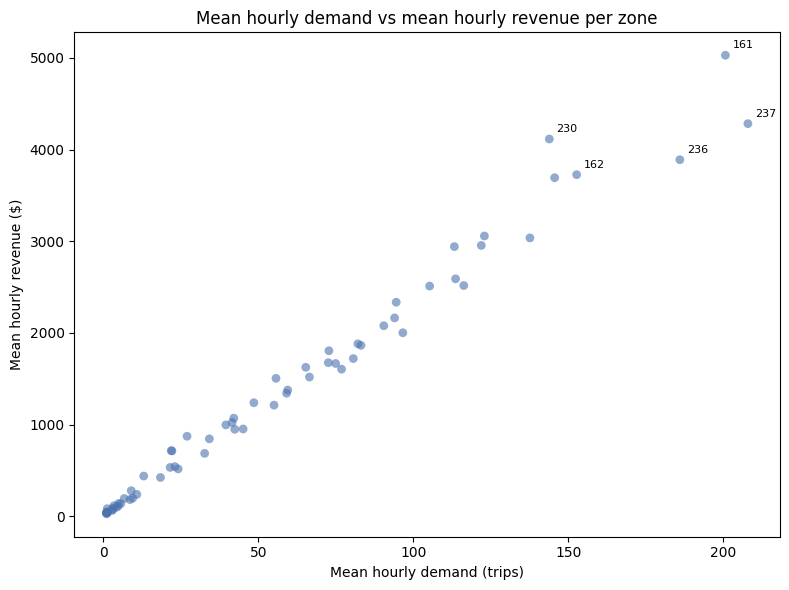

Correlation between mean demand and mean revenue across zones: 0.991


In [15]:
zone_summary = train_agg.groupby("PULocationID").agg(
    mean_demand=("demand", "mean"),
    mean_revenue=("total_revenue", "mean")
).reset_index()

plt.figure(figsize=(8, 6))
plt.scatter(zone_summary["mean_demand"], zone_summary["mean_revenue"],
            alpha=0.6, color="#4C72B0", edgecolors="none", s=40)
plt.title("Mean hourly demand vs mean hourly revenue per zone")
plt.xlabel("Mean hourly demand (trips)")
plt.ylabel("Mean hourly revenue ($)")

for _, row in zone_summary.nlargest(5, "mean_revenue").iterrows():
    plt.annotate(str(int(row["PULocationID"])),
                 xy=(row["mean_demand"], row["mean_revenue"]),
                 xytext=(5, 5), textcoords="offset points", fontsize=8)

plt.tight_layout()
plt.show()

corr = zone_summary["mean_demand"].corr(zone_summary["mean_revenue"])
print(f"Correlation between mean demand and mean revenue across zones: {corr:.3f}")

We see a high correlation between our hourly demand and revenue as expected. Showing a strong relation between our target variables.

## Geopandas test

In [16]:
import geopandas as gpd

# Load and prepare shapefile
SHAPEFILE_PATH = DATA_DIR / "taxi_zones" / "taxi_zones.shp"
zones_geo = gpd.read_file(SHAPEFILE_PATH)

# Filter to Manhattan only
manhattan_geo = zones_geo[zones_geo["borough"] == "Manhattan"].copy()

# Prepare revenue summary
zone_revenue = (
    train_agg.groupby("PULocationID")["total_revenue"]
    .mean()
    .reset_index()
)
zone_revenue.columns = ["LocationID", "mean_hourly_revenue"]

# Join revenue onto shapefile
manhattan_geo = manhattan_geo.merge(zone_revenue, on="LocationID", how="left")

## Geopandas graphs

### Mean hourly revenue chloropleth

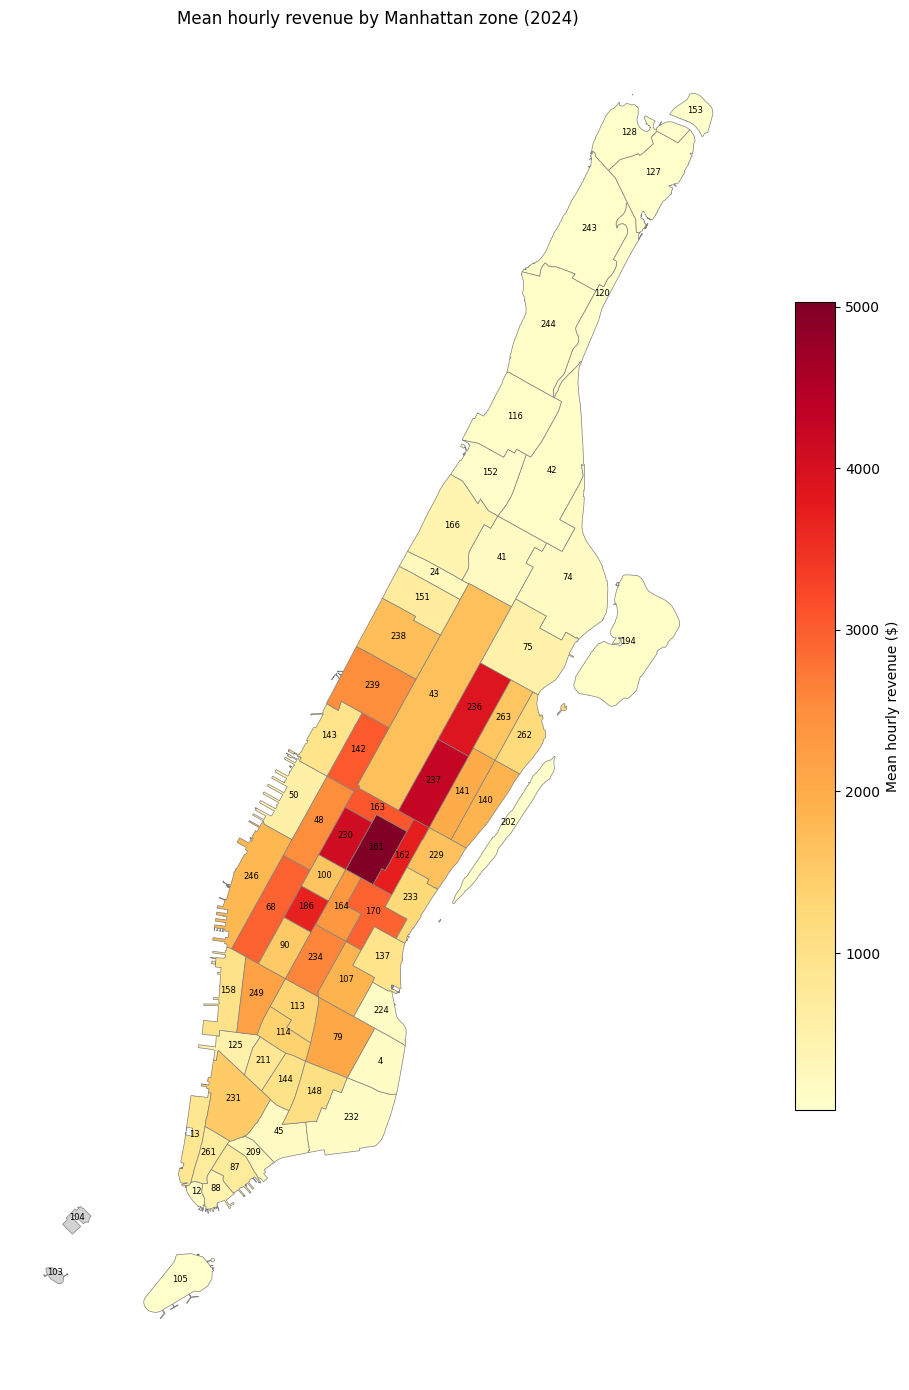

In [17]:
plt.figure(figsize=(10, 14))
ax = plt.gca()

manhattan_geo.plot(
    column="mean_hourly_revenue",
    cmap="YlOrRd",
    linewidth=0.5,
    edgecolor="grey",
    legend=True,
    legend_kwds={"label": "Mean hourly revenue ($)", "shrink": 0.6},
    ax=ax,
    missing_kwds={"color": "lightgrey", "label": "No data"}
)

# Add ID to each zone
for _, row in manhattan_geo.iterrows():
    centroid = row.geometry.centroid
    ax.annotate(
        str(int(row["LocationID"])),
        xy=(centroid.x, centroid.y),
        fontsize=6,
        ha="center",
        color="black"
    )

plt.title("Mean hourly revenue by Manhattan zone (2024)")
plt.axis("off")
plt.tight_layout()
plt.show()

Above we see a visual representation of our hourly revenue per zone, representing the large disparities between zones, and a strong cluster of revenue around central manhattan.

### Total revenue choropleth

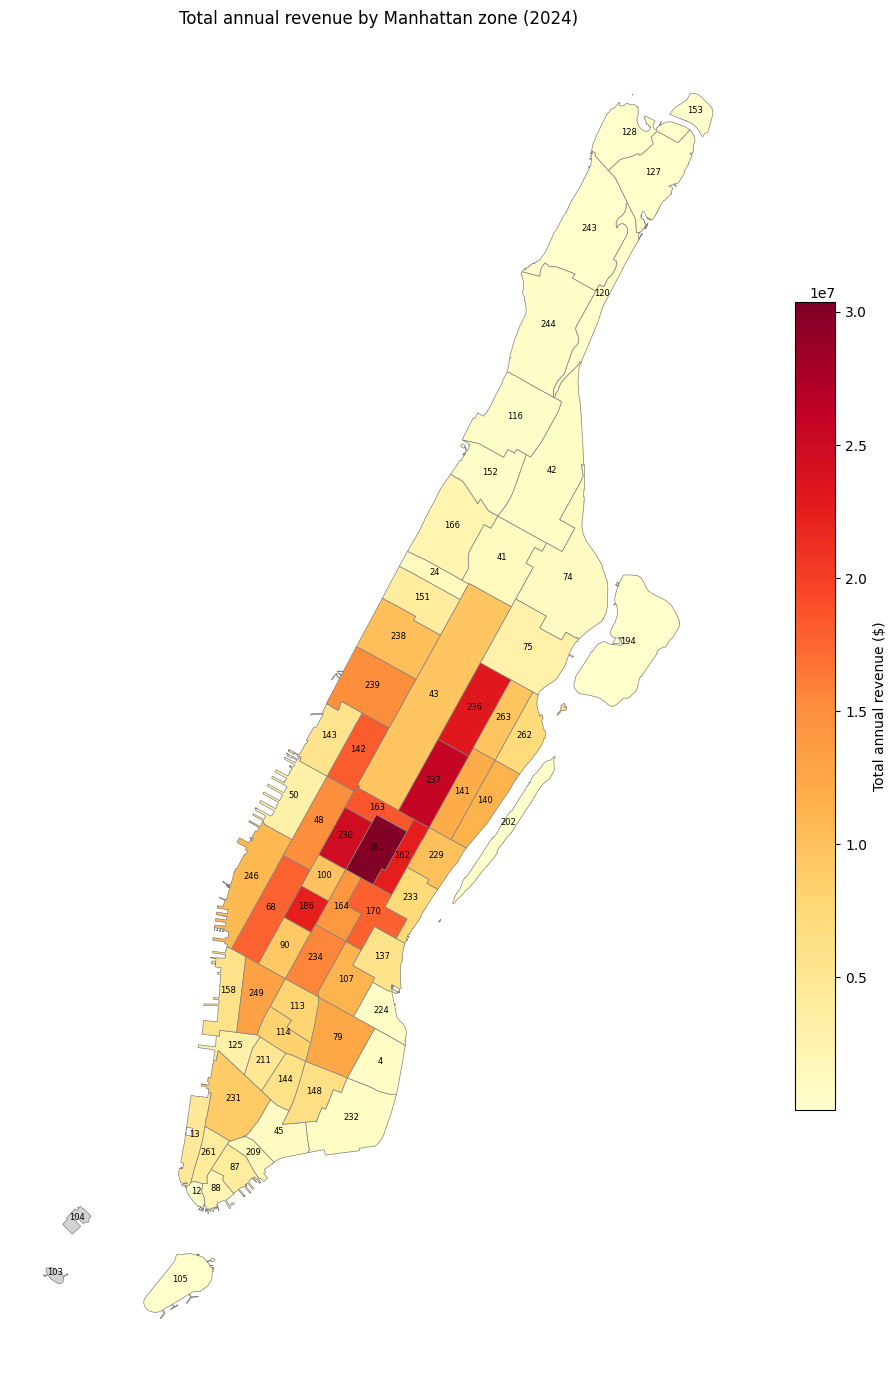

In [18]:
zone_total = (
    train_agg.groupby("PULocationID")["total_revenue"]
    .sum()
    .reset_index()
)
zone_total.columns = ["LocationID", "total_revenue_annual"]

manhattan_geo = manhattan_geo.merge(zone_total, on="LocationID", how="left")

plt.figure(figsize=(10, 14))
ax = plt.gca()

manhattan_geo.plot(
    column="total_revenue_annual",
    cmap="YlOrRd",
    linewidth=0.5,
    edgecolor="grey",
    legend=True,
    legend_kwds={"label": "Total annual revenue ($)", "shrink": 0.6},
    ax=ax,
    missing_kwds={"color": "lightgrey", "label": "No data"}
)

for _, row in manhattan_geo.iterrows():
    centroid = row.geometry.centroid
    ax.annotate(
        str(int(row["LocationID"])),
        xy=(centroid.x, centroid.y),
        fontsize=6,
        ha="center",
        color="black"
    )

plt.title("Total annual revenue by Manhattan zone (2024)")
plt.axis("off")
plt.tight_layout()
plt.show()

Above we see the average yearly revenue by zone, showing a similar structure. Showing the dominance of the high revenue zones.

### Revenue per trip choropleth

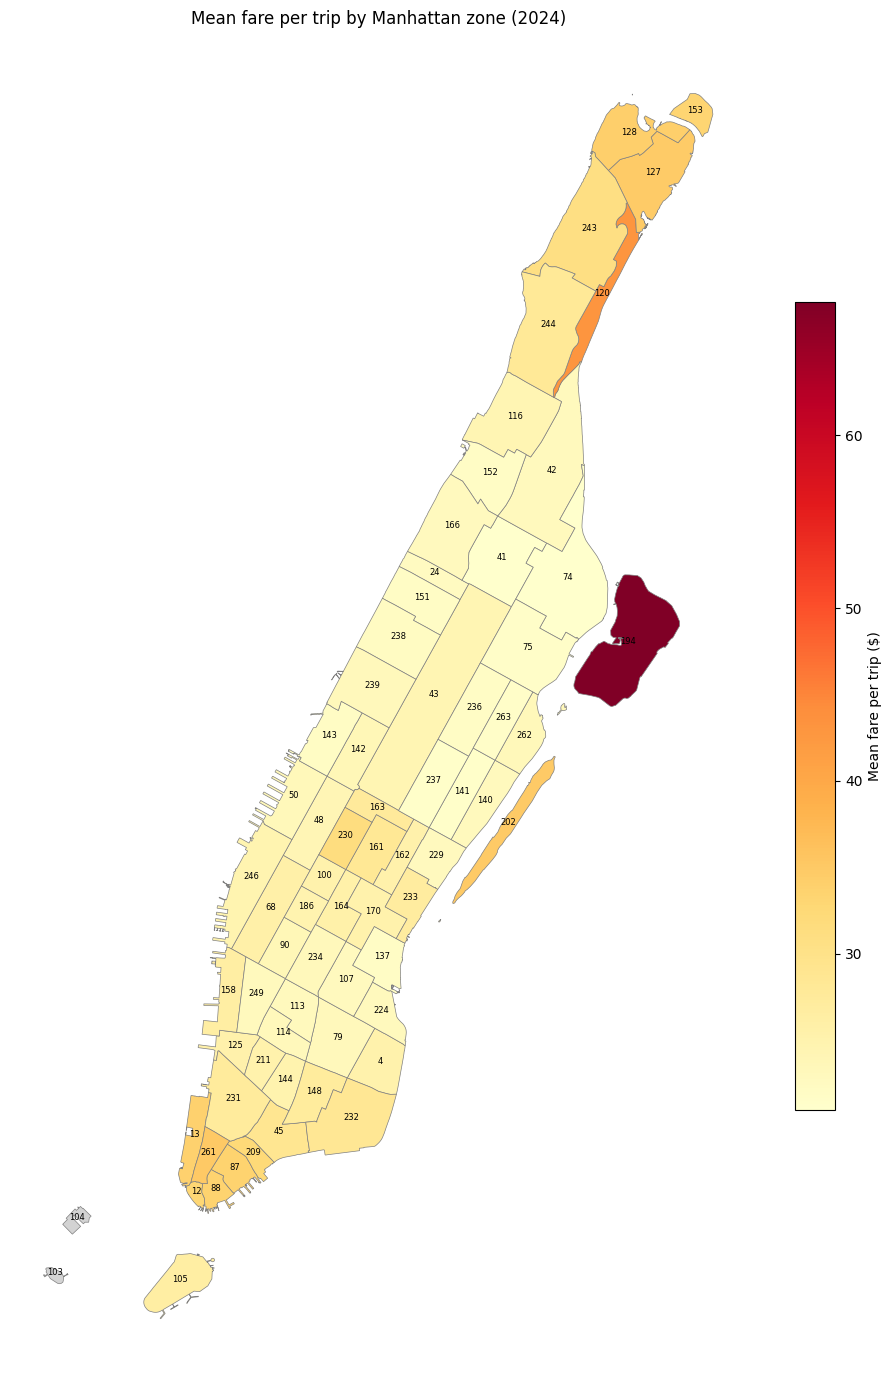

In [19]:
# Shows which zones get higher fares regardless of trip volume
zone_avg_fare = (
    train_agg.groupby("PULocationID")["avg_total_amount"]
    .mean()
    .reset_index()
)
zone_avg_fare.columns = ["LocationID", "mean_fare_per_trip"]

manhattan_geo = manhattan_geo.merge(zone_avg_fare, on="LocationID", how="left")

plt.figure(figsize=(10, 14))
ax = plt.gca()

manhattan_geo.plot(
    column="mean_fare_per_trip",
    cmap="YlOrRd",
    linewidth=0.5,
    edgecolor="grey",
    legend=True,
    legend_kwds={"label": "Mean fare per trip ($)", "shrink": 0.6},
    ax=ax,
    missing_kwds={"color": "lightgrey", "label": "No data"}
)

for _, row in manhattan_geo.iterrows():
    centroid = row.geometry.centroid
    ax.annotate(
        str(int(row["LocationID"])),
        xy=(centroid.x, centroid.y),
        fontsize=6,
        ha="center",
        color="black"
    )

plt.title("Mean fare per trip by Manhattan zone (2024)")
plt.axis("off")
plt.tight_layout()
plt.show()

Above we see the average fair per trip in each zone, with Zone 194 dominating. 

In [20]:
print(manhattan_geo.columns.tolist())

['OBJECTID', 'Shape_Leng', 'Shape_Area', 'zone', 'LocationID', 'borough', 'geometry', 'mean_hourly_revenue', 'total_revenue_annual', 'mean_fare_per_trip']


### Demand-Time EDA 

Mean demand by hour of day.

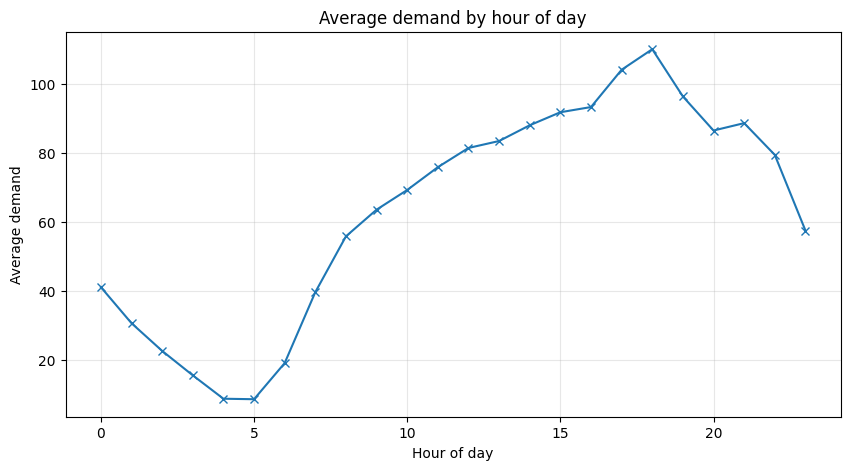

In [21]:

df = train_agg.copy()

# Extract hour
df["hour"] = df["pickup_datetime_hour"].dt.hour

# Average demand per hour
avg_hourly = (
    df.groupby("hour")["demand"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10, 5))
plt.plot(avg_hourly["hour"], avg_hourly["demand"], marker="x")
plt.xlabel("Hour of day")
plt.ylabel("Average demand")
plt.title("Average demand by hour of day")
plt.grid(True, alpha=0.3)
plt.show()

We observe a clear peak at 5pm and a minimum around 4/5am. This is in line with expectations (people going to/ leaving work ect).

Now I plot overlay the average for each hour for each day of the week to see how the behavior changed over the week

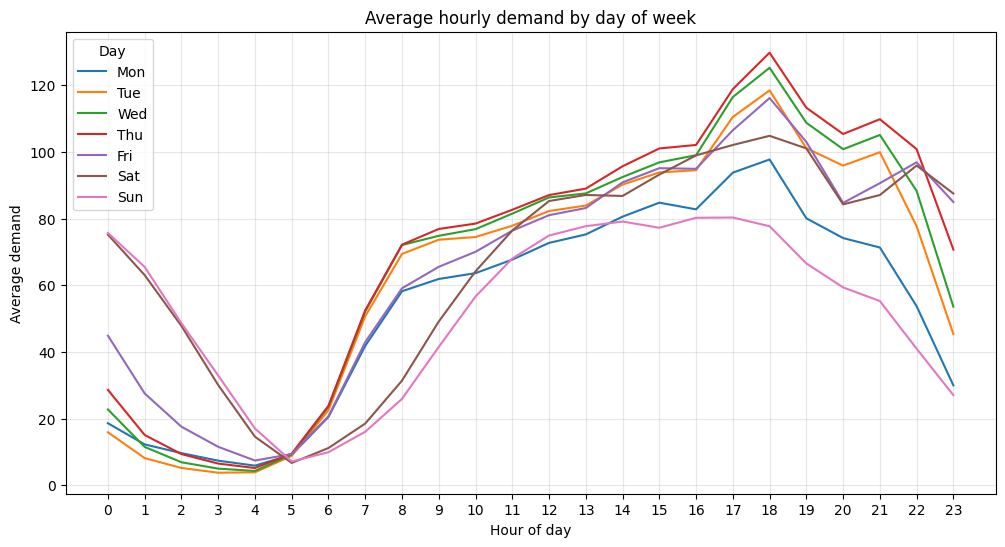

In [22]:

# Extract features
df["hour"] = df["pickup_datetime_hour"].dt.hour
df["day_of_week"] = df["pickup_datetime_hour"].dt.dayofweek  # 0=Mon

# Avg demand for each hour
avg_pattern = (
    df.groupby(["day_of_week", "hour"])["demand"]
    .mean()
    .reset_index()
)

day_map = {
    0: "Mon", 1: "Tue", 2: "Wed", 3: "Thu",
    4: "Fri", 5: "Sat", 6: "Sun"
}

plt.figure(figsize=(12, 6))

# Plot
for d in range(7):
    day_data = avg_pattern[avg_pattern["day_of_week"] == d]
    plt.plot(day_data["hour"], day_data["demand"], label=day_map[d])

plt.xlabel("Hour of day")
plt.ylabel("Average demand")
plt.title("Average hourly demand by day of week")
plt.xticks(range(24))
plt.grid(True, alpha=0.3)
plt.legend(title="Day")


plt.show()

We observe how commuter trends change behavior on weekdays compared to weekends. There is also a very high Midnight value for saturdays and sunday, although I guess this is plausible with people socializing on the weekends.


I now plot demand vs hour of week. This should further show how demand varies by day, as well as day specific behaviors.


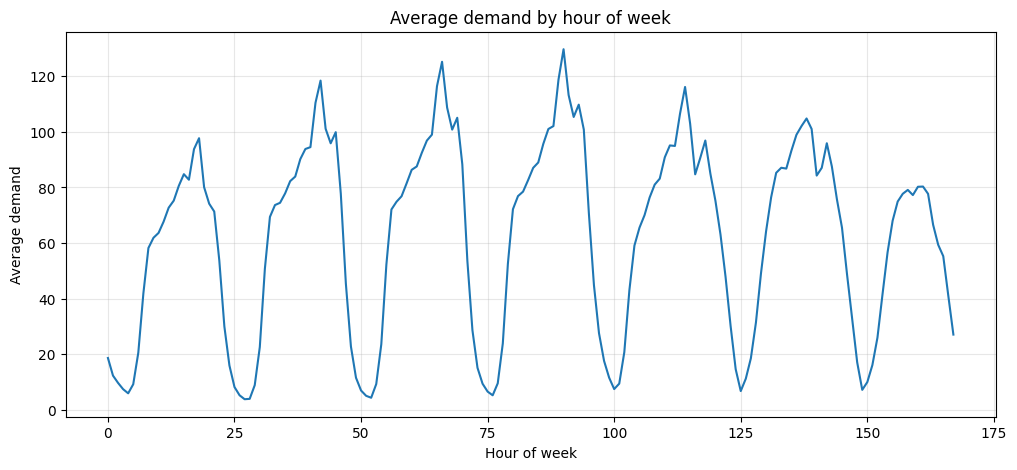

In [23]:

df["hour_of_week"] = (
    df["pickup_datetime_hour"].dt.dayofweek * 24 +
    df["pickup_datetime_hour"].dt.hour
)

avg_week = (
    df.groupby("hour_of_week")["demand"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(12, 5))
plt.plot(avg_week["hour_of_week"], avg_week["demand"])
plt.xlabel("Hour of week")
plt.ylabel("Average demand")
plt.title("Average demand by hour of week")
plt.grid(True, alpha=0.3)
plt.show()

Here we observe peak demand on thursdays, as well as clear commuter trends from Monday to Friday, with distinctly different characteristic on the weekends. 
Minimum occurs on sundays.

I now plot average demand per month, given our decision around train/test split. We could gain some advantage by making use of any visible month variation.

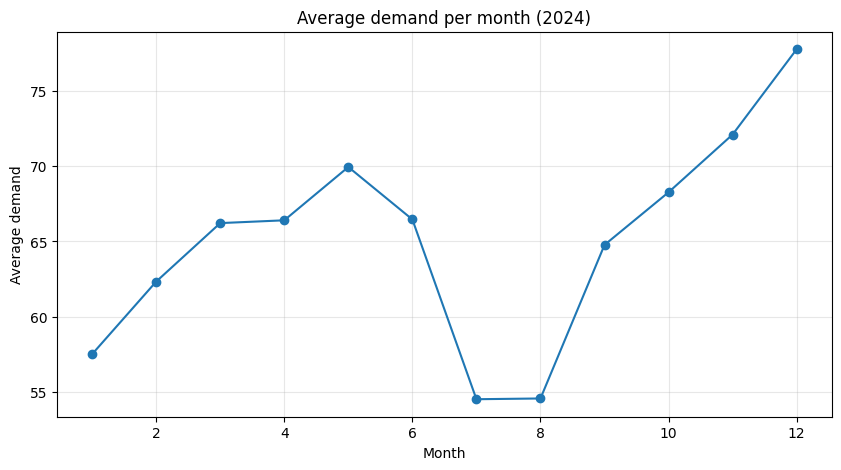

In [24]:

# get month 
df["month"] = df["pickup_datetime_hour"].dt.month

# Average demand per month
avg_month = (
    df.groupby("month")["demand"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10, 5))
plt.plot(avg_month["month"], avg_month["demand"], marker="o")
plt.xlabel("Month")
plt.ylabel("Average demand")
plt.title("Average demand per month (2024)")
plt.grid(True, alpha=0.3)
plt.show()

Here we see significant seasonal variance, this helps to justify our train, test split decision. As we can now capture these seasonal trends.

With the hope of identifying the best lag features to use, I now plot an autocorrelation plot showing how strongly the current hour is lined to the demand at a +x lag.

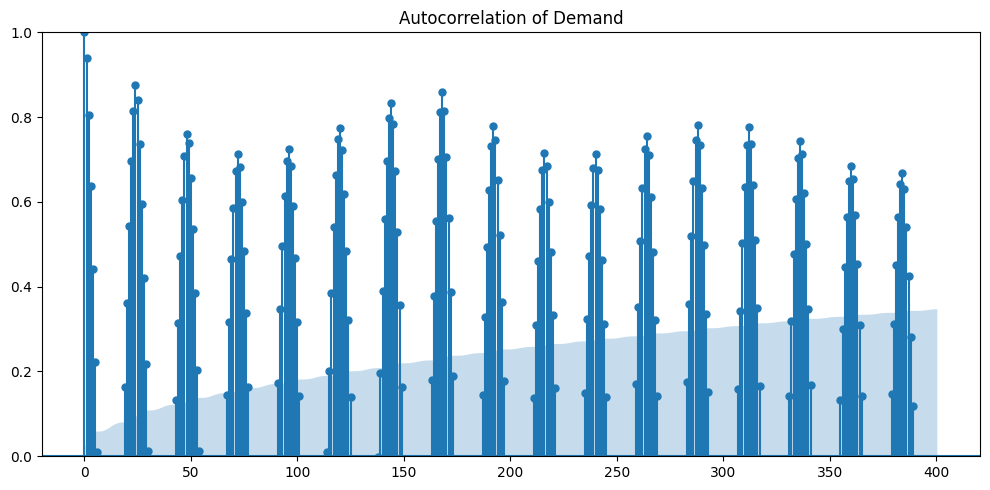

In [25]:
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

# Create time series 
ts = (
    train_agg.groupby("pickup_datetime_hour")["demand"]
    .sum()
    .sort_index()
)

# Plot ACF
fig, ax = plt.subplots(figsize=(10, 5))

plot_acf(ts, lags=400, ax=ax)

ax.set_ylim(0, 1)

plt.title("Autocorrelation of Demand")
plt.tight_layout()
plt.show()

We see the most related at +1 hour lag, which seems intuitive. Then another peak at a 24h lag, and again at 167h lag. This all seems intuitive that the most related lags would be at a one hour, one day and one week. Repeating after that with diminishing returns. It could also be beneficial to run a running average feature although we see correlation drop very fast so maybe only a few hours lag should be considered if a rolling average is to be added. Ultimately we chose to use a 2h lag, as it is remains highly correlated, but gives operational time for drivers to relocate.

### Now we investigate how these time variations change with location  

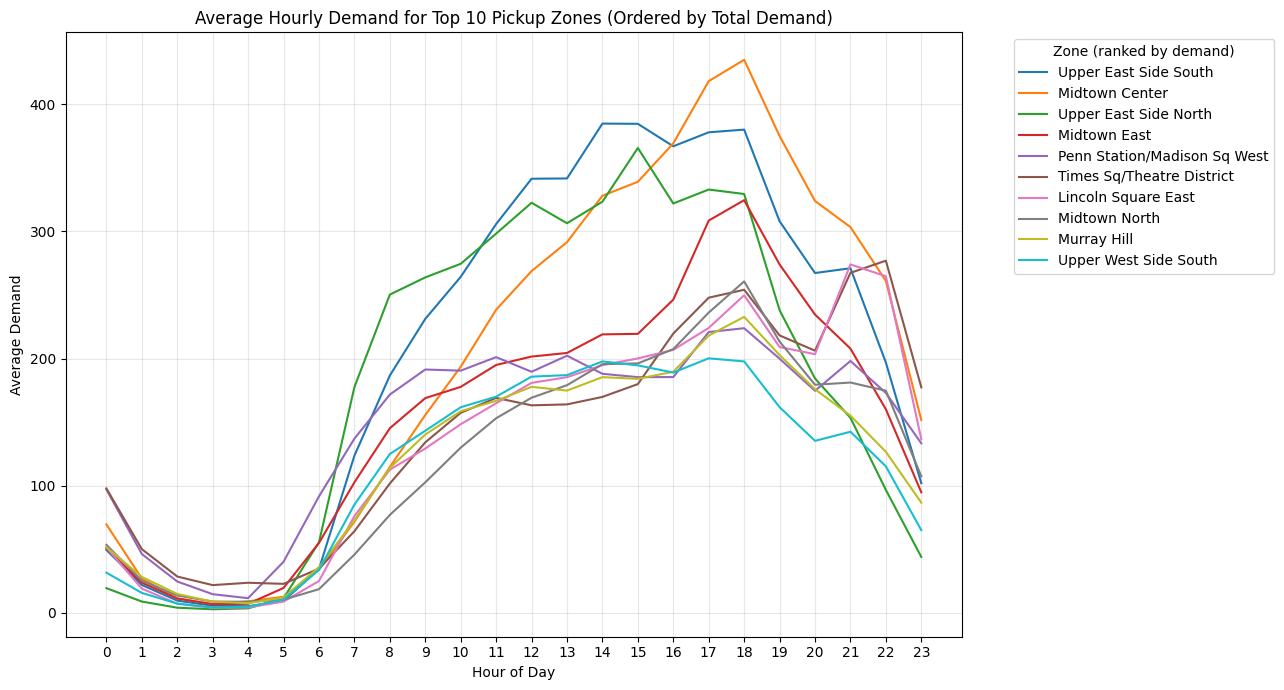

In [26]:

#datetime + hour
train_agg["pickup_datetime_hour"] = pd.to_datetime(train_agg["pickup_datetime_hour"])
train_agg["hour"] = train_agg["pickup_datetime_hour"].dt.hour

#Load lookup
taxi_zone_lookup = pd.read_csv("data/taxi_zone_lookup.csv")

# demand per zone 
zone_demand = (
    train_agg.groupby("PULocationID")["demand"]
    .sum()
    .reset_index()
)

#merge zone names
zone_demand = zone_demand.merge(
    taxi_zone_lookup[["LocationID", "Zone"]],
    left_on="PULocationID",
    right_on="LocationID",
    how="left"
)

# get top 10 daily demand zones 
zone_demand = zone_demand.sort_values("demand", ascending=False)
top_10 = zone_demand.head(10)

plot_df = train_agg[train_agg["PULocationID"].isin(top_10["PULocationID"])].copy()

plot_df = plot_df.merge(
    taxi_zone_lookup[["LocationID", "Zone"]],
    left_on="PULocationID",
    right_on="LocationID",
    how="left"
)

#hourly demands
hourly_demand = (
    plot_df.groupby(["PULocationID", "Zone", "hour"])["demand"]
    .mean()
    .reset_index()
)

#plot sorted by daily demand 
plt.figure(figsize=(13, 7))

for _, row in top_10.iterrows():  #order
    zone_id = row["PULocationID"]
    zone_name = row["Zone"]

    subset = hourly_demand[hourly_demand["PULocationID"] == zone_id]
    plt.plot(subset["hour"], subset["demand"], label=zone_name)

plt.xlabel("Hour of Day")
plt.ylabel("Average Demand")
plt.title("Average Hourly Demand for Top 10 Pickup Zones (Ordered by Total Demand)")
plt.xticks(range(24))
plt.grid(True, alpha=0.3)

plt.legend(title="Zone (ranked by demand)", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

Above we see meaningful differences between location trends. Some areas capture more of the morning commute where as others capture people leaving work. We also see different areas peaking later in the day, such as time square, that are related to nightlife. 

Bellow I further investigate the hourly demand per location.

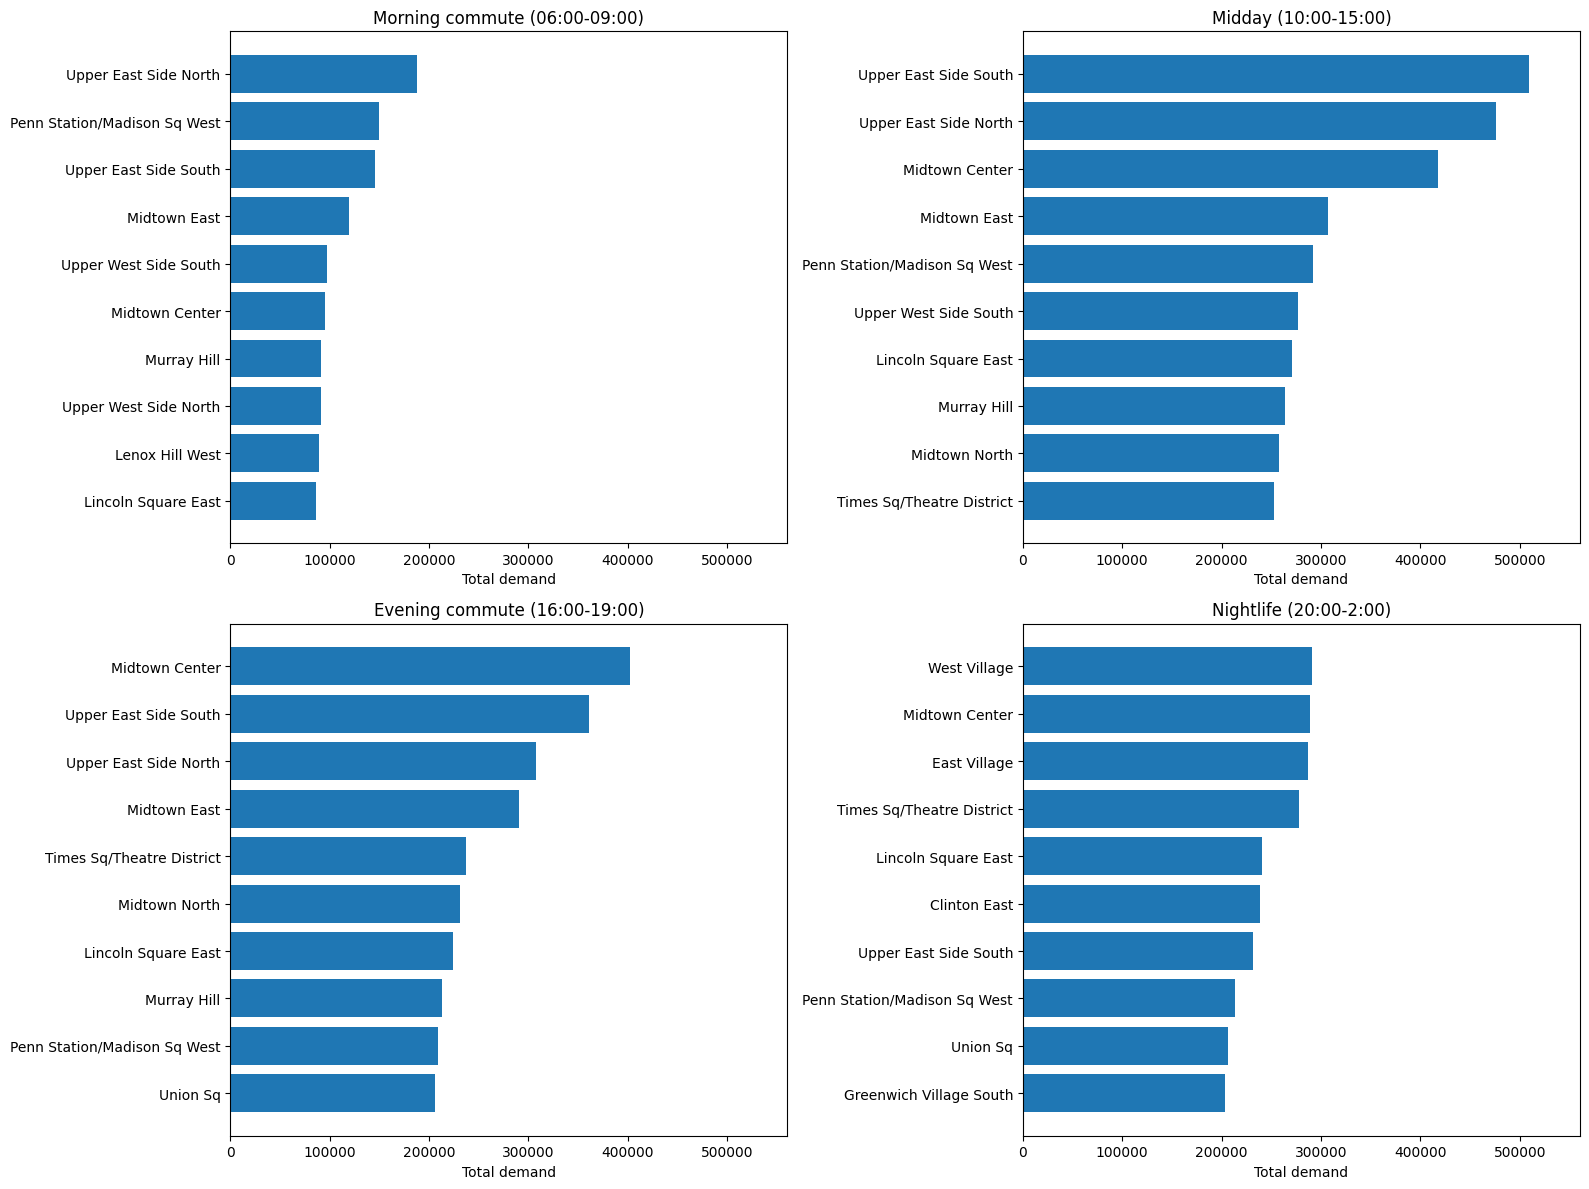

In [27]:

# make sure time column is datetime
train_agg["pickup_datetime_hour"] = pd.to_datetime(train_agg["pickup_datetime_hour"])
train_agg["hour"] = train_agg["pickup_datetime_hour"].dt.hour

# load zone names
zone_lookup = pd.read_csv("data/taxi_zone_lookup.csv")[["LocationID", "Zone"]]

# add zone names onto the aggregated data
df = train_agg.merge(
    zone_lookup,
    left_on="PULocationID",
    right_on="LocationID",
    how="left"
)

# time blocks to compare
time_blocks = {
    "Morning commute (06:00-09:00)": [6, 7, 8, 9],
    "Midday (10:00-15:00)": [10, 11, 12, 13, 14, 15],
    "Evening commute (16:00-19:00)": [16, 17, 18, 19],
    "Nightlife (20:00-2:00)": [20, 21, 22, 23, 0, 1, 2]
}

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

top_n = 10
all_max = 0
results = {}

# get top zones for each time block
for name, hours in time_blocks.items():
    block = df[df["hour"].isin(hours)]

    top_zones = (
        block.groupby("Zone")["demand"]
        .sum()
        .sort_values(ascending=False)
        .head(top_n)
        .sort_values()
    )

    results[name] = top_zones
    all_max = max(all_max, top_zones.max())

# plot
for ax, (name, top_zones) in zip(axes, results.items()):
    ax.barh(top_zones.index, top_zones.values)
    ax.set_title(name)
    ax.set_xlabel("Total demand")
    ax.set_xlim(0, all_max * 1.1)

plt.tight_layout()
plt.show()

Here we see a categorization of times of day, formalizing the trends seen in the last graphs. We once again see distinct shifts as the time of day changes.

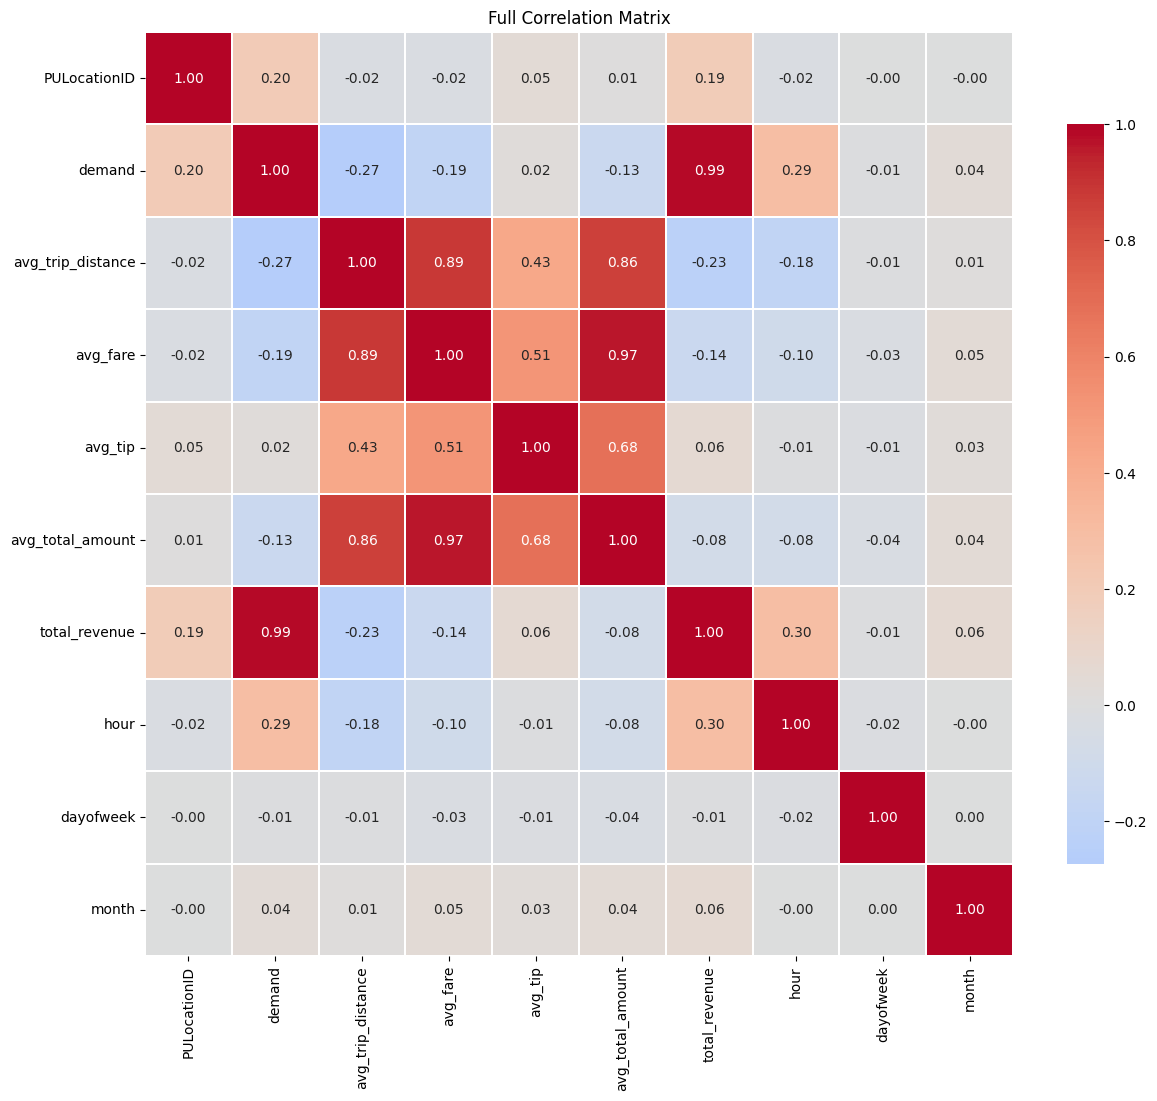

In [28]:
numeric_cols = train_agg.select_dtypes(include=[np.number]).columns

corr_matrix = train_agg[numeric_cols].corr()

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 12))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=False,
    linewidths=0.1,
    cbar_kws={"shrink": 0.8}
)

plt.title("Full Correlation Matrix")
plt.show()

In the above correlation matrix, it is clear that this is a highly non linear problem. As there are not many highly correlated features that are appropriate for use.

## Data Wrangling

The data is transformed into a structured format suitable for time-based modelling. The process follows three main stages:

1. Cleaning raw trip-level data
2. Aggregating to a zone-by-hour level
3. Feature engineering using only information available prior to prediction

Care is taken to avoid data leakage by ensuring that no features include information from the same time period as the prediction target.

### Data Cleaning

Raw trip-level data is cleaned to remove invalid records and ensure consistency. This includes:

- parsing datetime fields
- removing impossible values (e.g. negative distance or fare)
- removing invalid time sequences (dropoff before pickup)
- handling missing values using appropriate substitutions

The original data is not modified directly; all transformations are applied through reusable functions.

In [29]:
def clean_taxi_data(df):
    df = df.copy()

    # parse datetime
    df["tpep_pickup_datetime"] = pd.to_datetime(df["tpep_pickup_datetime"], errors="coerce")
    df["tpep_dropoff_datetime"] = pd.to_datetime(df["tpep_dropoff_datetime"], errors="coerce")

    # drop invalid datetime rows
    df = df.dropna(subset=["tpep_pickup_datetime", "tpep_dropoff_datetime"])
    df = df[df["tpep_dropoff_datetime"] >= df["tpep_pickup_datetime"]]

    # numeric conversion
    numeric_cols = [
        "passenger_count", "trip_distance", "fare_amount",
        "tip_amount", "total_amount"
    ]

    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    # remove invalid values
    df = df[df["trip_distance"] >= 0]
    df = df[df["fare_amount"] >= 0]
    df = df[df["total_amount"] >= 0]

    # fill missing
    df["tip_amount"] = df["tip_amount"].fillna(0)
    df["passenger_count"] = df["passenger_count"].fillna(df["passenger_count"].median())

    return df.reset_index(drop=True)

### Apply general cleaning to the training and test sets

The reusable cleaning pipeline is now applied to both the training and test data. This ensures that both datasets are processed in the same way and that no inconsistencies are introduced before feature engineering.

In [30]:
def clean_base_taxi_data(df):
    df = df.copy()

    # Parse datetimes
    df["tpep_pickup_datetime"] = pd.to_datetime(df["tpep_pickup_datetime"], errors="coerce")
    df["tpep_dropoff_datetime"] = pd.to_datetime(df["tpep_dropoff_datetime"], errors="coerce")

    # Build one combined boolean mask instead of filtering repeatedly
    mask = (
        df["tpep_pickup_datetime"].notna() &
        df["tpep_dropoff_datetime"].notna() &
        (df["tpep_dropoff_datetime"] >= df["tpep_pickup_datetime"])
    )

    numeric_cols = [
        "passenger_count", "trip_distance", "RatecodeID",
        "PULocationID", "DOLocationID", "payment_type",
        "fare_amount", "extra", "mta_tax", "tip_amount",
        "tolls_amount", "improvement_surcharge", "total_amount",
        "congestion_surcharge", "Airport_fee",
    ]
    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    non_negative_cols = [
        "passenger_count", "trip_distance", "fare_amount", "extra",
        "mta_tax", "tip_amount", "tolls_amount", "improvement_surcharge",
        "total_amount", "congestion_surcharge", "Airport_fee",
    ]
    for col in non_negative_cols:
        if col in df.columns:
            mask &= df[col].isna() | (df[col] >= 0)  # accumulate into one mask

    # Apply mask ONCE instead of 10+ separate filter operations
    df = df[mask].copy()

    # Fill missing values (no copies made here)
    zero_fill_cols = [
        "tip_amount", "tolls_amount", "Airport_fee",
        "congestion_surcharge", "extra", "mta_tax", "improvement_surcharge",
    ]
    median_fill_cols = ["passenger_count", "trip_distance", "fare_amount", "total_amount"]

    for col in zero_fill_cols:
        if col in df.columns:
            df[col] = df[col].fillna(0)

    for col in median_fill_cols:
        if col in df.columns:
            df[col] = df[col].fillna(df[col].median())

    if "store_and_fwd_flag" in df.columns:
        df["store_and_fwd_flag"] = df["store_and_fwd_flag"].fillna("Unknown")

    mode_fill_cols = ["VendorID", "RatecodeID", "PULocationID", "DOLocationID", "payment_type"]
    for col in mode_fill_cols:
        if col in df.columns:
            mode = df[col].mode(dropna=True)
            if not mode.empty:
                df[col] = df[col].fillna(mode.iloc[0])

    return df.reset_index(drop=True)

In [31]:
train_clean = clean_base_taxi_data(train_df)
val_clean = clean_base_taxi_data(val_df)
test_clean = clean_base_taxi_data(test_df)

print("Train shape before cleaning:", train_df.shape)
print("Train shape after cleaning: ", train_clean.shape)

print("Validation shape before cleaning:", val_df.shape)
print("Validation shape after cleaning: ", val_clean.shape)


print("Test shape before cleaning:", test_df.shape)
print("Test shape after cleaning: ", test_clean.shape)

Train shape before cleaning: (22194496, 20)
Train shape after cleaning:  (22194461, 20)
Validation shape before cleaning: (3530697, 20)
Validation shape after cleaning:  (3530687, 20)
Test shape before cleaning: (3334079, 20)
Test shape after cleaning:  (3334076, 20)


### Check missing values after cleaning

After cleaning, the key variables are checked to confirm that invalid datetime rows have been removed and missing values have been handled using the chosen substitution rules.

In [32]:
cols_to_check = [
    "tpep_pickup_datetime",
    "tpep_dropoff_datetime",
    "passenger_count",
    "trip_distance",
    "RatecodeID",
    "PULocationID",
    "DOLocationID",
    "fare_amount",
    "tip_amount",
    "total_amount",
]

existing_cols = [c for c in cols_to_check if c in train_clean.columns]

print("Missing values in cleaned training data:")
display(train_clean[existing_cols].isna().sum())

print("Missing values in cleaned test data:")
display(test_clean[existing_cols].isna().sum())

Missing values in cleaned training data:


tpep_pickup_datetime     0
tpep_dropoff_datetime    0
passenger_count          0
trip_distance            0
RatecodeID               0
PULocationID             0
DOLocationID             0
fare_amount              0
tip_amount               0
total_amount             0
dtype: int64

Missing values in cleaned test data:


tpep_pickup_datetime     0
tpep_dropoff_datetime    0
passenger_count          0
trip_distance            0
RatecodeID               0
PULocationID             0
DOLocationID             0
fare_amount              0
tip_amount               0
total_amount             0
dtype: int64

### Aggregation to Zone–Hour Level

The raw trip-level data is aggregated to a zone-by-hour level, where each row represents activity for a specific pickup location and hour.

This transformation allows demand and revenue to be modelled in a structured way, as the target variables are defined at this level. Aggregation also reduces noise from individual trips while preserving meaningful patterns.

For each zone-hour combination, the following are computed:
- demand (number of trips)
- average values (e.g. fare, distance, tip)
- total values (e.g. revenue)

In [33]:
def clean_taxi_data(df):
    df = df.copy()

    # parse datetime
    df["tpep_pickup_datetime"] = pd.to_datetime(df["tpep_pickup_datetime"], errors="coerce")
    df["tpep_dropoff_datetime"] = pd.to_datetime(df["tpep_dropoff_datetime"], errors="coerce")

    # drop invalid datetime rows
    df = df.dropna(subset=["tpep_pickup_datetime", "tpep_dropoff_datetime"])
    df = df[df["tpep_dropoff_datetime"] >= df["tpep_pickup_datetime"]]

    # numeric conversion
    numeric_cols = [
        "passenger_count", "trip_distance", "fare_amount",
        "tip_amount", "total_amount"
    ]

    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    # remove invalid values
    df = df[df["trip_distance"] >= 0]
    df = df[df["fare_amount"] >= 0]
    df = df[df["total_amount"] >= 0]

    # fill missing
    df["tip_amount"] = df["tip_amount"].fillna(0)
    df["passenger_count"] = df["passenger_count"].fillna(df["passenger_count"].median())

    return df.reset_index(drop=True)

### Aggregation

The cleaned trip-level data is aggregated to a zone-by-hour level. Each row represents activity for a specific pickup location and hour.

This structure aligns with the prediction objective, where demand and revenue are defined per location and time period.

Aggregation is limited to quantities that are meaningful summaries of past behaviour. No future information is introduced.

In [34]:
def aggregate_hourly(df):
    df = df.copy()

    df["pickup_datetime_hour"] = df["tpep_pickup_datetime"].dt.floor("h")

    # trip duration
    df["trip_duration_min"] = (
        df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"]
    ).dt.total_seconds() / 60

    grouped = df.groupby(["PULocationID", "pickup_datetime_hour"])

    agg_df = grouped.agg(
        demand=("PULocationID", "count"),

        avg_trip_distance=("trip_distance", "mean"),
        avg_duration=("trip_duration_min", "mean"),
        avg_passenger_count=("passenger_count", "mean"),

        total_revenue=("total_amount", "sum")
    ).reset_index()

    return agg_df

### Time Features

Time-based features are extracted from the hourly timestamp to capture temporal patterns such as daily and weekly cycles.

Cyclical encoding is applied to the hour variable to reflect its periodic nature.

In [35]:

def add_time_features(df):
    df = df.copy()

    df["hour"] = df["pickup_datetime_hour"].dt.hour
    df["day_of_week"] = df["pickup_datetime_hour"].dt.dayofweek
    df["month"] = df["pickup_datetime_hour"].dt.month
    df["is_weekend"] = df["day_of_week"].isin([5, 6]).astype(int)

    # cyclical encoding
    df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
    df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

    return df

### Lag Features

Lag features are created to capture temporal dependencies using only past information.

These include:
- Second previous hour demand
- previous day demand
- historical averages within the same month

Lag features are computed separately for each location and only use prior observations to avoid data leakage.

To build lag features, I isolate the relevant features, use the benefit of having datetime objects to shift the hour by two hours, and re-merge the dataset, creating our lag features.
This is better than just shifting rows as because of our design choice to split each month, we have a discontinuous (although ordered) data set. This means using row shifting risks problematic edge cases where the shifts will move you to a previous month. This issue is avoided and when shifts jump out of our available data, they are entered asm Na. This allows them to be imputed as fit for each specific model we train.

In [36]:
def add_revenue_lags(df):
    df = df.copy()
    df["pickup_datetime_hour"] = pd.to_datetime(df["pickup_datetime_hour"])

    base = df[["PULocationID", "pickup_datetime_hour", "total_revenue"]].copy()

    lag_2 = base.copy()
    lag_2["pickup_datetime_hour"] += pd.Timedelta(hours=2)
    lag_2 = lag_2.rename(columns={"total_revenue": "revenue_lag_2"})

    lag_24 = base.copy()
    lag_24["pickup_datetime_hour"] += pd.Timedelta(hours=24)
    lag_24 = lag_24.rename(columns={"total_revenue": "revenue_lag_24"})

    df = df.merge(lag_2, on=["PULocationID", "pickup_datetime_hour"], how="left")
    df = df.merge(lag_24, on=["PULocationID", "pickup_datetime_hour"], how="left")

    # rolling mean based on previous observed rows within location
    df = df.sort_values(["PULocationID", "pickup_datetime_hour"])
    grouped = df.groupby("PULocationID")
    df["revenue_rolling_24"] = grouped["total_revenue"].shift(1).rolling(24, min_periods=1).mean()

    return df.reset_index(drop=True)

def add_demand_lags(df):
    df = df.copy()
    df["pickup_datetime_hour"] = pd.to_datetime(df["pickup_datetime_hour"])

    base = df[["PULocationID", "pickup_datetime_hour", "demand"]].copy()

    lag_2 = base.copy()
    lag_2["pickup_datetime_hour"] += pd.Timedelta(hours=2)
    lag_2 = lag_2.rename(columns={"demand": "demand_lag_2"})

    lag_24 = base.copy()
    lag_24["pickup_datetime_hour"] += pd.Timedelta(hours=24)
    lag_24 = lag_24.rename(columns={"demand": "demand_lag_24"})

    lag_4w = base.copy()
    lag_4w["pickup_datetime_hour"] += pd.Timedelta(weeks=4)
    lag_4w = lag_4w.rename(columns={"demand": "demand_lag_4w"})

    df = df.merge(lag_2, on=["PULocationID", "pickup_datetime_hour"], how="left")
    df = df.merge(lag_24, on=["PULocationID", "pickup_datetime_hour"], how="left")
    df = df.merge(lag_4w, on=["PULocationID", "pickup_datetime_hour"], how="left")

    df = df.sort_values(["PULocationID", "pickup_datetime_hour"])
    grouped = df.groupby("PULocationID")
    df["demand_rolling_24"] = grouped["demand"].shift(1).rolling(24, min_periods=1).mean()

    return df

### Behaviour Lag Features

Trip-level behavioural features (such as average distance and duration) are not used directly for prediction, as they would not be known at prediction time.

Instead, lagged versions of these features are created, allowing the model to use historical behaviour without introducing leakage.

In [37]:

def add_behaviour_lags(df):
    df = df.copy()
    df["pickup_datetime_hour"] = pd.to_datetime(df["pickup_datetime_hour"])

    for col in ["avg_trip_distance", "avg_duration", "avg_passenger_count"]:
        base = df[["PULocationID", "pickup_datetime_hour", col]].copy()

        lag2 = base.copy()
        lag2["pickup_datetime_hour"] += pd.Timedelta(hours=2)
        lag2 = lag2.rename(columns={col: f"{col}_lag2"})

        lag24 = base.copy()
        lag24["pickup_datetime_hour"] += pd.Timedelta(hours=24)
        lag24 = lag24.rename(columns={col: f"{col}_lag24"})

        df = df.merge(lag2, on=["PULocationID", "pickup_datetime_hour"], how="left")
        df = df.merge(lag24, on=["PULocationID", "pickup_datetime_hour"], how="left")

    return df

In [38]:
print(list(train_clean.columns))

['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'Airport_fee', 'pickup_datetime']


### Rolling Features

Rolling features are introduced to capture smoothed temporal trends in demand.

A 24-hour rolling average is used to represent short-term trends.

In [39]:
def add_rolling_features(df):
    df = df.copy()

    df = df.sort_values(["PULocationID", "pickup_datetime_hour"])
    grouped = df.groupby("PULocationID")

    df["rolling_24_hour"] = (
        grouped["demand"]
        .shift(1)
        .rolling(window=24, min_periods=1)
        .mean()
    )

    return df

### Final Dataset Preparation

Rows with missing lag values are removed to ensure that all features are available at prediction time. The dataset is then ready for modelling.

In [40]:
def finalise_dataset(df, target_col="demand"):
    df = df.copy()

    if {"PULocationID", "pickup_datetime_hour"}.issubset(df.columns):
        df = df.sort_values(["PULocationID", "pickup_datetime_hour"])

    required_cols = [c for c in [target_col, "PULocationID", "pickup_datetime_hour"] if c in df.columns]
    df = df.dropna(subset=required_cols)

    return df.reset_index(drop=True)

# cleaning
train_clean = clean_taxi_data(train_df)
val_clean = clean_taxi_data(val_df)
test_clean = clean_taxi_data(test_df)

# aggregation
train_agg = aggregate_hourly(train_clean)
val_agg = aggregate_hourly(val_clean)
test_agg = aggregate_hourly(test_clean)

# features
train_agg = add_time_features(train_agg)
val_agg = add_time_features(val_agg)
test_agg = add_time_features(test_agg)

train_agg = add_demand_lags(train_agg)
val_agg = add_demand_lags(val_agg)
test_agg = add_demand_lags(test_agg)

train_agg = add_revenue_lags(train_agg)
val_agg = add_revenue_lags(val_agg)
test_agg = add_revenue_lags(test_agg)

train_agg = add_rolling_features(train_agg)
val_agg = add_rolling_features(val_agg)
test_agg = add_rolling_features(test_agg)

train_agg = add_behaviour_lags(train_agg)
val_agg = add_behaviour_lags(val_agg)
test_agg = add_behaviour_lags(test_agg)

# final
train_ready = finalise_dataset(train_agg)
val_ready = finalise_dataset(val_agg)
test_ready = finalise_dataset(test_agg)

In [41]:
def inspect_datasets(train_df, val_df, test_df, show_nulls=True):
    print("=== SHAPES ===")
    print(f"Train shape: {train_df.shape}")
    print(f"Validation shape: {val_df.shape}")
    print(f"Test  shape: {test_df.shape}")
    

    print("\n=== TRAIN COLUMNS ===")
    for i, col in enumerate(train_df.columns):
        print(f"{i:>2}: {col}")

    print("\n=== VALIDATION COLUMNS ===")
    for i, col in enumerate(val_df.columns):
        print(f"{i:>2}: {col}")

    print("\n=== TEST COLUMNS ===")
    for i, col in enumerate(test_df.columns):
        print(f"{i:>2}: {col}")

    print("\n=== TRAIN DTYPES ===")
    print(train_df.dtypes)

    print("\n=== VALIDATION DTYPES ===")
    print(val_df.dtypes)

    print("\n=== TEST DTYPES ===")
    print(test_df.dtypes)

    if show_nulls:
        print("\n=== TRAIN NULLS ===")
        print(train_df.isna().sum())

        print("\n=== VALIDATION NULLS ===")
        print(val_df.isna().sum())

        print("\n=== TEST NULLS ===")
        print(test_df.isna().sum())

In [42]:
inspect_datasets(train_ready, val_ready, test_ready)

=== SHAPES ===
Train shape: (340955, 27)
Validation shape: (56695, 27)
Test  shape: (56711, 27)

=== TRAIN COLUMNS ===
 0: PULocationID
 1: pickup_datetime_hour
 2: demand
 3: avg_trip_distance
 4: avg_duration
 5: avg_passenger_count
 6: total_revenue
 7: hour
 8: day_of_week
 9: month
10: is_weekend
11: hour_sin
12: hour_cos
13: demand_lag_2
14: demand_lag_24
15: demand_lag_4w
16: demand_rolling_24
17: revenue_lag_2
18: revenue_lag_24
19: revenue_rolling_24
20: rolling_24_hour
21: avg_trip_distance_lag2
22: avg_trip_distance_lag24
23: avg_duration_lag2
24: avg_duration_lag24
25: avg_passenger_count_lag2
26: avg_passenger_count_lag24

=== VALIDATION COLUMNS ===
 0: PULocationID
 1: pickup_datetime_hour
 2: demand
 3: avg_trip_distance
 4: avg_duration
 5: avg_passenger_count
 6: total_revenue
 7: hour
 8: day_of_week
 9: month
10: is_weekend
11: hour_sin
12: hour_cos
13: demand_lag_2
14: demand_lag_24
15: demand_lag_4w
16: demand_rolling_24
17: revenue_lag_2
18: revenue_lag_24
19: rev

In [43]:
common_features = [
    "PULocationID",
    "hour",
    "day_of_week",
    "month",
    "is_weekend",
    "hour_sin",
    "hour_cos",

    # demand lags
    "demand_lag_2",
    "demand_lag_24",
    "demand_lag_4w",
    "demand_rolling_24",
]

# targets
demand_target = "demand"
revenue_target = "total_revenue"

X_train_demand = train_ready[common_features].copy()
y_train_demand = train_ready["demand"].copy()

X_val_demand = val_ready[common_features].copy()
y_val_demand = val_ready["demand"].copy()

X_test_demand = test_ready[common_features].copy()
y_test_demand = test_ready["demand"].copy()

revenue_features = common_features + [
    "revenue_lag_2",
    "revenue_lag_24",
    "revenue_rolling_24",
]

X_train_revenue = train_ready[revenue_features].copy()
y_train_revenue = train_ready["total_revenue"].copy()

X_val_revenue = val_ready[revenue_features].copy()
y_val_revenue = val_ready["total_revenue"].copy()

X_test_revenue = test_ready[revenue_features].copy()
y_test_revenue = test_ready["total_revenue"].copy()

In [44]:
inspect_datasets(X_train_demand, X_val_demand, X_test_demand)

=== SHAPES ===
Train shape: (340955, 11)
Validation shape: (56695, 11)
Test  shape: (56711, 11)

=== TRAIN COLUMNS ===
 0: PULocationID
 1: hour
 2: day_of_week
 3: month
 4: is_weekend
 5: hour_sin
 6: hour_cos
 7: demand_lag_2
 8: demand_lag_24
 9: demand_lag_4w
10: demand_rolling_24

=== VALIDATION COLUMNS ===
 0: PULocationID
 1: hour
 2: day_of_week
 3: month
 4: is_weekend
 5: hour_sin
 6: hour_cos
 7: demand_lag_2
 8: demand_lag_24
 9: demand_lag_4w
10: demand_rolling_24

=== TEST COLUMNS ===
 0: PULocationID
 1: hour
 2: day_of_week
 3: month
 4: is_weekend
 5: hour_sin
 6: hour_cos
 7: demand_lag_2
 8: demand_lag_24
 9: demand_lag_4w
10: demand_rolling_24

=== TRAIN DTYPES ===
PULocationID           int16
hour                   int32
day_of_week            int32
month                  int32
is_weekend             int64
hour_sin             float64
hour_cos             float64
demand_lag_2         float64
demand_lag_24        float64
demand_lag_4w        float64
demand_rolling_

Bellow I get an intuitive idea of the revenue outliers in the system to better handel them in my model pipelines.

In [45]:
print(y_train_revenue.describe())

count    340955.000000
mean       1541.054688
std        1945.196045
min           1.000000
25%         185.630005
50%         786.280029
75%        2178.889893
max       21860.429688
Name: total_revenue, dtype: float64


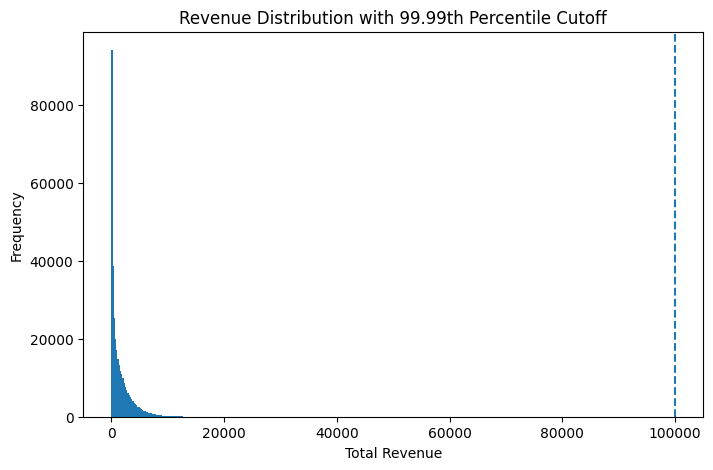

100,000 percentile cutoff: 100000.00


In [46]:

# Visualising revenue distribution + outliers

# Compute cutoff (train only)
upper_cutoff = 100000

plt.figure(figsize=(8,5))

plt.hist(y_train_revenue, bins=100)
plt.axvline(upper_cutoff, linestyle="--")

plt.title("Revenue Distribution with 99.99th Percentile Cutoff")
plt.xlabel("Total Revenue")
plt.ylabel("Frequency")

plt.show()

print(f"100,000 percentile cutoff: {upper_cutoff:.2f}")

Above we note the absurdity of having a max of 345810 looking at this data distribution. To remove massive outliers I impose a cutoff at 100,000 dollars hourly revenue per zone.

# Models


In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

XGB_DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"XGBoost device: {XGB_DEVICE}")

XGBoost device: cuda


## Reusable Functions

In [48]:
def evaluate_regression_model(model, X_train, y_train, X_val, y_val, model_name="Model"):
    """
    Fit model, generate predictions, and return evaluation metrics.
    """
    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    val_pred = model.predict(X_val)

    metrics = {
        "model": model_name,
        "train_rmse": np.sqrt(mean_squared_error(y_train, train_pred)),
        "val_rmse": np.sqrt(mean_squared_error(y_val, val_pred)),
        "train_mae": mean_absolute_error(y_train, train_pred),
        "val_mae": mean_absolute_error(y_val, val_pred),
        "train_r2": r2_score(y_train, train_pred),
        "val_r2": r2_score(y_val, val_pred),
    }

    return model, train_pred, val_pred, metrics


def display_metrics(metrics_dict):
    """
    Print regression metrics clearly.
    """
    print(f"Model: {metrics_dict['model']}")
    print(f"Train RMSE: {metrics_dict['train_rmse']:.3f}")
    print(f"val RMSE:  {metrics_dict['val_rmse']:.3f}")
    print(f"Train MAE:  {metrics_dict['train_mae']:.3f}")
    print(f"val MAE:   {metrics_dict['val_mae']:.3f}")
    print(f"Train R²:   {metrics_dict['train_r2']:.3f}")
    print(f"val R²:    {metrics_dict['val_r2']:.3f}")


def plot_actual_vs_predicted(y_true, y_pred, title):
    """
    Scatter plot of actual vs predicted values.
    """
    plt.figure()
    plt.scatter(y_true, y_pred, alpha=0.3)
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title(title)
    plt.tight_layout()
    plt.show()


def plot_feature_importance(model, feature_names, top_n=15):
    """
    Plot top feature importances for tree-based models.
    """
    importances = pd.Series(model.feature_importances_, index=feature_names)
    importances = importances.sort_values(ascending=False).head(top_n)

    plt.figure()
    importances.sort_values().plot(kind="barh")
    plt.xlabel("Importance")
    plt.title(f"Top {top_n} Feature Importances")
    plt.tight_layout()
    plt.show()

def one_hot_encode_location(train_df, val_df, column="PULocationID"):
    train_df = train_df.copy()
    val_df = val_df.copy()

    # create dummies
    train_dummies = pd.get_dummies(train_df[column], prefix=column)
    val_dummies = pd.get_dummies(val_df[column], prefix=column)

    # align columns (VERY IMPORTANT)
    train_dummies, val_dummies = train_dummies.align(val_dummies, join="left", axis=1, fill_value=0)

    # attach and drop original column
    train_df = pd.concat([train_df.drop(columns=[column]), train_dummies], axis=1)
    val_df = pd.concat([val_df.drop(columns=[column]), val_dummies], axis=1)

    return train_df, val_df


Now I use a basic RF model to assess the relative importance of potential features in order to remove unneeded features to reduce noise and decrease the risk of over fitting.

### Model 1: XGBoost for Revenue Prediction
An initial XGBoost regressor is trained using standard but reasonably strong parameters. This acts as the first full revenue model and provides a benchmark for later comparison and tuning.

This section trains the first revenue prediction model using XGBoost.

XGBoost is chosen as an initial model because it performs well on structured tabular data, can capture non-linear relationships, and provides feature importance measures that help with interpretation.

The target variable is total revenue per zone-hour. Only features available at prediction time are used, ensuring that the model remains leakage-free.

In [ ]:

#XGBoost can handle NaNs 
train_ready = train_ready.reset_index(drop=True)
val_ready = val_ready.reset_index(drop=True)

#Onehot encode location
train_ready_enc, val_ready_enc = one_hot_encode_location(train_ready, val_ready)


#feature list after encoding
location_cols = [col for col in train_ready_enc.columns if col.startswith("PULocationID_")]

candidate_revenue_features = (
    location_cols +
    [
        "day_of_week",
        "month",
        "is_weekend",
        "hour_sin",
        "hour_cos",

        "demand_lag_2",
        "demand_lag_24",
        "demand_lag_4w",
        "demand_rolling_24",

        "revenue_lag_2",
        "revenue_lag_24",
        "revenue_rolling_24",
    ]
)
#keep only columns that actually exist
revenue_features = [col for col in candidate_revenue_features if col in train_ready_enc.columns]

print("Revenue features being used:")
print(revenue_features)


#Final model datasets
X_train_revenue = train_ready_enc[revenue_features].copy()
y_train_revenue = train_ready_enc["total_revenue"].copy()

X_val_revenue = val_ready_enc[revenue_features].copy()
y_val_revenue = val_ready_enc["total_revenue"].copy()


#Impose 100,000 cutoff to get rid of outliers 
upper_cutoff = 100000

train_mask = y_train_revenue <= upper_cutoff
val_mask = y_val_revenue <= upper_cutoff

X_train_revenue = X_train_revenue.loc[train_mask].reset_index(drop=True)
y_train_revenue = y_train_revenue.loc[train_mask].reset_index(drop=True)

X_val_revenue = X_val_revenue.loc[val_mask].reset_index(drop=True)
y_val_revenue = y_val_revenue.loc[val_mask].reset_index(drop=True)

print("X_train_revenue shape:", X_train_revenue.shape)
print("X_val_revenue shape: ", X_val_revenue.shape)


#XGBoost model
xgb_revenue = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1,
    verbosity=1,
    tree_method="hist",
    device=XGB_DEVICE
)

xgb_revenue, train_pred_revenue, val_pred_revenue, revenue_metrics = evaluate_regression_model(
    model=xgb_revenue,
    X_train=X_train_revenue,
    y_train=y_train_revenue,
    X_val=X_val_revenue,
    y_val=y_val_revenue,
    model_name="XGBoost Revenue Model"
)

display_metrics(revenue_metrics)

Revenue features being used:
['PULocationID_4', 'PULocationID_12', 'PULocationID_13', 'PULocationID_24', 'PULocationID_41', 'PULocationID_42', 'PULocationID_43', 'PULocationID_45', 'PULocationID_48', 'PULocationID_50', 'PULocationID_68', 'PULocationID_74', 'PULocationID_75', 'PULocationID_79', 'PULocationID_87', 'PULocationID_88', 'PULocationID_90', 'PULocationID_100', 'PULocationID_105', 'PULocationID_107', 'PULocationID_113', 'PULocationID_114', 'PULocationID_116', 'PULocationID_120', 'PULocationID_125', 'PULocationID_127', 'PULocationID_128', 'PULocationID_137', 'PULocationID_140', 'PULocationID_141', 'PULocationID_142', 'PULocationID_143', 'PULocationID_144', 'PULocationID_148', 'PULocationID_151', 'PULocationID_152', 'PULocationID_153', 'PULocationID_158', 'PULocationID_161', 'PULocationID_162', 'PULocationID_163', 'PULocationID_164', 'PULocationID_166', 'PULocationID_170', 'PULocationID_186', 'PULocationID_194', 'PULocationID_202', 'PULocationID_209', 'PULocationID_211', 'PULocat

/cs/home/ps306/ID-R2/.venv/lib/python3.12/site-packages/xgboost/core.py:751: UserWarning: [18:49:59] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


Model: XGBoost Revenue Model
Train RMSE: 426.584
val RMSE:  486.535
Train MAE:  253.598
val MAE:   277.639
Train R²:   0.952
val R²:    0.929


In [50]:
print(y_train_revenue.describe())

mae = revenue_metrics["val_mae"]
mean_val = y_val_revenue.mean()

print("MAE:", mae)
print("Mean revenue:", mean_val)
print("Relative MAE (%):", (mae / mean_val) * 100)

print("Std revenue:", y_val_revenue.std())
print("RMSE:", revenue_metrics["val_rmse"])

count    340955.000000
mean       1541.054688
std        1945.196045
min           1.000000
25%         185.630005
50%         786.280029
75%        2178.889893
max       21860.429688
Name: total_revenue, dtype: float64
MAE: 277.63873291015625
Mean revenue: 1457.3232
Relative MAE (%): 19.051281
Std revenue: 1820.7542
RMSE: 486.5348458743731


### Model 1 Evaluation 

In [51]:
display_metrics(revenue_metrics)

Model: XGBoost Revenue Model
Train RMSE: 426.584
val RMSE:  486.535
Train MAE:  253.598
val MAE:   277.639
Train R²:   0.952
val R²:    0.929


        tier    Count  Mean Actual      MAE     RMSE  MAPE (%)  CV(RMSE) (%)  \
0        Low  16424.0       94.876   73.138  111.517   147.742       117.539   
1     Medium  13870.0      500.624  174.432  251.781    36.921        50.293   
2       High  14564.0     1554.003  317.152  427.091    21.296        27.483   
3  Very High  11837.0     4349.797  633.703  904.334    14.859        20.790   

      Bias  
0   50.684  
1   49.933  
2   43.666  
3 -185.052  


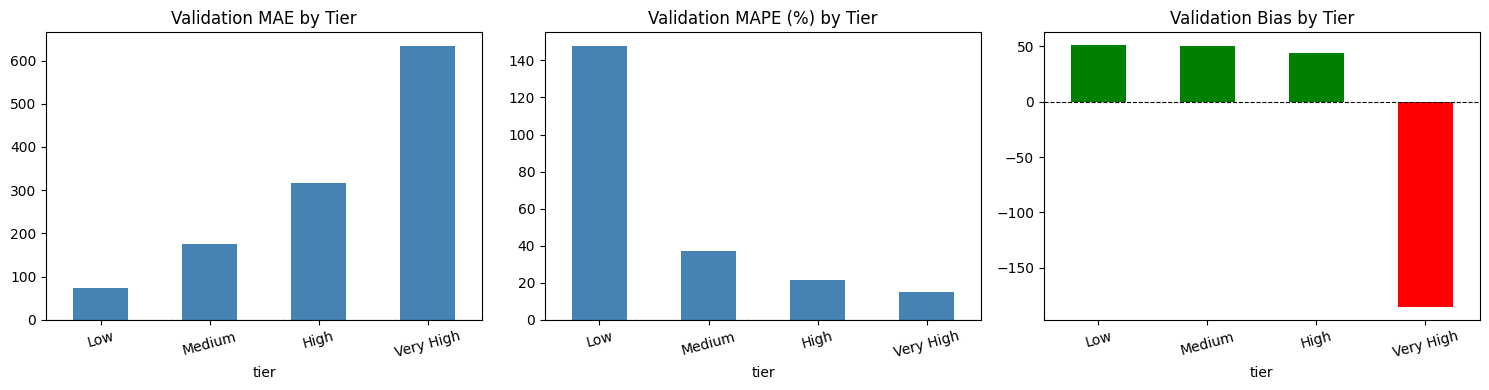

In [52]:
#Binning revenue conditions 
eval_val_df = pd.DataFrame({"y_true": y_val_revenue, "pred": val_pred_revenue})

bins = [-np.inf, 227, 882, 2439, np.inf]
labels = ["Low", "Medium", "High", "Very High"]
eval_val_df["tier"] = pd.cut(eval_val_df["y_true"], bins=bins, labels=labels)

# Vectorized Metric Calculation via GroupBy
def calculate_metrics(group):
    y, p = group["y_true"], group["pred"]
    diff = p - y
    mae = np.abs(diff).mean()
    rmse = np.sqrt((diff**2).mean())
    
    return pd.Series({
        "Count": len(y),
        "Mean Actual": y.mean(),
        "MAE": mae,
        "RMSE": rmse,
        "MAPE (%)": (np.abs(diff / y.replace(0, np.nan))).mean() * 100,
        "CV(RMSE) (%)": (rmse / y.mean() * 100) if y.mean() != 0 else np.nan,
        "Bias": diff.mean()
    })

tier_df = eval_val_df.groupby("tier", observed=False).apply(calculate_metrics).reset_index()
print(tier_df.round(3))

# Plotting
if not tier_df.empty:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    metrics = ["MAE", "MAPE (%)", "Bias"]

    for ax, m in zip(axes, metrics):
        colors = ["green" if v >= 0 else "red" for v in tier_df[m]] if m == "Bias" else "steelblue"
        tier_df.plot.bar(x="tier", y=m, ax=ax, color=colors, legend=False, rot=15)
        ax.set_title(f"Validation {m} by Tier")
        ax.axhline(0, color="black", lw=0.8, ls="--")
    
    plt.tight_layout()
    plt.show()

Here we see a more in depth characterization of the XGB model performance. We observe the raw MAE growing with demand, as expected, as spikes bring a higher noise floor. We also see massive increase in percentage MAPE at low revenue, this is expected as at very low revenue, the difference of a few rises has massive percentage change in overall revenue.

We also investigate the bias of the model, showing that on the validation set it overestimates revenue when revenue is low and underestimates when revenue is high, this is typical. This shows that the highest peaks in revenue are not being picked up.

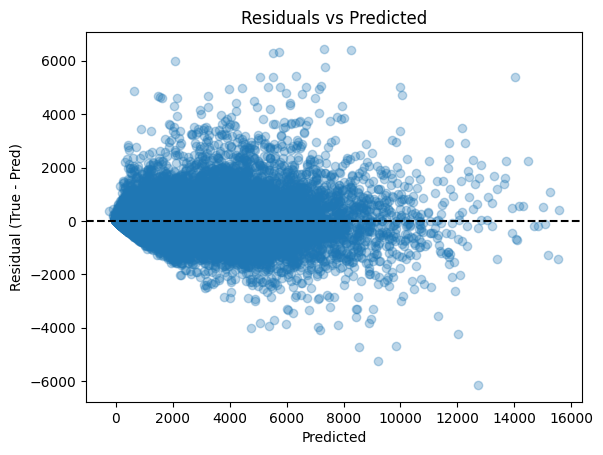

In [53]:
eval_val_df["residual"] = eval_val_df["y_true"] - eval_val_df["pred"]

plt.figure()
plt.scatter(eval_val_df["pred"], eval_val_df["residual"], alpha=0.3)
plt.axhline(0, color="black", linestyle="--")
plt.xlabel("Predicted")
plt.ylabel("Residual (True - Pred)")
plt.title("Residuals vs Predicted")
plt.show()

The above plot shows how error changes as the predicted values scales, we see error growing with increasing prediction revenue (heteroskedastic behaviour) and also note that we one again see it skewing to negative errors at higher predictions. Showing once again how the model underestimates large revenues.

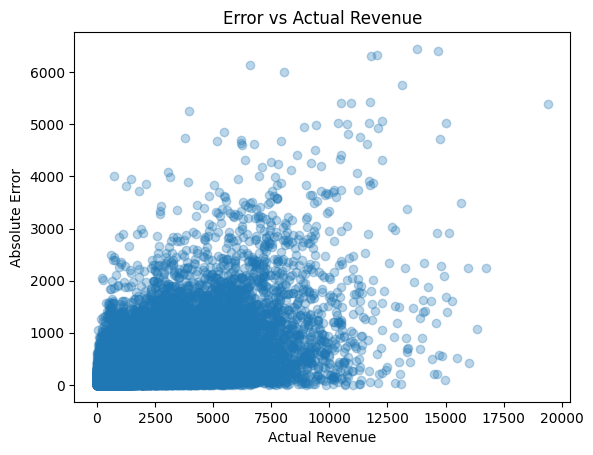

In [54]:
plt.figure()
plt.scatter(eval_val_df["y_true"], np.abs(eval_val_df["residual"]), alpha=0.3)
plt.xlabel("Actual Revenue")
plt.ylabel("Absolute Error")
plt.title("Error vs Actual Revenue")
plt.show()

Here we see the absolute error against the actual revenue and once again see a positive trend with error increasing with actual revenue. The model has the least variance and performs the best in low to medium revenue regimes, with degrading performance at the extremes, and gradual fall off in performance with increasing actual revenue.

In [55]:

#Accuracy by hour for
eval_val_df = pd.DataFrame({
    "hour": val_ready.loc[val_mask, "hour"].reset_index(drop=True).values,
    "actual": y_val_revenue.values,
    "pred": val_pred_revenue
})

#Errors
eval_val_df["error"] = eval_val_df["pred"] - eval_val_df["actual"]
eval_val_df["abs_error"] = eval_val_df["error"].abs()
eval_val_df["sq_error"] = eval_val_df["error"] ** 2

# Group by hour
hourly_metrics_revenue = (
    eval_val_df
    .groupby("hour")
    .agg(
        mean_actual=("actual", "mean"),
        mae=("abs_error", "mean"),
        rmse=("sq_error", lambda x: np.sqrt(np.mean(x))),
        bias=("error", "mean"),
        count=("actual", "size")
    )
    .reset_index()
)

#Relative MAE (%)
hourly_metrics_revenue["relative_mae_pct"] = (
    hourly_metrics_revenue["mae"] / hourly_metrics_revenue["mean_actual"] * 100
)

print(hourly_metrics_revenue.round(3))

    hour  mean_actual         mae        rmse       bias  count  \
0      0   882.809021  269.024994  514.017029  37.168999   2320   
1      1   635.132019  205.638000  414.842010  40.737000   2166   
2      2   479.460999  173.110001  339.002014  51.320000   1982   
3      3   349.828003  132.222000  239.621994  33.222000   1831   
4      4   246.395004  110.150002  180.026001  19.448000   1949   
5      5   258.769989  119.761002  182.369003  11.827000   2067   
6      6   445.102997  142.498001  227.313995  -7.786000   2274   
7      7   854.327026  235.669998  404.132996 -13.139000   2396   
8      8  1192.677979  269.454987  475.737000 -43.092999   2467   
9      9  1394.500977  253.518997  424.140015 -43.377998   2477   
10    10  1510.170044  242.746002  379.625000   5.870000   2502   
11    11  1681.181030  255.606003  382.464996   9.818000   2499   
12    12  1811.314941  264.502014  413.010986  -5.916000   2516   
13    13  1875.520020  271.243988  421.118011  13.426000   252

In [56]:
def compare_model_vs_baseline_by_hour(
    hours,
    actual,
    model_pred,
    baseline_pred,
    model_name="Model",
    baseline_name="Lag 2 Hour Baseline",
    title=None
):
    """
    Plot MAE by hour of day for model vs baseline.
    """

    # Convert to arrays
    hours = np.asarray(hours)
    actual = np.asarray(actual)
    model_pred = np.asarray(model_pred)
    baseline_pred = np.asarray(baseline_pred)

    # Safety check
    if not (len(hours) == len(actual) == len(model_pred) == len(baseline_pred)):
        raise ValueError(
            f"Length mismatch: hours={len(hours)}, actual={len(actual)}, "
            f"model_pred={len(model_pred)}, baseline_pred={len(baseline_pred)}"
        )

    # Build temporary dataframe
    df = pd.DataFrame({
        "hour": hours,
        "actual": actual,
        "model_pred": model_pred,
        "baseline_pred": baseline_pred
    })

    # Errors
    df["model_abs_error"] = (df["model_pred"] - df["actual"]).abs()
    df["baseline_abs_error"] = (df["baseline_pred"] - df["actual"]).abs()

    # Aggregate by hour
    hourly = (
        df.groupby("hour")
        .agg(
            mae_model=("model_abs_error", "mean"),
            mae_baseline=("baseline_abs_error", "mean")
        )
        .reset_index()
    )

    # Plot
    plt.figure(figsize=(7, 4))
    plt.plot(hourly["hour"], hourly["mae_model"], marker="o", label=model_name)
    plt.plot(hourly["hour"], hourly["mae_baseline"], marker="o", label=baseline_name)

    plt.xlabel("Hour of Day")
    plt.ylabel("MAE")
    plt.title(title if title else f"{model_name} vs {baseline_name} by Hour")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

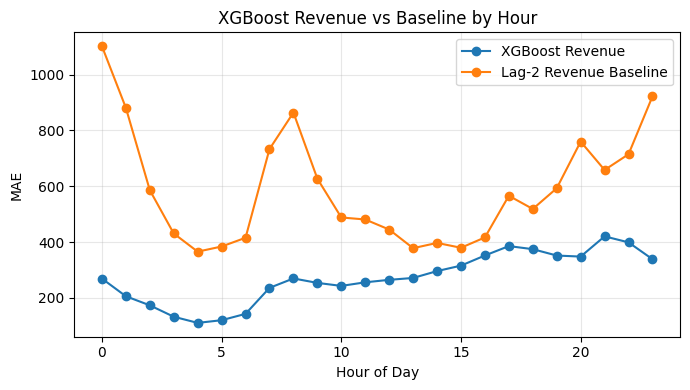

In [57]:

compare_model_vs_baseline_by_hour(
    hours=val_ready.loc[val_mask, "hour"].reset_index(drop=True).values,
    actual=y_val_revenue.values,
    model_pred=val_pred_revenue,
    baseline_pred=val_ready.loc[val_mask, "revenue_lag_2"].reset_index(drop=True).values,
    model_name="XGBoost Revenue",
    baseline_name="Lag-2 Revenue Baseline",
    title="XGBoost Revenue vs Baseline by Hour"

)

# Model 2 XGBoost for Demand Prediction

In [58]:

#XGBoost for demand

#XGBoost can handle NaNs
train_ready = train_ready.reset_index(drop=True)
val_ready = val_ready.reset_index(drop=True)

# One-hot encode location
train_ready_enc_dem, val_ready_enc_dem = one_hot_encode_location(train_ready, val_ready)


#feature list after encoding
location_cols_dem = [
    col for col in train_ready_enc_dem.columns
    if col.startswith("PULocationID_")
]

candidate_demand_features = (
    location_cols_dem +
    [
        "day_of_week",
        "month",
        "is_weekend",
        "hour_sin",
        "hour_cos",

        "demand_lag_2",
        "demand_lag_24",
        "demand_lag_4w",
        "demand_rolling_24",

        # "avg_trip_distance_lag2",
        # "avg_trip_distance_lag24",
        # "avg_duration_lag2",
        # "avg_duration_lag24",
        # "avg_passenger_count_lag2",
        # "avg_passenger_count_lag24",
    ]
)

#keep only columns that actually exist
demand_features = [
    col for col in candidate_demand_features
    if col in train_ready_enc_dem.columns
]

print("Demand features being used:")
print(demand_features)


# Final model datasets
X_train_demand = train_ready_enc_dem[demand_features].copy()
y_train_demand = train_ready_enc_dem["demand"].copy()

X_val_demand = val_ready_enc_dem[demand_features].copy()
y_val_demand = val_ready_enc_dem["demand"].copy()

print("X_train_demand shape:", X_train_demand.shape)
print("X_val_demand shape: ", X_val_demand.shape)


#XGBoost model
xgb_demand = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1,
    verbosity=1,
    tree_method="hist",
    device=XGB_DEVICE
)

xgb_demand, train_pred_demand, val_pred_demand, demand_metrics = evaluate_regression_model(
    model=xgb_demand,
    X_train=X_train_demand,
    y_train=y_train_demand,
    X_val=X_val_demand,
    y_val=y_val_demand,
    model_name="XGBoost Demand Model"
)

display_metrics(demand_metrics)

Demand features being used:
['PULocationID_4', 'PULocationID_12', 'PULocationID_13', 'PULocationID_24', 'PULocationID_41', 'PULocationID_42', 'PULocationID_43', 'PULocationID_45', 'PULocationID_48', 'PULocationID_50', 'PULocationID_68', 'PULocationID_74', 'PULocationID_75', 'PULocationID_79', 'PULocationID_87', 'PULocationID_88', 'PULocationID_90', 'PULocationID_100', 'PULocationID_105', 'PULocationID_107', 'PULocationID_113', 'PULocationID_114', 'PULocationID_116', 'PULocationID_120', 'PULocationID_125', 'PULocationID_127', 'PULocationID_128', 'PULocationID_137', 'PULocationID_140', 'PULocationID_141', 'PULocationID_142', 'PULocationID_143', 'PULocationID_144', 'PULocationID_148', 'PULocationID_151', 'PULocationID_152', 'PULocationID_153', 'PULocationID_158', 'PULocationID_161', 'PULocationID_162', 'PULocationID_163', 'PULocationID_164', 'PULocationID_166', 'PULocationID_170', 'PULocationID_186', 'PULocationID_194', 'PULocationID_202', 'PULocationID_209', 'PULocationID_211', 'PULocati

### Model 2 Evaluation 

### Overall Demand Prediction Performance

The demand model demonstrates strong overall predictive performance on the validation set. The Mean Absolute Error (MAE) is approximately 10.04 rides per hour per zone, compared to an average demand of 64.27 rides. This corresponds to a relative error of around 15.63%, indicating that predictions are typically within a reasonable range of actual demand.

The Root Mean Squared Error (RMSE) is 17.90, which is notably higher than the MAE. This suggests the presence of larger errors in some cases, particularly during high-demand periods where variability is greater.

The distribution of demand is highly skewed, with a median of 32 rides but a mean of 65 rides and a maximum exceeding 1000 rides per hour. This indicates that while most observations are relatively low to moderate, there are occasional extreme demand spikes. The standard deviation (approximately 80) further confirms the high variability in the data.

Given this variability, an MAE of around 10 rides represents a relatively strong level of performance. However, the gap between MAE and RMSE highlights that the model struggles more with extreme demand values than with typical conditions.

Overall, the model captures general demand patterns well and provides a useful level of accuracy for operational planning, although performance is weaker during rare, high-demand spikes.

In [59]:
print(y_train_demand.describe())

mae = demand_metrics["val_mae"]
mean_val = y_val_demand.mean()

print("MAE:", mae)
print("Mean demand:", mean_val)
print("Relative MAE (%):", (mae / mean_val) * 100)

print("Std demand:", y_val_demand.std())
print("RMSE:", demand_metrics["val_rmse"])

count    340955.000000
mean         65.095086
std          81.929213
min           1.000000
25%           7.000000
50%          32.000000
75%          95.000000
max        1005.000000
Name: demand, dtype: float64
MAE: 11.056591033935547
Mean demand: 62.27526236881559
Relative MAE (%): 17.754386916035134
Std demand: 77.86252386366546
RMSE: 20.032812286726852


### Evaluating Model

### Train vs Validation Performance

The model shows strong and consistent performance across both training and validation sets. The training MAE is 9.13 compared to a validation MAE of 10.05, while RMSE increases from 15.28 to 17.90. Similarly, \(R^2\) decreases slightly from 0.965 to 0.950.

This relatively small gap between training and validation metrics suggests that the model generalises well and is not significantly overfitting the training data. The slight degradation in performance on the validation set is expected, particularly given the variability and presence of extreme demand values.

Overall, the consistency between training and validation performance indicates that the model has learned stable patterns in the data and is likely to perform reliably on unseen future demand.

In [60]:
display_metrics(demand_metrics)

Model: XGBoost Demand Model
Train RMSE: 16.707
val RMSE:  20.033
Train MAE:  9.717
val MAE:   11.057
Train R²:   0.958
val R²:    0.934


### Performance by Demand Level

- **Absolute error increases with demand:**
  - Low demand: MAE ≈ 2.44 rides/hour  
  - Very high demand: MAE ≈ 21.07 rides/hour  
  - Reflects higher variability and difficulty during peak periods  

- **Relative performance improves at higher demand:**
  - MAPE drops from ~107% (low) → ~12.33% (very high)  
  - Small absolute errors inflate percentage error at low demand  
  - Model is proportionally more accurate in high-demand scenarios  

- **Stability improves with demand:**
  - CV(RMSE) decreases from ~117% → ~16.84%  
  - Indicates more consistent performance in higher-demand conditions  

- **Systematic bias (regression to the mean):**
  - Overestimates low/medium/high demand (+1.66 to +1.96 rides)  
  - Underestimates very high demand (−4.28 rides)  
  - Extreme demand spikes are not fully captured  

- **Operational implications:**
  - Low-demand errors: high % error but low practical impact  
  - High-demand errors: lower % error but more costly  
    - Risk of under-allocation of drivers  
    - Increased waiting times  
    - Potential lost revenue  

        tier    Count  Mean Actual     MAE    RMSE  MAPE (%)  CV(RMSE) (%)  \
0        Low  14944.0        3.275   2.428   3.807   109.934       116.236   
1     Medium  13529.0       17.162   5.882   8.678    36.395        50.566   
2       High  14049.0       57.787  12.034  16.665    21.794        28.839   
3  Very High  14173.0      171.997  24.125  35.254    14.390        20.497   

    Bias  
0  1.615  
1  1.695  
2  2.428  
3 -5.447  


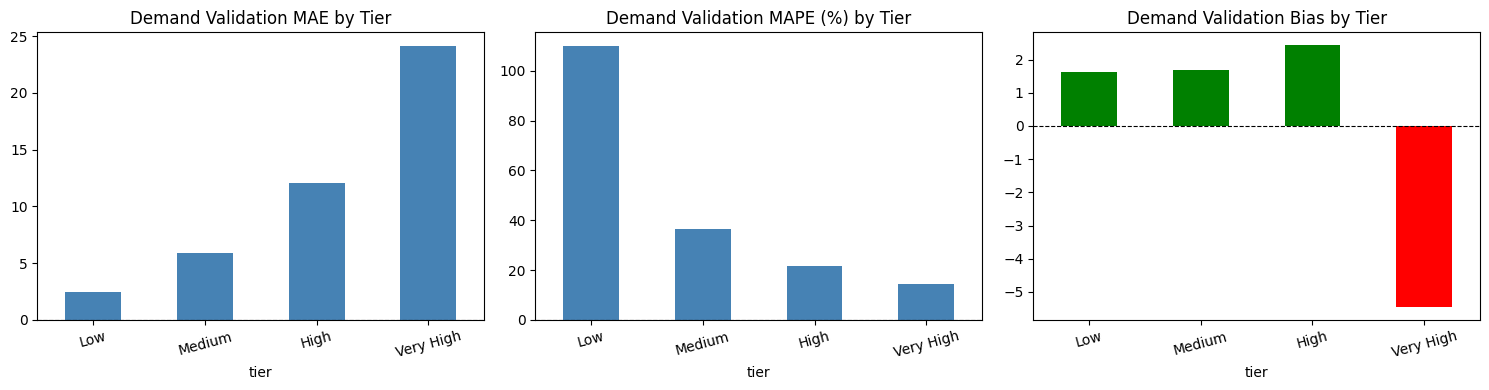

In [61]:

# Binning demand conditions
eval_val_df = pd.DataFrame({
    "y_true": y_val_demand,
    "pred": val_pred_demand
})

#Create demand-based bins from actual validation demand
bins = [
    -np.inf,
    eval_val_df["y_true"].quantile(0.25),
    eval_val_df["y_true"].quantile(0.50),
    eval_val_df["y_true"].quantile(0.75),
    np.inf
]

labels = ["Low", "Medium", "High", "Very High"]
eval_val_df["tier"] = pd.cut(eval_val_df["y_true"], bins=bins, labels=labels, include_lowest=True)


#Vectorized Metric Calculation via GroupBy
def calculate_metrics(group):
    y, p = group["y_true"], group["pred"]
    diff = p - y
    mae = np.abs(diff).mean()
    rmse = np.sqrt((diff**2).mean())

    return pd.Series({
        "Count": len(y),
        "Mean Actual": y.mean(),
        "MAE": mae,
        "RMSE": rmse,
        "MAPE (%)": (np.abs(diff / y.replace(0, np.nan))).mean() * 100,
        "CV(RMSE) (%)": (rmse / y.mean() * 100) if y.mean() != 0 else np.nan,
        "Bias": diff.mean()
    })

tier_df = eval_val_df.groupby("tier", observed=False).apply(calculate_metrics).reset_index()
print(tier_df.round(3))


#Plot
if not tier_df.empty:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    metrics = ["MAE", "MAPE (%)", "Bias"]

    for ax, m in zip(axes, metrics):
        colors = ["green" if v >= 0 else "red" for v in tier_df[m]] if m == "Bias" else "steelblue"
        tier_df.plot.bar(x="tier", y=m, ax=ax, color=colors, legend=False, rot=15)
        ax.set_title(f"Demand Validation {m} by Tier")
        ax.axhline(0, color="black", lw=0.8, ls="--")

    plt.tight_layout()
    plt.show()

Here we present a more detailed evaluation of the demand model across different demand levels.

As expected, the absolute error (MAE and RMSE) increases with demand. Low-demand periods have an average error of approximately 2–4 rides per hour, while very high-demand periods show errors of around 20–30 rides per hour. This reflects the increased variability and difficulty of predicting peak demand conditions.

In relative terms, percentage error (MAPE) is extremely high in low-demand scenarios (over 100\%), but this is largely a scaling issue. When demand is very low, even small absolute errors correspond to large percentage changes. As demand increases, MAPE decreases significantly, indicating that the model is proportionally more accurate during moderate and high-demand periods.

The coefficient of variation of RMSE (CV(RMSE)) shows a similar pattern, with very high relative variability at low demand and more stable performance as demand increases. This suggests that the model is most reliable under typical operating conditions rather than at the extremes.

Bias analysis reveals that the model tends to overestimate demand in low- and medium-demand conditions, while slightly underestimating demand during very high-demand periods. This indicates a regression-to-the-mean effect, where extreme peaks are not fully captured by the model.

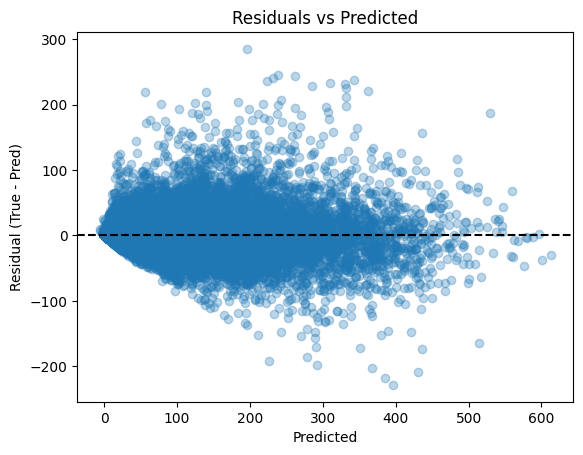

In [62]:
eval_val_df["residual"] = eval_val_df["y_true"] - eval_val_df["pred"]

plt.figure()
plt.scatter(eval_val_df["pred"], eval_val_df["residual"], alpha=0.3)
plt.axhline(0, color="black", linestyle="--")
plt.xlabel("Predicted")
plt.ylabel("Residual (True - Pred)")
plt.title("Residuals vs Predicted")
plt.show()

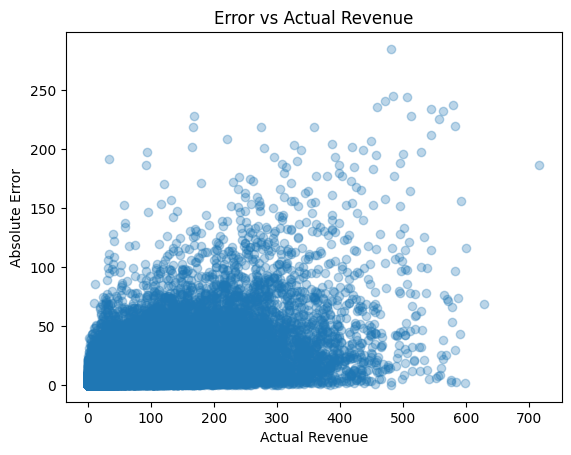

In [63]:
plt.figure()
plt.scatter(eval_val_df["y_true"], np.abs(eval_val_df["residual"]), alpha=0.3)
plt.xlabel("Actual Revenue")
plt.ylabel("Absolute Error")
plt.title("Error vs Actual Revenue")
plt.show()

Here we see the absolute error against the actual demand and once again see a positive trend with error increasing with actual demand. The model has the least variance and performs the best in low to medium demand regimes, with degrading performance at the extremes, and gradual fall off in performance with increasing actual revenue.

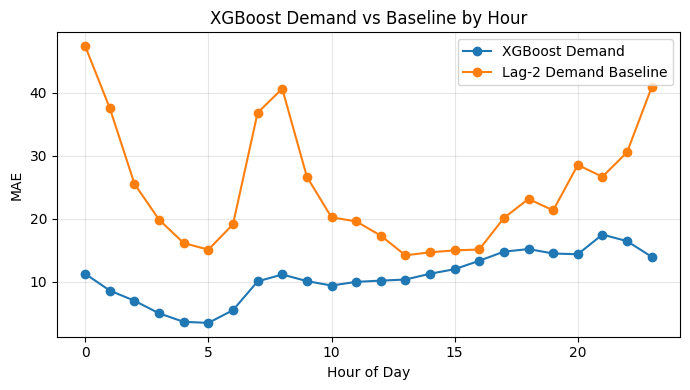

In [64]:
compare_model_vs_baseline_by_hour(
    hours=val_ready["hour"].values,
    actual=y_val_demand.values,
    model_pred=val_pred_demand,
    baseline_pred=val_ready["demand_lag_2"].values,
    model_name="XGBoost Demand",
    baseline_name="Lag-2 Demand Baseline",
    title="XGBoost Demand vs Baseline by Hour"
)

### Model 3: Random forest predicting revenue 

In [65]:
# Note: sklearn RandomForestRegressor does not support GPU training; this model remains CPU-based.
print("Random Forest uses CPU (scikit-learn has no GPU training support for this estimator).")


#Random Forest for revenue


from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

#Use prepared datasets
train_ready = train_ready.reset_index(drop=True)
val_ready = val_ready.reset_index(drop=True)

#One-hot encode location
train_ready_enc, val_ready_enc = one_hot_encode_location(train_ready, val_ready)


# feature list after encoding
location_cols = [col for col in train_ready_enc.columns if col.startswith("PULocationID_")]

base_features = (
    location_cols +
    [
        "day_of_week",
        "month",
        "is_weekend",
        "hour_sin",
        "hour_cos",

        "demand_lag_2",
        "demand_lag_24",
        "demand_lag_4w",
        "demand_rolling_24",

        # "avg_trip_distance_lag2",
        # "avg_trip_distance_lag24",
        # "avg_duration_lag2",
        # "avg_duration_lag24",
        # "avg_passenger_count_lag2",
        # "avg_passenger_count_lag24",
    ]
)

revenue_only_features = [
    "revenue_lag_2",
    "revenue_lag_24",
    "revenue_rolling_24",
]

candidate_revenue_features = base_features + revenue_only_features

# keep only columns that actually exist
revenue_features = [col for col in candidate_revenue_features if col in train_ready_enc.columns]

print("Revenue features being used:")
print(revenue_features)


#Final model datasets
X_train_revenue = train_ready_enc[revenue_features].copy()
y_train_revenue = train_ready_enc["total_revenue"].copy()

X_val_revenue = val_ready_enc[revenue_features].copy()
y_val_revenue = val_ready_enc["total_revenue"].copy()


# Impose 100,000 cutoff to get rid of outliers
upper_cutoff = 100000

train_mask = y_train_revenue <= upper_cutoff
val_mask = y_val_revenue <= upper_cutoff

X_train_revenue = X_train_revenue.loc[train_mask].reset_index(drop=True)
y_train_revenue = y_train_revenue.loc[train_mask].reset_index(drop=True)

X_val_revenue = X_val_revenue.loc[val_mask].reset_index(drop=True)
y_val_revenue = y_val_revenue.loc[val_mask].reset_index(drop=True)

print("X_train_revenue shape:", X_train_revenue.shape)
print("X_val_revenue shape: ", X_val_revenue.shape)


#Random Forest pipeline
rf_revenue = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestRegressor(
        n_estimators=300,
        max_depth=6,
        random_state=42,
        n_jobs=-1,
        verbose=1
    ))
])

rf_revenue, train_pred_rf_revenue, val_pred_rf_revenue, rf_revenue_metrics = evaluate_regression_model(
    model=rf_revenue,
    X_train=X_train_revenue,
    y_train=y_train_revenue,
    X_val=X_val_revenue,
    y_val=y_val_revenue,
    model_name="Random Forest Revenue Model"
)

display_metrics(rf_revenue_metrics)

Random Forest uses CPU (scikit-learn has no GPU training support for this estimator).
Revenue features being used:
['PULocationID_4', 'PULocationID_12', 'PULocationID_13', 'PULocationID_24', 'PULocationID_41', 'PULocationID_42', 'PULocationID_43', 'PULocationID_45', 'PULocationID_48', 'PULocationID_50', 'PULocationID_68', 'PULocationID_74', 'PULocationID_75', 'PULocationID_79', 'PULocationID_87', 'PULocationID_88', 'PULocationID_90', 'PULocationID_100', 'PULocationID_105', 'PULocationID_107', 'PULocationID_113', 'PULocationID_114', 'PULocationID_116', 'PULocationID_120', 'PULocationID_125', 'PULocationID_127', 'PULocationID_128', 'PULocationID_137', 'PULocationID_140', 'PULocationID_141', 'PULocationID_142', 'PULocationID_143', 'PULocationID_144', 'PULocationID_148', 'PULocationID_151', 'PULocationID_152', 'PULocationID_153', 'PULocationID_158', 'PULocationID_161', 'PULocationID_162', 'PULocationID_163', 'PULocationID_164', 'PULocationID_166', 'PULocationID_170', 'PULocationID_186', 'P

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    5.9s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:   30.1s
[Parallel(n_jobs=-1)]: Done 300 out of 300 | elapsed:   50.6s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    0.2s


Model: Random Forest Revenue Model
Train RMSE: 604.176
val RMSE:  705.484
Train MAE:  355.308
val MAE:   387.507
Train R²:   0.904
val R²:    0.850


[Parallel(n_jobs=12)]: Done 300 out of 300 | elapsed:    0.3s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 300 out of 300 | elapsed:    0.1s finished


### Model 3 Evaluation 

        tier    Count  Mean Actual      MAE      RMSE  MAPE (%)  CV(RMSE) (%)  \
0        Low  14174.0       78.010  134.676   212.377   351.757       272.245   
1     Medium  14174.0      409.964  193.809   300.148    51.519        73.213   
2       High  14173.0     1336.900  373.903   496.535    29.375        37.141   
3  Very High  14174.0     4004.411  847.638  1268.493    21.115        31.677   

      Bias  
0  128.228  
1   79.689  
2   31.741  
3 -382.719  


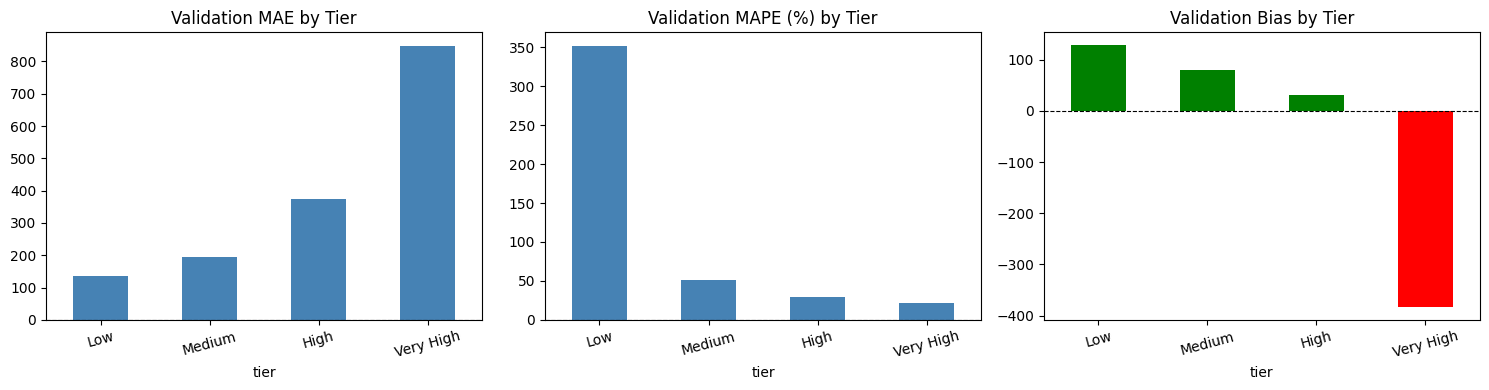

In [66]:
#Binning revenue conditions 
eval_val_df = pd.DataFrame({"y_true": y_val_revenue, "pred": val_pred_rf_revenue})


bins = [
    -np.inf,
    eval_val_df["y_true"].quantile(0.25),
    eval_val_df["y_true"].quantile(0.50),
    eval_val_df["y_true"].quantile(0.75),
    np.inf
]
labels = ["Low", "Medium", "High", "Very High"]
eval_val_df["tier"] = pd.cut(eval_val_df["y_true"], bins=bins, labels=labels)

# Vectorized Metric Calculation via GroupBy
def calculate_metrics(group):
    y, p = group["y_true"], group["pred"]
    diff = p - y
    mae = np.abs(diff).mean()
    rmse = np.sqrt((diff**2).mean())
    
    return pd.Series({
        "Count": len(y),
        "Mean Actual": y.mean(),
        "MAE": mae,
        "RMSE": rmse,
        "MAPE (%)": (np.abs(diff / y.replace(0, np.nan))).mean() * 100,
        "CV(RMSE) (%)": (rmse / y.mean() * 100) if y.mean() != 0 else np.nan,
        "Bias": diff.mean()
    })

tier_df = eval_val_df.groupby("tier", observed=False).apply(calculate_metrics).reset_index()
print(tier_df.round(3))

# Plotting
if not tier_df.empty:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    metrics = ["MAE", "MAPE (%)", "Bias"]

    for ax, m in zip(axes, metrics):
        colors = ["green" if v >= 0 else "red" for v in tier_df[m]] if m == "Bias" else "steelblue"
        tier_df.plot.bar(x="tier", y=m, ax=ax, color=colors, legend=False, rot=15)
        ax.set_title(f"Validation {m} by Tier")
        ax.axhline(0, color="black", lw=0.8, ls="--")
    
    plt.tight_layout()
    plt.show()

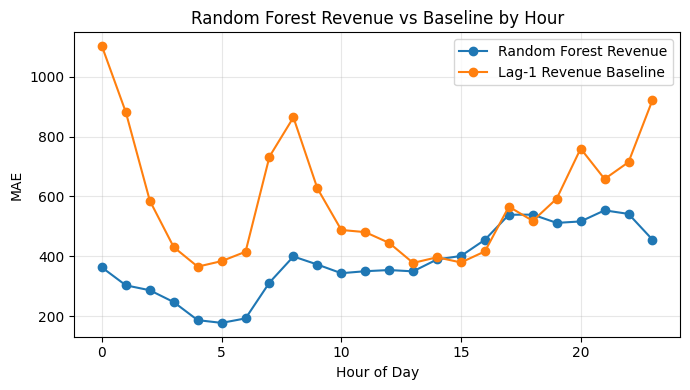

In [67]:
compare_model_vs_baseline_by_hour(
    hours=val_ready.loc[val_mask, "hour"].reset_index(drop=True).values,
    actual=y_val_revenue.values,
    model_pred=val_pred_rf_revenue,
    baseline_pred=val_ready.loc[val_mask, "revenue_lag_2"].reset_index(drop=True).values,
    model_name="Random Forest Revenue",
    baseline_name="Lag-1 Revenue Baseline",
    title="Random Forest Revenue vs Baseline by Hour"
)

### Model 4 RF Model Demand 

In [68]:
# Note: sklearn RandomForestRegressor does not support GPU training; this model remains CPU-based.
print("Random Forest uses CPU (scikit-learn has no GPU training support for this estimator).")


#Model: Random Forest for demand
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

#Use prepared datasets
train_ready = train_ready.reset_index(drop=True)
val_ready = val_ready.reset_index(drop=True)

# One-hot encode location
train_ready_enc_dem, val_ready_enc_dem = one_hot_encode_location(train_ready, val_ready)


#feature list after encoding
location_cols_dem = [
    col for col in train_ready_enc_dem.columns
    if col.startswith("PULocationID_")
]

candidate_demand_features = (
    location_cols_dem +
    [
        "day_of_week",
        "month",
        "is_weekend",
        "hour_sin",
        "hour_cos",

        "demand_lag_2",
        "demand_lag_24",
        "demand_lag_4w",
        "demand_rolling_24",

        # "avg_trip_distance_lag2",
        # "avg_trip_distance_lag24",
        # "avg_duration_lag2",
        # "avg_duration_lag24",
        # "avg_passenger_count_lag2",
        # "avg_passenger_count_lag24",
    ]
)

#keep only columns that actually exist
demand_features = [
    col for col in candidate_demand_features
    if col in train_ready_enc_dem.columns
]

print("Demand features being used:")
print(demand_features)


#Final model datasets
X_train_demand = train_ready_enc_dem[demand_features].copy()
y_train_demand = train_ready_enc_dem["demand"].copy()

X_val_demand = val_ready_enc_dem[demand_features].copy()
y_val_demand = val_ready_enc_dem["demand"].copy()

print("X_train_demand shape:", X_train_demand.shape)
print("X_val_demand shape: ", X_val_demand.shape)


#Random Forest pipeline
rf_demand = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestRegressor(
        n_estimators=300,
        max_depth=6,
        random_state=42,
        n_jobs=-1,
        verbose=0
    ))
])

rf_demand, train_pred_rf_demand, val_pred_rf_demand, rf_demand_metrics = evaluate_regression_model(
    model=rf_demand,
    X_train=X_train_demand,
    y_train=y_train_demand,
    X_val=X_val_demand,
    y_val=y_val_demand,
    model_name="Random Forest Demand Model"
)

display_metrics(rf_demand_metrics)

Random Forest uses CPU (scikit-learn has no GPU training support for this estimator).
Demand features being used:
['PULocationID_4', 'PULocationID_12', 'PULocationID_13', 'PULocationID_24', 'PULocationID_41', 'PULocationID_42', 'PULocationID_43', 'PULocationID_45', 'PULocationID_48', 'PULocationID_50', 'PULocationID_68', 'PULocationID_74', 'PULocationID_75', 'PULocationID_79', 'PULocationID_87', 'PULocationID_88', 'PULocationID_90', 'PULocationID_100', 'PULocationID_105', 'PULocationID_107', 'PULocationID_113', 'PULocationID_114', 'PULocationID_116', 'PULocationID_120', 'PULocationID_125', 'PULocationID_127', 'PULocationID_128', 'PULocationID_137', 'PULocationID_140', 'PULocationID_141', 'PULocationID_142', 'PULocationID_143', 'PULocationID_144', 'PULocationID_148', 'PULocationID_151', 'PULocationID_152', 'PULocationID_153', 'PULocationID_158', 'PULocationID_161', 'PULocationID_162', 'PULocationID_163', 'PULocationID_164', 'PULocationID_166', 'PULocationID_170', 'PULocationID_186', 'PU

### Model 4 Evaluation 

        tier    Count  Mean Actual     MAE    RMSE  MAPE (%)  CV(RMSE) (%)  \
0        Low  14944.0        3.275   4.964   9.234   246.729       281.915   
1     Medium  13529.0       17.162   8.178  12.924    52.148        75.309   
2       High  14049.0       57.787  15.533  21.429    28.129        37.083   
3  Very High  14173.0      171.997  34.373  53.373    19.808        31.031   

     Bias  
0   4.471  
1   3.652  
2   1.288  
3 -16.372  


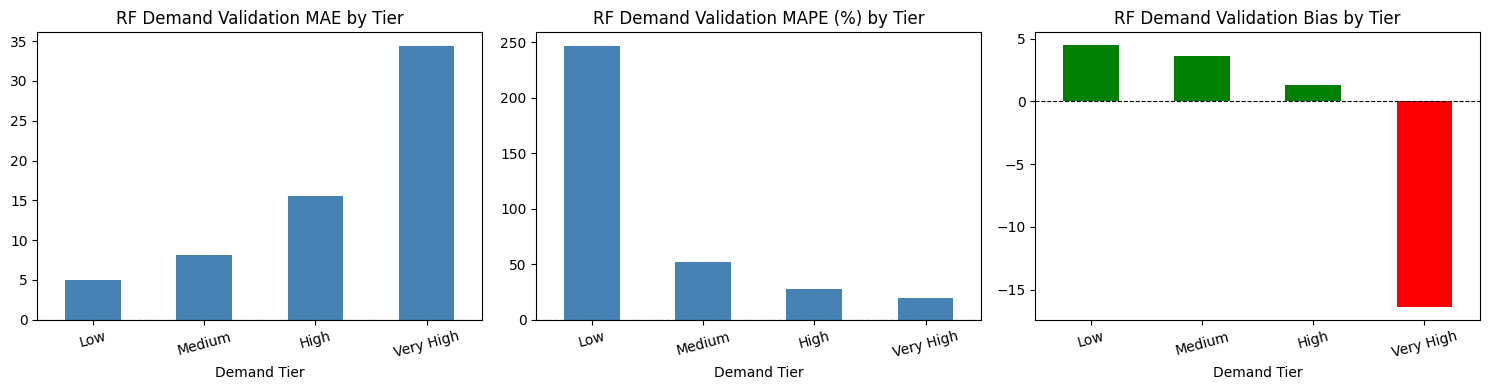

In [69]:
# binning demand conditions
eval_val_df = pd.DataFrame({
    "y_true": y_val_demand,
    "pred": val_pred_rf_demand
})


bins = [
    -np.inf,
    eval_val_df["y_true"].quantile(0.25),
    eval_val_df["y_true"].quantile(0.50),
    eval_val_df["y_true"].quantile(0.75),
    np.inf
]
labels = ["Low", "Medium", "High", "Very High"]

eval_val_df["tier"] = pd.cut(eval_val_df["y_true"], bins=bins, labels=labels)

# Vectorized Metric Calculation
def calculate_metrics(group):
    y, p = group["y_true"], group["pred"]
    diff = p - y
    mae = np.abs(diff).mean()
    rmse = np.sqrt((diff**2).mean())

    return pd.Series({
        "Count": len(y),
        "Mean Actual": y.mean(),
        "MAE": mae,
        "RMSE": rmse,
        "MAPE (%)": (np.abs(diff / y.replace(0, np.nan))).mean() * 100,
        "CV(RMSE) (%)": (rmse / y.mean() * 100) if y.mean() != 0 else np.nan,
        "Bias": diff.mean()
    })

tier_df = eval_val_df.groupby("tier", observed=False).apply(calculate_metrics).reset_index()

print(tier_df.round(3))

# Plots
if not tier_df.empty:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    metrics = ["MAE", "MAPE (%)", "Bias"]

    for ax, m in zip(axes, metrics):
        colors = ["green" if v >= 0 else "red" for v in tier_df[m]] if m == "Bias" else "steelblue"
        tier_df.plot.bar(x="tier", y=m, ax=ax, color=colors, legend=False, rot=15)
        ax.set_title(f"RF Demand Validation {m} by Tier")
        ax.axhline(0, color="black", lw=0.8, ls="--")
        ax.set_xlabel("Demand Tier")

    plt.tight_layout()
    plt.show()

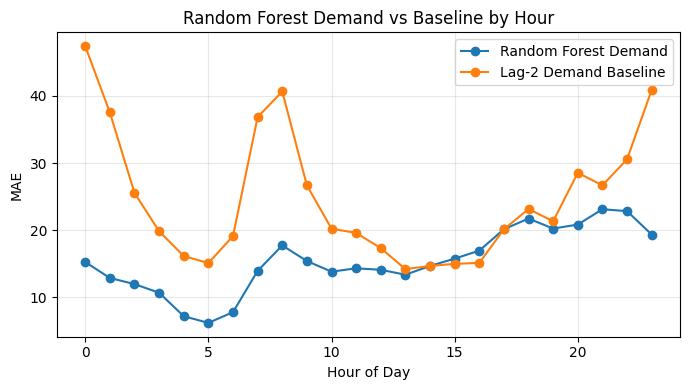

In [70]:
compare_model_vs_baseline_by_hour(
    hours=val_ready["hour"].values,
    actual=y_val_demand.values,
    model_pred=val_pred_rf_demand,
    baseline_pred=val_ready["demand_lag_2"].values,  # or demand_lag_2
    model_name="Random Forest Demand",
    baseline_name="Lag-2 Demand Baseline",
    title="Random Forest Demand vs Baseline by Hour"
)

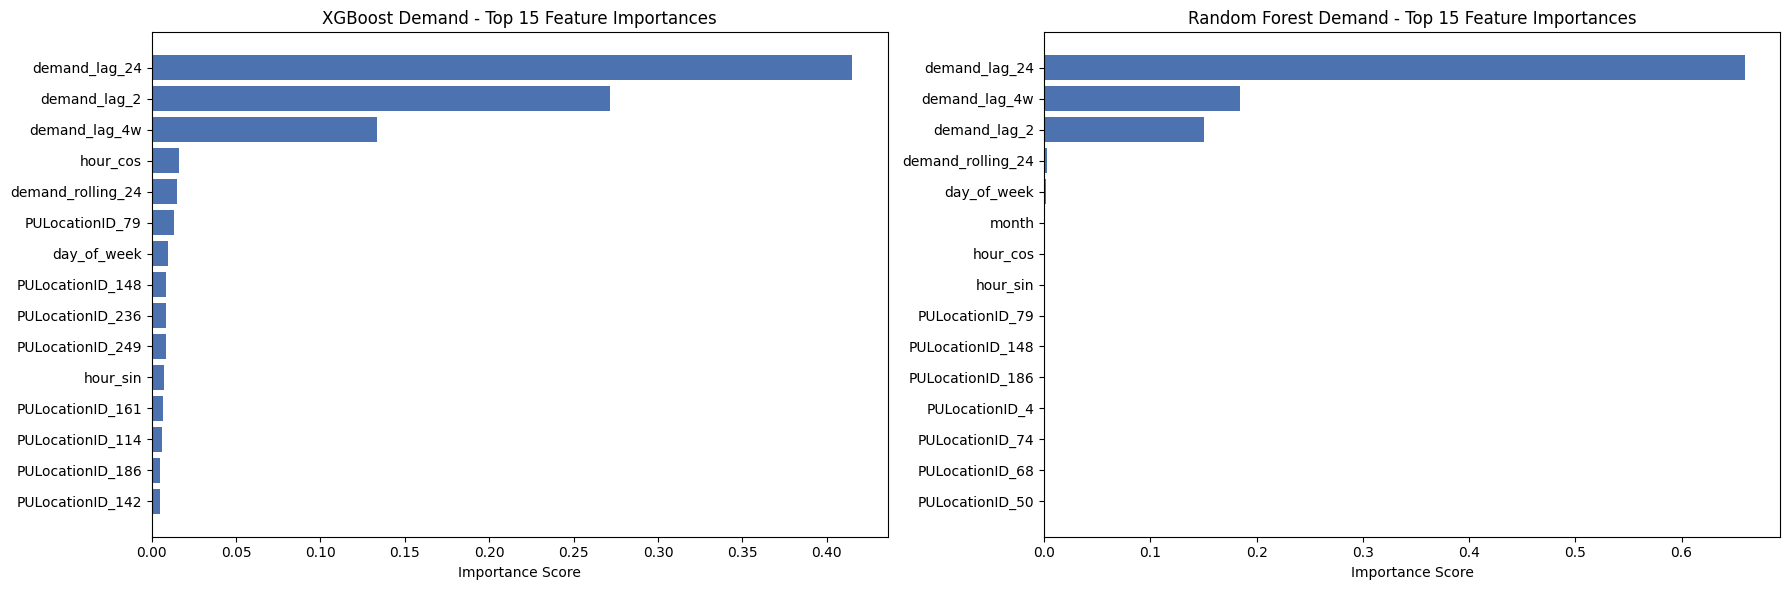

XGBoost top 10 demand features:
demand_lag_24        0.4152
demand_lag_2         0.2715
demand_lag_4w        0.1337
hour_cos             0.0163
demand_rolling_24    0.0153
PULocationID_79      0.0132
day_of_week          0.0096
PULocationID_148     0.0087
PULocationID_236     0.0084
PULocationID_249     0.0083
dtype: float32

Random Forest top 10 demand features:
demand_lag_24        0.6596
demand_lag_4w        0.1842
demand_lag_2         0.1509
demand_rolling_24    0.0031
day_of_week          0.0020
month                0.0001
hour_cos             0.0000
hour_sin             0.0000
PULocationID_79      0.0000
PULocationID_148     0.0000
dtype: float64


In [71]:
# Feature Importance
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# XGBoost
xgb_importance = pd.Series(
    xgb_demand.feature_importances_,
    index=demand_features
).sort_values(ascending=False).head(15)

axes[0].barh(xgb_importance.index[::-1], xgb_importance.values[::-1], color="#4C72B0")
axes[0].set_title("XGBoost Demand - Top 15 Feature Importances")
axes[0].set_xlabel("Importance Score")

# Random Forest
rf_importance = pd.Series(
    rf_demand.named_steps["model"].feature_importances_,
    index=demand_features
).sort_values(ascending=False).head(15)

axes[1].barh(rf_importance.index[::-1], rf_importance.values[::-1], color="#4C72B0")
axes[1].set_title("Random Forest Demand - Top 15 Feature Importances")
axes[1].set_xlabel("Importance Score")

plt.tight_layout()
plt.show()

# Top 10 features for both
print("XGBoost top 10 demand features:")
print(xgb_importance.head(10).round(4))
print()
print("Random Forest top 10 demand features:")
print(rf_importance.head(10).round(4))

In [93]:
rf_importance_full = pd.Series(
    rf_demand.named_steps["model"].feature_importances_,
    index=demand_features
)

xgb_importance_full = pd.Series(
    xgb_demand.feature_importances_,
    index=demand_features
)

location_importance_xgb = xgb_importance_full[
    xgb_importance_full.index.str.startswith("PULocationID_")
].sum()

location_importance_rf = rf_importance_full[
    rf_importance_full.index.str.startswith("PULocationID_")
].sum()

print()
print(f"XGBoost - collective location importance: {location_importance_xgb:.4f}")
print(f"Random Forest - collective location importance: {location_importance_rf:.5f}")



XGBoost - collective location importance: 0.1219
Random Forest - collective location importance: 0.00002


## Model 5: Neural Network for Revenue Prediction

Architecture: ResNet-style MLP with entity embeddings for PULocationID  
Target: `log1p(total_revenue)` — inverse-transformed for evaluation  
Loss: MSE on log-transformed target (reduces heteroskedasticity)  
Optimizer: AdamW with linear warmup + ReduceLROnPlateau  
Training: GPU-accelerated

In [72]:

# Model 5: Neural Network for Revenue Prediction


import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Device Setup (GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_CUDA = device.type == "cuda"
print(f"Using device: {device}")
if USE_CUDA:
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("Warning: CUDA not available. PyTorch models will fall back to CPU.")

# Model Architecture


class ResBlock(nn.Module):
    """Residual block with BatchNorm, SiLU activation, and Dropout."""
    def __init__(self, in_dim, out_dim, dropout=0.2):
        super().__init__()
        self.fc1 = nn.Linear(in_dim, out_dim)
        self.bn1 = nn.BatchNorm1d(out_dim)
        self.fc2 = nn.Linear(out_dim, out_dim)
        self.bn2 = nn.BatchNorm1d(out_dim)
        self.drop = nn.Dropout(dropout)
        self.skip = nn.Linear(in_dim, out_dim) if in_dim != out_dim else nn.Identity()

    def forward(self, x):
        residual = self.skip(x)
        out = F.silu(self.bn1(self.fc1(x)))
        out = self.drop(out)
        out = self.bn2(self.fc2(out))
        return F.silu(out + residual)


class TabularResNet(nn.Module):
    """ResNet-style MLP with entity embedding for categorical location."""
    def __init__(self, n_locations, emb_dim, n_cont, hidden_dims, dropouts):
        super().__init__()
        self.loc_emb = nn.Embedding(n_locations, emb_dim)
        nn.init.xavier_uniform_(self.loc_emb.weight)
        input_dim = n_cont + emb_dim
        self.input_bn = nn.BatchNorm1d(input_dim)
        blocks = []
        in_d = input_dim
        for h, d in zip(hidden_dims, dropouts):
            blocks.append(ResBlock(in_d, h, d))
            in_d = h
        self.blocks = nn.Sequential(*blocks)
        self.head = nn.Linear(in_d, 1)

    def forward(self, loc_ids, x_cont):
        emb = self.loc_emb(loc_ids)
        x = torch.cat([emb, x_cont], dim=1)
        x = self.input_bn(x)
        x = self.blocks(x)
        return self.head(x).squeeze(-1)



# Training Utilities

def train_tabular_nn(model, train_loader, val_loader, device,
                     n_epochs=200, patience=20, lr=1e-3, warmup_epochs=5):
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=7, min_lr=1e-6
    )
    criterion = nn.MSELoss()

    best_val_loss = float("inf")
    patience_counter = 0
    best_state = None
    history = {"train_loss": [], "val_loss": [], "train_r2": [], "val_r2": []}

    for epoch in range(n_epochs):
        if epoch < warmup_epochs:
            for pg in optimizer.param_groups:
                pg["lr"] = lr * (epoch + 1) / warmup_epochs

        # Train
        model.train()
        epoch_loss, n = 0.0, 0
        train_preds_e, train_tgts_e = [], []
        for loc, cont, target in train_loader:
            loc = loc.to(device, non_blocking=USE_CUDA)
            cont = cont.to(device, non_blocking=USE_CUDA)
            target = target.to(device, non_blocking=USE_CUDA)
            optimizer.zero_grad()
            pred = model(loc, cont)
            loss = criterion(pred, target)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            epoch_loss += loss.item() * len(target)
            n += len(target)
            train_preds_e.append(pred.detach().cpu().numpy())
            train_tgts_e.append(target.cpu().numpy())
        train_loss = epoch_loss / n
        train_preds_e = np.concatenate(train_preds_e)
        train_tgts_e = np.concatenate(train_tgts_e)
        train_r2 = r2_score(train_tgts_e, train_preds_e)

        # Validation 
        model.eval()
        val_loss_sum, val_n = 0.0, 0
        val_preds_e, val_tgts_e = [], []
        with torch.no_grad():
            for loc, cont, target in val_loader:
                loc = loc.to(device, non_blocking=USE_CUDA)
                cont = cont.to(device, non_blocking=USE_CUDA)
                target = target.to(device, non_blocking=USE_CUDA)
                pred = model(loc, cont)
                loss = criterion(pred, target)
                val_loss_sum += loss.item() * len(target)
                val_n += len(target)
                val_preds_e.append(pred.cpu().numpy())
                val_tgts_e.append(target.cpu().numpy())
        val_loss = val_loss_sum / val_n
        val_preds_e = np.concatenate(val_preds_e)
        val_tgts_e = np.concatenate(val_tgts_e)
        val_r2 = r2_score(val_tgts_e, val_preds_e)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_r2"].append(train_r2)
        history["val_r2"].append(val_r2)
        scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            patience_counter += 1

        if (epoch + 1) % 10 == 0:
            curr_lr = optimizer.param_groups[0]["lr"]
            print(f"Epoch {epoch+1:>3}/{n_epochs} | Train: {train_loss:.6f} | Val: {val_loss:.6f} | LR: {curr_lr:.2e} | Pat: {patience_counter}/{patience}")

        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch + 1}")
            break

    model.load_state_dict(best_state)
    model.to(device)
    return model, history


def predict_tabular_nn(model, loader, device):
    model.eval()
    preds = []
    with torch.no_grad():
        for loc, cont, _ in loader:
            loc, cont = loc.to(device, non_blocking=USE_CUDA), cont.to(device, non_blocking=USE_CUDA)
            preds.append(model(loc, cont).cpu().numpy())
    return np.concatenate(preds)


# Data Preparation (Revenue)

# Continuous features (everything except PULocationID which gets embedded)
nn_cont_features_rev = [
    "hour", "day_of_week", "month", "is_weekend", "hour_sin", "hour_cos",
    "demand_lag_2", "demand_lag_24", "demand_lag_4w", "demand_rolling_24",
    # "avg_trip_distance_lag2", "avg_trip_distance_lag24",
    # "avg_duration_lag2", "avg_duration_lag24",
    # "avg_passenger_count_lag2", "avg_passenger_count_lag24",
    "revenue_lag_2", "revenue_lag_24", "revenue_rolling_24",
]

# Use train_ready / val_ready from earlier pipeline
train_nn_rev = train_ready.dropna(subset=nn_cont_features_rev + ["total_revenue", "PULocationID"]).reset_index(drop=True)
val_nn_rev = val_ready.dropna(subset=nn_cont_features_rev + ["total_revenue", "PULocationID"]).reset_index(drop=True)

# Revenue cutoff (same as XGBoost/RF models)
upper_cutoff = 100000
train_nn_rev = train_nn_rev[train_nn_rev["total_revenue"] <= upper_cutoff].reset_index(drop=True)
val_nn_rev = val_nn_rev[val_nn_rev["total_revenue"] <= upper_cutoff].reset_index(drop=True)

# Map PULocationID to contiguous indices for embedding
all_loc_ids = sorted(set(train_nn_rev["PULocationID"]) | set(val_nn_rev["PULocationID"]))
loc_to_idx = {loc: idx for idx, loc in enumerate(all_loc_ids)}
n_locations = len(all_loc_ids)

loc_train_rev = np.array([loc_to_idx[x] for x in train_nn_rev["PULocationID"].values])
loc_val_rev = np.array([loc_to_idx[x] for x in val_nn_rev["PULocationID"].values])

# Standardise continuous features
X_train_cont_rev = train_nn_rev[nn_cont_features_rev].values.astype(np.float32)
X_val_cont_rev = val_nn_rev[nn_cont_features_rev].values.astype(np.float32)

scaler_rev = StandardScaler()
X_train_cont_rev = scaler_rev.fit_transform(X_train_cont_rev).astype(np.float32)
X_val_cont_rev = scaler_rev.transform(X_val_cont_rev).astype(np.float32)

# Log-transform targets (reduces heteroskedasticity)
y_train_nn_rev = np.log1p(train_nn_rev["total_revenue"].values).astype(np.float32)
y_val_nn_rev = np.log1p(val_nn_rev["total_revenue"].values).astype(np.float32)

# DataLoaders
BATCH_SIZE = 1024

train_ds_rev = TensorDataset(
    torch.from_numpy(loc_train_rev),
    torch.from_numpy(X_train_cont_rev),
    torch.from_numpy(y_train_nn_rev),
)
val_ds_rev = TensorDataset(
    torch.from_numpy(loc_val_rev),
    torch.from_numpy(X_val_cont_rev),
    torch.from_numpy(y_val_nn_rev),
)

train_loader_rev = DataLoader(train_ds_rev, batch_size=BATCH_SIZE, shuffle=True, drop_last=True, pin_memory=USE_CUDA)
val_loader_rev = DataLoader(val_ds_rev, batch_size=BATCH_SIZE * 2, shuffle=False, pin_memory=USE_CUDA)
train_loader_rev_eval = DataLoader(train_ds_rev, batch_size=BATCH_SIZE * 2, shuffle=False, pin_memory=USE_CUDA)

print(f"Train samples: {len(train_ds_rev):,}")
print(f"Val samples:   {len(val_ds_rev):,}")
print(f"Locations:     {n_locations}")
print(f"Features:      {len(nn_cont_features_rev)} continuous + 32-dim embedding")



# Train Revenue Neural Network

nn_revenue_model = TabularResNet(
    n_locations=n_locations,
    emb_dim=32,
    n_cont=len(nn_cont_features_rev),
    hidden_dims=[512, 256, 128, 64],
    dropouts=[0.3, 0.2, 0.15, 0.1],
).to(device)
print(f"Model parameters: {sum(p.numel() for p in nn_revenue_model.parameters()):,}")

nn_revenue_model, rev_nn_history = train_tabular_nn(
    nn_revenue_model, train_loader_rev, val_loader_rev, device,
    n_epochs=200, patience=20, lr=1e-3, warmup_epochs=5,
)

print(f"Model parameters: {sum(p.numel() for p in nn_revenue_model.parameters()):,}")
# Predictions (inverse log1p transform)


train_pred_nn_rev = np.expm1(predict_tabular_nn(nn_revenue_model, train_loader_rev_eval, device))
val_pred_nn_rev = np.expm1(predict_tabular_nn(nn_revenue_model, val_loader_rev, device))

train_pred_nn_rev = np.maximum(train_pred_nn_rev, 0)
val_pred_nn_rev = np.maximum(val_pred_nn_rev, 0)

y_train_nn_rev_orig = train_nn_rev["total_revenue"].values
y_val_nn_rev_orig = val_nn_rev["total_revenue"].values


# Metrics

nn_rev_metrics = {
    "model": "Neural Network Revenue Model",
    "train_rmse": np.sqrt(mean_squared_error(y_train_nn_rev_orig, train_pred_nn_rev)),
    "val_rmse": np.sqrt(mean_squared_error(y_val_nn_rev_orig, val_pred_nn_rev)),
    "train_mae": mean_absolute_error(y_train_nn_rev_orig, train_pred_nn_rev),
    "val_mae": mean_absolute_error(y_val_nn_rev_orig, val_pred_nn_rev),
    "train_r2": r2_score(y_train_nn_rev_orig, train_pred_nn_rev),
    "val_r2": r2_score(y_val_nn_rev_orig, val_pred_nn_rev),
}

display_metrics(nn_rev_metrics)

Using device: cuda
GPU: NVIDIA GeForce RTX 3060
Train samples: 237,828
Val samples:   23,267
Locations:     63
Features:      13 continuous + 32-dim embedding
Model parameters: 747,195
Epoch  10/200 | Train: 0.193146 | Val: 0.179792 | LR: 1.00e-03 | Pat: 1/20
Epoch  20/200 | Train: 0.171363 | Val: 0.172107 | LR: 1.00e-03 | Pat: 0/20
Epoch  30/200 | Train: 0.164901 | Val: 0.167318 | LR: 1.00e-03 | Pat: 2/20
Epoch  40/200 | Train: 0.146314 | Val: 0.162903 | LR: 5.00e-04 | Pat: 0/20
Epoch  50/200 | Train: 0.142631 | Val: 0.167373 | LR: 2.50e-04 | Pat: 8/20
Epoch  60/200 | Train: 0.132854 | Val: 0.165348 | LR: 1.25e-04 | Pat: 18/20
Early stopping at epoch 62
Model parameters: 747,195
Model: Neural Network Revenue Model
Train RMSE: 401.824
val RMSE:  428.315
Train MAE:  236.188
val MAE:   247.829
Train R²:   0.960
val R²:    0.949


### Model 5 Evaluation: NN Revenue

Mean revenue (val): 1628.09
Std revenue (val):  1897.05
Relative MAE (%):   15.22
        tier   Count  Mean Actual      MAE     RMSE  MAPE (%)  CV(RMSE) (%)  \
0        Low  5817.0      124.132   57.827   87.422    70.589        70.427   
1     Medium  5817.0      558.734  151.659  217.926    28.605        39.004   
2       High  5816.0     1542.334  250.701  332.269    16.830        21.543   
3  Very High  5817.0     4287.132  531.127  753.833    12.654        17.584   

     Bias  
0  15.548  
1   9.330  
2   1.771  
3 -87.089  


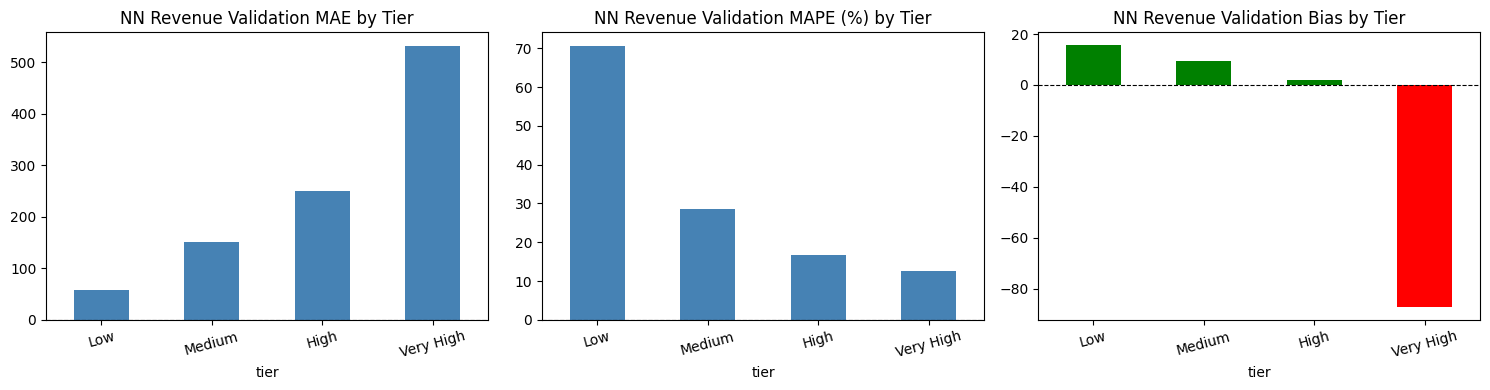

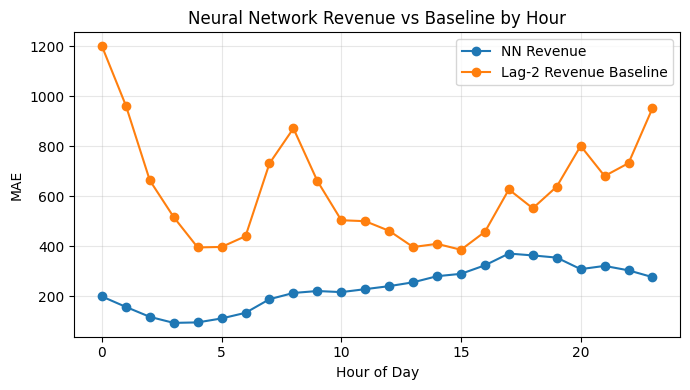

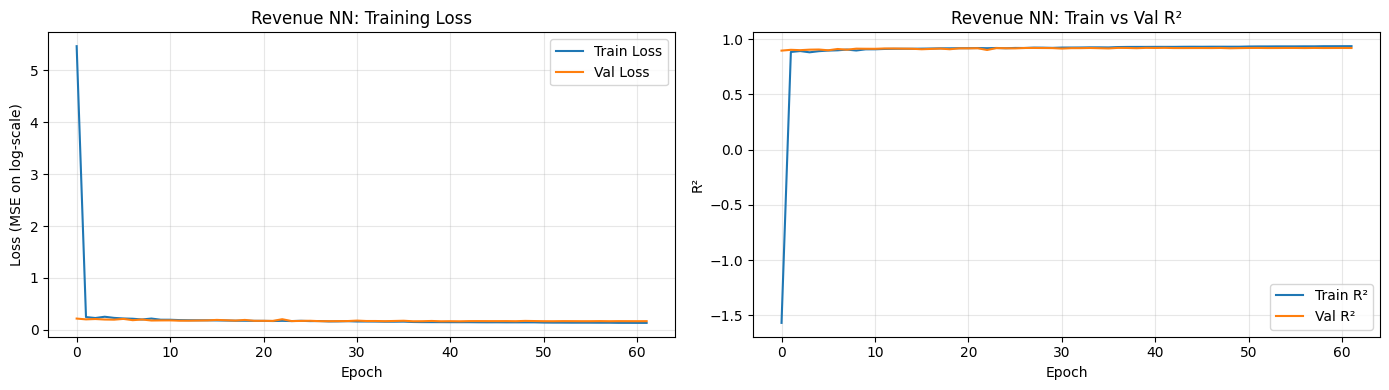

In [73]:

# Model 5 Evaluation: Neural Network Revenue


# Overall Metrics
print(f"Mean revenue (val): {y_val_nn_rev_orig.mean():.2f}")
print(f"Std revenue (val):  {np.std(y_val_nn_rev_orig):.2f}")
print(f"Relative MAE (%):   {nn_rev_metrics['val_mae'] / y_val_nn_rev_orig.mean() * 100:.2f}")

# Tier Analysis
eval_val_df = pd.DataFrame({"y_true": y_val_nn_rev_orig, "pred": val_pred_nn_rev})
bins = [
    -np.inf,
    eval_val_df["y_true"].quantile(0.25),
    eval_val_df["y_true"].quantile(0.50),
    eval_val_df["y_true"].quantile(0.75),
    np.inf,
]
labels = ["Low", "Medium", "High", "Very High"]
eval_val_df["tier"] = pd.cut(eval_val_df["y_true"], bins=bins, labels=labels)

def calculate_metrics(group):
    y, p = group["y_true"], group["pred"]
    diff = p - y
    mae = np.abs(diff).mean()
    rmse = np.sqrt((diff ** 2).mean())
    return pd.Series({
        "Count": len(y),
        "Mean Actual": y.mean(),
        "MAE": mae,
        "RMSE": rmse,
        "MAPE (%)": (np.abs(diff / y.replace(0, np.nan))).mean() * 100,
        "CV(RMSE) (%)": (rmse / y.mean() * 100) if y.mean() != 0 else np.nan,
        "Bias": diff.mean(),
    })

tier_df = eval_val_df.groupby("tier", observed=False).apply(calculate_metrics).reset_index()
print(tier_df.round(3))

if not tier_df.empty:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, m in zip(axes, ["MAE", "MAPE (%)", "Bias"]):
        colors = (["green" if v >= 0 else "red" for v in tier_df[m]]
                  if m == "Bias" else "steelblue")
        tier_df.plot.bar(x="tier", y=m, ax=ax, color=colors, legend=False, rot=15)
        ax.set_title(f"NN Revenue Validation {m} by Tier")
        ax.axhline(0, color="black", lw=0.8, ls="--")
    plt.tight_layout()
    plt.show()


# Hourly Comparison vs Lag-2 Baseline
compare_model_vs_baseline_by_hour(
    hours=val_nn_rev["hour"].values,
    actual=y_val_nn_rev_orig,
    model_pred=val_pred_nn_rev,
    baseline_pred=val_nn_rev["revenue_lag_2"].values,
    model_name="NN Revenue",
    baseline_name="Lag-2 Revenue Baseline",
    title="Neural Network Revenue vs Baseline by Hour",
)

# Training History
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(rev_nn_history["train_loss"], label="Train Loss")
axes[0].plot(rev_nn_history["val_loss"], label="Val Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss (MSE on log-scale)")
axes[0].set_title("Revenue NN: Training Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(rev_nn_history["train_r2"], label="Train R\u00b2")

axes[1].plot(rev_nn_history["val_r2"], label="Val R\u00b2")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("R\u00b2")
axes[1].set_title("Revenue NN: Train vs Val R\u00b2")
axes[1].legend()
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Model 6: Neural Network for Demand Prediction

Same architecture and training strategy as Revenue NN.  
Target: `log1p(demand)` — inverse-transformed for evaluation.  
Uses demand-specific lag features (2h, 24h, 4-week) instead of revenue lags.

In [74]:

# Model 6: Neural Network for Demand Prediction

# Continuous features (same as revenue but without revenue-specific lags)
nn_cont_features_dem = [
    "hour", "day_of_week", "month", "is_weekend", "hour_sin", "hour_cos",
    "demand_lag_2", "demand_lag_24", "demand_lag_4w", "demand_rolling_24",
]

# Data Preparation
train_nn_dem = train_ready.dropna(subset=nn_cont_features_dem + ["demand", "PULocationID"]).reset_index(drop=True)
val_nn_dem = val_ready.dropna(subset=nn_cont_features_dem + ["demand", "PULocationID"]).reset_index(drop=True)

# Location indices (reuse mapping from revenue model)
loc_train_dem = np.array([loc_to_idx[x] for x in train_nn_dem["PULocationID"].values])
loc_val_dem = np.array([loc_to_idx[x] for x in val_nn_dem["PULocationID"].values])

# Standardise continuous features
X_train_cont_dem = train_nn_dem[nn_cont_features_dem].values.astype(np.float32)
X_val_cont_dem = val_nn_dem[nn_cont_features_dem].values.astype(np.float32)

scaler_dem = StandardScaler()
X_train_cont_dem = scaler_dem.fit_transform(X_train_cont_dem).astype(np.float32)
X_val_cont_dem = scaler_dem.transform(X_val_cont_dem).astype(np.float32)

# Log-transform targets
y_train_nn_dem = np.log1p(train_nn_dem["demand"].values).astype(np.float32)
y_val_nn_dem = np.log1p(val_nn_dem["demand"].values).astype(np.float32)

# DataLoaders
train_ds_dem = TensorDataset(
    torch.from_numpy(loc_train_dem),
    torch.from_numpy(X_train_cont_dem),
    torch.from_numpy(y_train_nn_dem),
)
val_ds_dem = TensorDataset(
    torch.from_numpy(loc_val_dem),
    torch.from_numpy(X_val_cont_dem),
    torch.from_numpy(y_val_nn_dem),
)

train_loader_dem = DataLoader(train_ds_dem, batch_size=BATCH_SIZE, shuffle=True, drop_last=True, pin_memory=USE_CUDA)
val_loader_dem = DataLoader(val_ds_dem, batch_size=BATCH_SIZE * 2, shuffle=False, pin_memory=USE_CUDA)
train_loader_dem_eval = DataLoader(train_ds_dem, batch_size=BATCH_SIZE * 2, shuffle=False, pin_memory=USE_CUDA)

print(f"Train samples: {len(train_ds_dem):,}")
print(f"Val samples:   {len(val_ds_dem):,}")


# Train Demand Neural Network

nn_demand_model = TabularResNet(
    n_locations=n_locations,
    emb_dim=32,
    n_cont=len(nn_cont_features_dem),
    hidden_dims=[512, 256, 128, 64],
    dropouts=[0.3, 0.2, 0.15, 0.1],
).to(device)

print(f"Model parameters: {sum(p.numel() for p in nn_demand_model.parameters()):,}")

nn_demand_model, dem_nn_history = train_tabular_nn(
    nn_demand_model, train_loader_dem, val_loader_dem, device,
    n_epochs=200, patience=20, lr=1e-3, warmup_epochs=5,
)

# Predictions (inverse log1p transform)

train_pred_nn_dem = np.expm1(predict_tabular_nn(nn_demand_model, train_loader_dem_eval, device))
val_pred_nn_dem = np.expm1(predict_tabular_nn(nn_demand_model, val_loader_dem, device))

train_pred_nn_dem = np.maximum(train_pred_nn_dem, 0)
val_pred_nn_dem = np.maximum(val_pred_nn_dem, 0)

y_train_nn_dem_orig = train_nn_dem["demand"].values
y_val_nn_dem_orig = val_nn_dem["demand"].values

# Metrics

nn_dem_metrics = {
    "model": "Neural Network Demand Model",
    "train_rmse": np.sqrt(mean_squared_error(y_train_nn_dem_orig, train_pred_nn_dem)),
    "val_rmse": np.sqrt(mean_squared_error(y_val_nn_dem_orig, val_pred_nn_dem)),
    "train_mae": mean_absolute_error(y_train_nn_dem_orig, train_pred_nn_dem),
    "val_mae": mean_absolute_error(y_val_nn_dem_orig, val_pred_nn_dem),
    "train_r2": r2_score(y_train_nn_dem_orig, train_pred_nn_dem),
    "val_r2": r2_score(y_val_nn_dem_orig, val_pred_nn_dem),
}

display_metrics(nn_dem_metrics)

Train samples: 237,828
Val samples:   23,267
Model parameters: 744,117
Epoch  10/200 | Train: 0.090069 | Val: 0.095479 | LR: 1.00e-03 | Pat: 2/20
Epoch  20/200 | Train: 0.079114 | Val: 0.089440 | LR: 1.00e-03 | Pat: 4/20
Epoch  30/200 | Train: 0.071813 | Val: 0.088301 | LR: 5.00e-04 | Pat: 5/20
Epoch  40/200 | Train: 0.067661 | Val: 0.088258 | LR: 2.50e-04 | Pat: 15/20
Early stopping at epoch 45
Model: Neural Network Demand Model
Train RMSE: 15.722
val RMSE:  17.281
Train MAE:  8.955
val MAE:   9.596
Train R²:   0.965
val R²:    0.953


### Model 6 Evaluation: NN Demand

Mean demand (val): 68.87
Std demand (val):  80.10
Relative MAE (%):  13.93
        tier   Count  Mean Actual     MAE    RMSE  MAPE (%)  CV(RMSE) (%)  \
0        Low  6159.0        5.302   2.201   3.429    54.982        64.676   
1     Medium  5526.0       23.590   5.692   9.074    25.172        38.466   
2       High  5821.0       66.698  10.111  13.949    15.664        20.913   
3  Very High  5761.0      182.460  20.727  30.298    11.524        16.605   

    Bias  
0  0.706  
1  1.218  
2  1.589  
3 -1.277  


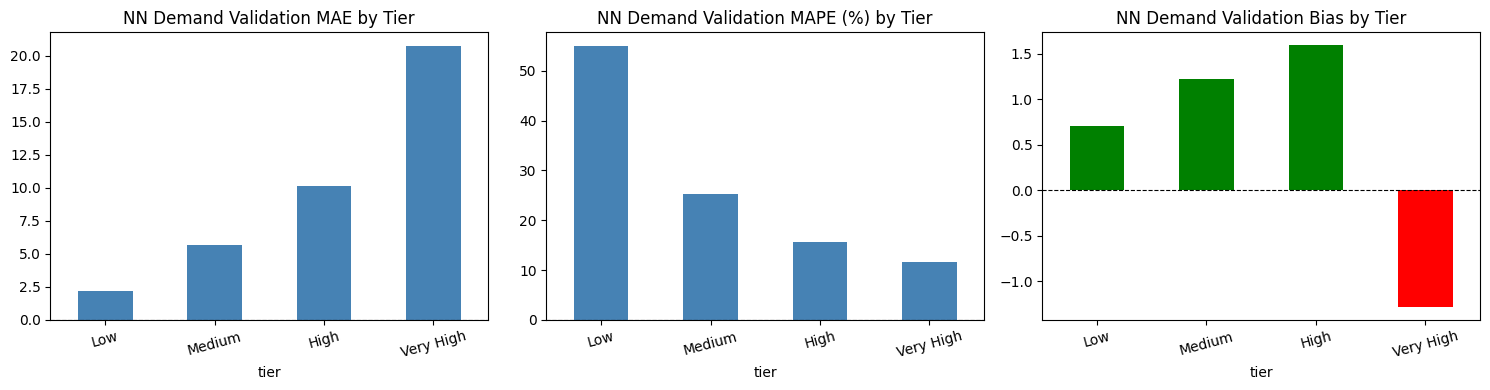

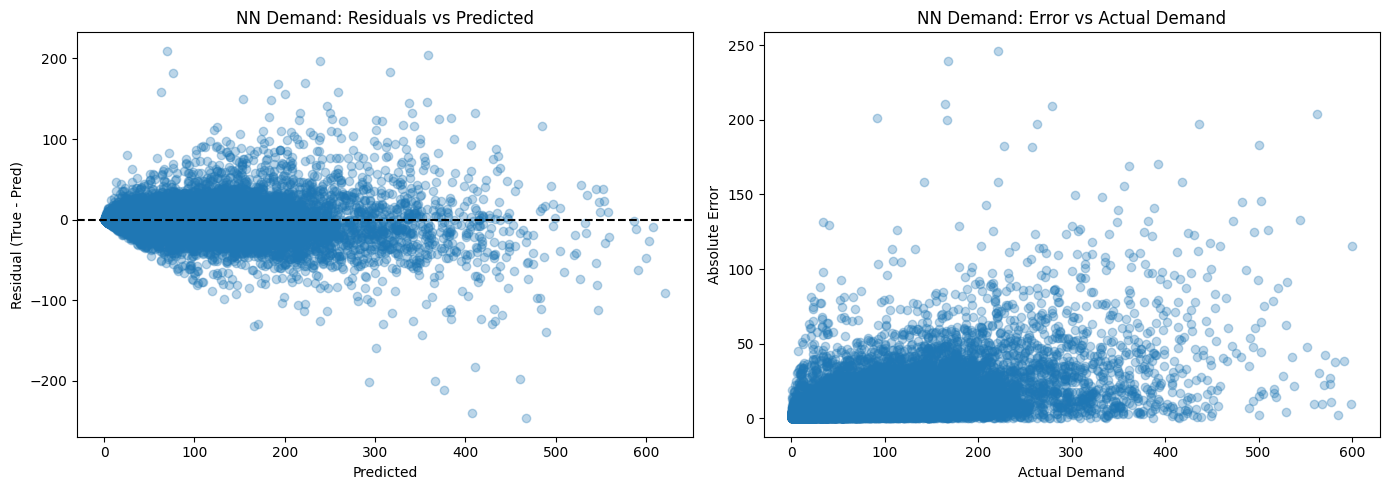

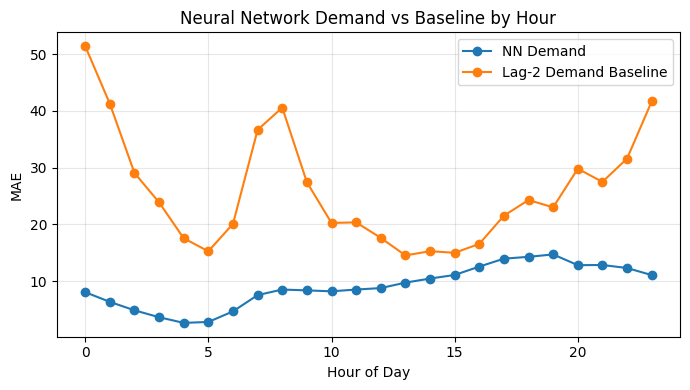

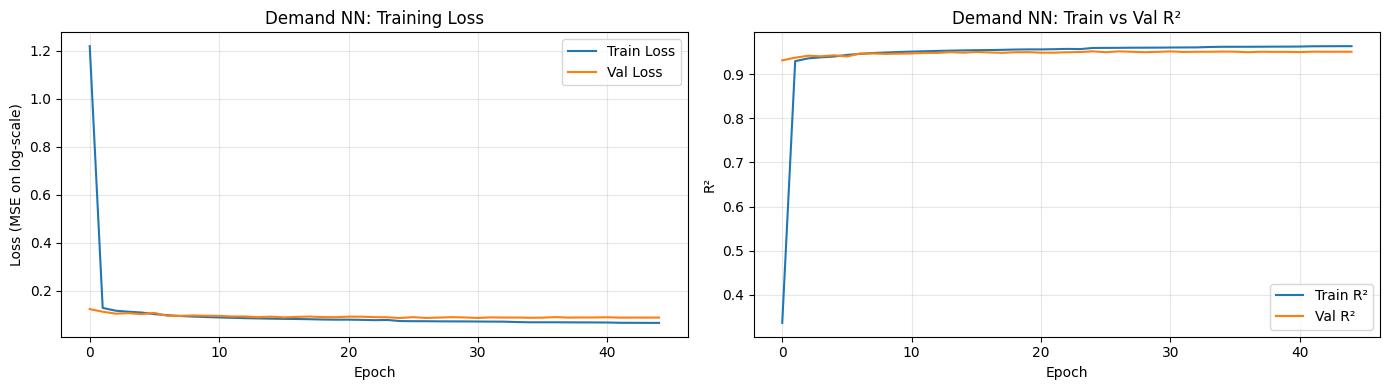

In [76]:

# Model 6 Evaluation: Neural Network Demand

# --- Overall Metrics ---
print(f"Mean demand (val): {y_val_nn_dem_orig.mean():.2f}")
print(f"Std demand (val):  {np.std(y_val_nn_dem_orig):.2f}")
print(f"Relative MAE (%):  {nn_dem_metrics['val_mae'] / y_val_nn_dem_orig.mean() * 100:.2f}")

# Tier Analysis
eval_val_df = pd.DataFrame({"y_true": y_val_nn_dem_orig, "pred": val_pred_nn_dem})
bins = [
    -np.inf,
    eval_val_df["y_true"].quantile(0.25),
    eval_val_df["y_true"].quantile(0.50),
    eval_val_df["y_true"].quantile(0.75),
    np.inf,
]
labels = ["Low", "Medium", "High", "Very High"]
eval_val_df["tier"] = pd.cut(eval_val_df["y_true"], bins=bins, labels=labels, include_lowest=True)

def calculate_metrics(group):
    y, p = group["y_true"], group["pred"]
    diff = p - y
    mae = np.abs(diff).mean()
    rmse = np.sqrt((diff ** 2).mean())
    return pd.Series({
        "Count": len(y),
        "Mean Actual": y.mean(),
        "MAE": mae,
        "RMSE": rmse,
        "MAPE (%)": (np.abs(diff / y.replace(0, np.nan))).mean() * 100,
        "CV(RMSE) (%)": (rmse / y.mean() * 100) if y.mean() != 0 else np.nan,
        "Bias": diff.mean(),
    })

tier_df = eval_val_df.groupby("tier", observed=False).apply(calculate_metrics).reset_index()
print(tier_df.round(3))

if not tier_df.empty:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, m in zip(axes, ["MAE", "MAPE (%)", "Bias"]):
        colors = (["green" if v >= 0 else "red" for v in tier_df[m]]
                  if m == "Bias" else "steelblue")
        tier_df.plot.bar(x="tier", y=m, ax=ax, color=colors, legend=False, rot=15)
        ax.set_title(f"NN Demand Validation {m} by Tier")
        ax.axhline(0, color="black", lw=0.8, ls="--")
    plt.tight_layout()
    plt.show()

# Residual Plots
eval_val_df["residual"] = eval_val_df["y_true"] - eval_val_df["pred"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(eval_val_df["pred"], eval_val_df["residual"], alpha=0.3)
axes[0].axhline(0, color="black", linestyle="--")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Residual (True - Pred)")
axes[0].set_title("NN Demand: Residuals vs Predicted")

axes[1].scatter(eval_val_df["y_true"], np.abs(eval_val_df["residual"]), alpha=0.3)
axes[1].set_xlabel("Actual Demand")
axes[1].set_ylabel("Absolute Error")
axes[1].set_title("NN Demand: Error vs Actual Demand")

plt.tight_layout()
plt.show()

# Hourly Comparison vs Lag-2 Baseline
compare_model_vs_baseline_by_hour(
    hours=val_nn_dem["hour"].values,
    actual=y_val_nn_dem_orig,
    model_pred=val_pred_nn_dem,
    baseline_pred=val_nn_dem["demand_lag_2"].values,
    model_name="NN Demand",
    baseline_name="Lag-2 Demand Baseline",
    title="Neural Network Demand vs Baseline by Hour",
)

# Training History
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(dem_nn_history["train_loss"], label="Train Loss")
axes[0].plot(dem_nn_history["val_loss"], label="Val Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss (MSE on log-scale)")
axes[0].set_title("Demand NN: Training Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(dem_nn_history["train_r2"], label="Train R\u00b2")

axes[1].plot(dem_nn_history["val_r2"], label="Val R\u00b2")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("R\u00b2")
axes[1].set_title("Demand NN: Train vs Val R\u00b2")
axes[1].legend()
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Feature Importance for Neural Network Models

Unlike tree-based models (XGBoost, Random Forest) which have builtin feature importances, neural networks require **permutation importance**: for each feature, we shuffle its values across the validation set and measure how much the prediction error (RMSE) increases. A larger ΔRMSE means the model relies more heavily on that feature.

In [77]:

# Permutation Importance Helper Functions


def batch_predict_tabular(model, loc_ids, x_cont, device, batch_size=4096):
    """Run TabularResNet inference in batches from numpy arrays."""
    model.eval()
    preds = []
    n = len(loc_ids)
    with torch.no_grad():
        for i in range(0, n, batch_size):
            loc_t = torch.tensor(loc_ids[i:i+batch_size], dtype=torch.long, device=device)
            cont_t = torch.tensor(x_cont[i:i+batch_size], dtype=torch.float32, device=device)
            preds.append(model(loc_t, cont_t).cpu().numpy())
    return np.concatenate(preds)


def batch_predict_seq(model, seq, loc, cal, device, batch_size=2048):
    """Run GRU / TCN inference in batches from numpy arrays."""
    model.eval()
    preds = []
    n = len(seq)
    with torch.no_grad():
        for i in range(0, n, batch_size):
            s = torch.tensor(seq[i:i+batch_size], dtype=torch.float32, device=device)
            l = torch.tensor(loc[i:i+batch_size], dtype=torch.long, device=device)
            c = torch.tensor(cal[i:i+batch_size], dtype=torch.float32, device=device)
            preds.append(model(s, l, c).cpu().numpy())
    return np.concatenate(preds)


def permutation_importance_tabular(model, loc_ids, x_cont, y_true,
                                   feature_names, device, n_repeats=5):
    """Permutation importance for TabularResNet (continuous features + location)."""
    baseline_pred = batch_predict_tabular(model, loc_ids, x_cont, device)
    baseline_rmse = np.sqrt(mean_squared_error(y_true, baseline_pred))

    importances = {}
    all_features = ["PULocationID"] + list(feature_names)

    for i, feat in enumerate(all_features):
        deltas = []
        for _ in range(n_repeats):
            if feat == "PULocationID":
                perm_loc = np.random.permutation(loc_ids)
                pred = batch_predict_tabular(model, perm_loc, x_cont, device)
            else:
                x_perm = x_cont.copy()
                x_perm[:, i - 1] = np.random.permutation(x_perm[:, i - 1])
                pred = batch_predict_tabular(model, loc_ids, x_perm, device)
            deltas.append(np.sqrt(mean_squared_error(y_true, pred)) - baseline_rmse)
        importances[feat] = np.mean(deltas)

    return importances, baseline_rmse


def permutation_importance_seq(model, seq, loc, cal, y_true,
                               seq_feat_names, cal_feat_names, device,
                               n_repeats=5):
    """Permutation importance for GRU / TCN (seq channels + calendar + location)."""
    baseline_pred = batch_predict_seq(model, seq, loc, cal, device)
    baseline_rmse = np.sqrt(mean_squared_error(y_true, baseline_pred))

    importances = {}

    # Sequence channels shuffle each channel across samples
    for ch, feat in enumerate(seq_feat_names):
        deltas = []
        for _ in range(n_repeats):
            seq_perm = seq.copy()
            idx = np.random.permutation(len(seq))
            seq_perm[:, :, ch] = seq_perm[idx, :, ch]
            pred = batch_predict_seq(model, seq_perm, loc, cal, device)
            deltas.append(np.sqrt(mean_squared_error(y_true, pred)) - baseline_rmse)
        importances[feat] = np.mean(deltas)

    # Calendar features
    for col, feat in enumerate(cal_feat_names):
        deltas = []
        for _ in range(n_repeats):
            cal_perm = cal.copy()
            cal_perm[:, col] = np.random.permutation(cal_perm[:, col])
            pred = batch_predict_seq(model, seq, loc, cal_perm, device)
            deltas.append(np.sqrt(mean_squared_error(y_true, pred)) - baseline_rmse)
        importances[feat] = np.mean(deltas)

    # Location embedding
    deltas = []
    for _ in range(n_repeats):
        loc_perm = np.random.permutation(loc)
        pred = batch_predict_seq(model, seq, loc_perm, cal, device)
        deltas.append(np.sqrt(mean_squared_error(y_true, pred)) - baseline_rmse)
    importances["PULocationID"] = np.mean(deltas)

    return importances, baseline_rmse


print("Permutation-importance helpers ready.")

Permutation-importance helpers ready.


### TabularResNet Feature Importance

Computing TabularResNet Revenue permutation importance …
Computing TabularResNet Demand permutation importance …


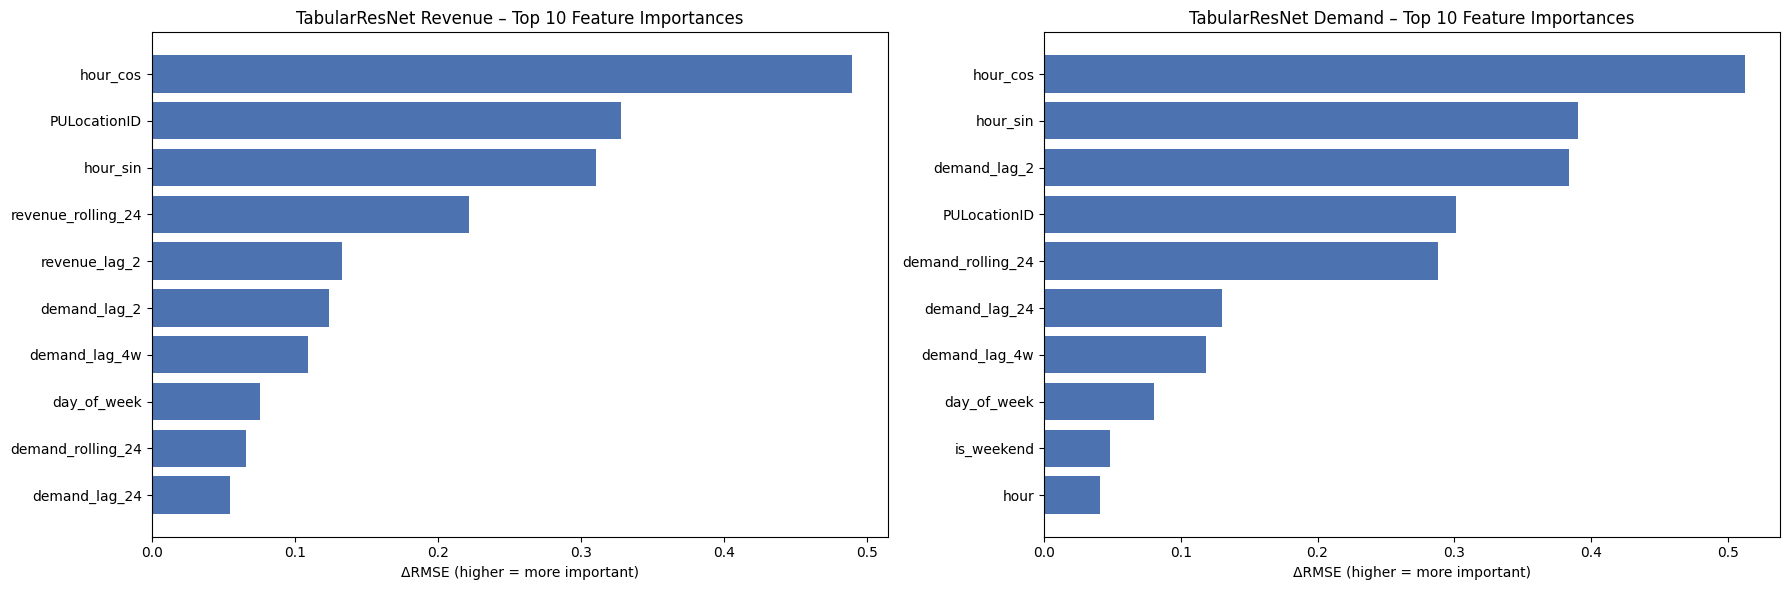


Baseline RMSE — Revenue: 0.403232  |  Demand: 0.293434

TabularResNet Revenue top 10 features:
hour_cos              0.489568
PULocationID          0.327986
hour_sin              0.310229
revenue_rolling_24    0.221970
revenue_lag_2         0.133157
demand_lag_2          0.123946
demand_lag_4w         0.109505
day_of_week           0.076025
demand_rolling_24     0.066103
demand_lag_24         0.054878
dtype: float64

TabularResNet Demand top 10 features:
hour_cos             0.512689
hour_sin             0.390390
demand_lag_2         0.383853
PULocationID         0.301426
demand_rolling_24    0.288503
demand_lag_24        0.130500
demand_lag_4w        0.118658
day_of_week          0.080576
is_weekend           0.047909
hour                 0.040611
dtype: float64


In [78]:

# TabularResNet Feature Importance
np.random.seed(42)

# Revenue
print("Computing TabularResNet Revenue permutation importance …")
nn_rev_imp, nn_rev_base = permutation_importance_tabular(
    nn_revenue_model, loc_val_rev, X_val_cont_rev, y_val_nn_rev,
    nn_cont_features_rev, device, n_repeats=5
)

# Demand
print("Computing TabularResNet Demand permutation importance …")
nn_dem_imp, nn_dem_base = permutation_importance_tabular(
    nn_demand_model, loc_val_dem, X_val_cont_dem, y_val_nn_dem,
    nn_cont_features_dem, device, n_repeats=5
)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

imp_rev = pd.Series(nn_rev_imp).sort_values(ascending=False).head(10)
axes[0].barh(imp_rev.index[::-1], imp_rev.values[::-1], color="#4C72B0")
axes[0].set_title("TabularResNet Revenue – Top 10 Feature Importances")
axes[0].set_xlabel("ΔRMSE (higher = more important)")

imp_dem = pd.Series(nn_dem_imp).sort_values(ascending=False).head(10)
axes[1].barh(imp_dem.index[::-1], imp_dem.values[::-1], color="#4C72B0")
axes[1].set_title("TabularResNet Demand – Top 10 Feature Importances")
axes[1].set_xlabel("ΔRMSE (higher = more important)")

plt.tight_layout()
plt.show()

print(f"\nBaseline RMSE — Revenue: {nn_rev_base:.6f}  |  Demand: {nn_dem_base:.6f}")
print("\nTabularResNet Revenue top 10 features:")
print(imp_rev.round(6))
print("\nTabularResNet Demand top 10 features:")
print(imp_dem.round(6))

In [95]:

# DEMAND RESULTS

demand_results = [
    demand_metrics,         # XGBoost Demand
    rf_demand_metrics,      # Random Forest Demand
    nn_dem_metrics,         # TabularResNet Demand
]

df_demand = pd.DataFrame(demand_results)

print("DEMAND MODEL COMPARISON ")
display(df_demand.sort_values("val_rmse"))



# REVENUE RESULTS

revenue_results = [
    revenue_metrics,        # XGBoost Revenue
    rf_revenue_metrics,     # Random Forest Revenue
    nn_rev_metrics,         # TabularResNet Revenue
]

df_revenue = pd.DataFrame(revenue_results)

print("REVENUE MODEL COMPARISON")
display(df_revenue.sort_values("val_rmse"))


DEMAND MODEL COMPARISON 


,model,train_rmse,val_rmse,train_mae,val_mae,train_r2,val_r2
2,Neural Network Demand Model,15.721803,17.281270,8.954934,9.595964,0.965297,0.953450
0,XGBoost Demand Model,16.707435,20.032812,9.716976,11.056591,0.958414,0.933804
1,Random Forest Demand Model,24.169550,29.803732,13.761295,15.701870,0.912972,0.853482


REVENUE MODEL COMPARISON


,model,train_rmse,val_rmse,train_mae,val_mae,train_r2,val_r2
2,Neural Network Revenue Model,401.823519,428.314684,236.187698,247.828506,0.960215,0.949024
0,XGBoost Revenue Model,426.583795,486.534846,253.598114,277.638733,0.951907,0.928594
1,Random Forest Revenue Model,604.175919,705.484264,355.308389,387.506563,0.903528,0.849866


### FineTuning :  Neural Network 

TabularResNet architecture was selected for further fine tuning due to its superior performance across both demand and revenue prediction tasks. Compared to XGBoost and Random Forest the TabularResNet consistently achieved the lowest validation error and highest R², indicating a strong ability to capture complex nonlinear relationships in the data.

The primary advantage of the TabularResNet in this context lies in its ability to effectively utilise rich, engineered tabular features, including lag variables, rolling statistics, and temporal encodings.

Finetuning was performed by making targeted adjustments to key hyperparameters, including reducing dropout to improve information retention, lowering the learning rate for smoother convergence, and replacing the mean squared error loss with Huber loss to improve robustness to outliers in revenue and demand. These modifications led to consistent improvements across all evaluation metrics, with validation RMSE decreasing for both revenue and demand.

In [79]:

# Fine Tuned TabularResNet Trainer

import copy
import torch
import torch.nn as nn
import numpy as np
from sklearn.metrics import r2_score

def train_tabular_nn_tuned(
    model,
    train_loader,
    val_loader,
    device,
    n_epochs=220,
    patience=25,
    lr=7e-4,
    warmup_epochs=5,
    weight_decay=1e-4,
    use_huber=True,
):
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=7, min_lr=1e-6
    )
    criterion = nn.HuberLoss(delta=1.0) if use_huber else nn.MSELoss()

    best_val_loss = float("inf")
    patience_counter = 0
    best_state = copy.deepcopy(model.state_dict())

    history = {"train_loss": [], "val_loss": [], "train_r2": [], "val_r2": []}

    for epoch in range(n_epochs):
        if epoch < warmup_epochs:
            for pg in optimizer.param_groups:
                pg["lr"] = lr * (epoch + 1) / warmup_epochs

        model.train()
        train_loss_sum, n_train = 0.0, 0
        train_preds, train_tgts = [], []

        for loc, cont, target in train_loader:
            loc = loc.to(device)
            cont = cont.to(device)
            target = target.to(device)

            optimizer.zero_grad()
            pred = model(loc, cont)
            loss = criterion(pred, target)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            train_loss_sum += loss.item() * len(target)
            n_train += len(target)
            train_preds.append(pred.detach().cpu().numpy())
            train_tgts.append(target.detach().cpu().numpy())

        train_loss = train_loss_sum / n_train
        train_preds = np.concatenate(train_preds)
        train_tgts = np.concatenate(train_tgts)
        train_r2 = r2_score(train_tgts, train_preds)

        model.eval()
        val_loss_sum, n_val = 0.0, 0
        val_preds, val_tgts = [], []

        with torch.no_grad():
            for loc, cont, target in val_loader:
                loc = loc.to(device)
                cont = cont.to(device)
                target = target.to(device)

                pred = model(loc, cont)
                loss = criterion(pred, target)

                val_loss_sum += loss.item() * len(target)
                n_val += len(target)
                val_preds.append(pred.cpu().numpy())
                val_tgts.append(target.cpu().numpy())

        val_loss = val_loss_sum / n_val
        val_preds = np.concatenate(val_preds)
        val_tgts = np.concatenate(val_tgts)
        val_r2 = r2_score(val_tgts, val_preds)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_r2"].append(train_r2)
        history["val_r2"].append(val_r2)

        scheduler.step(val_loss)

        if val_loss < best_val_loss - 1e-5:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1

        if (epoch + 1) % 10 == 0:
            print(
                f"Epoch {epoch+1:>3}/{n_epochs} | "
                f"Train: {train_loss:.6f} | Val: {val_loss:.6f} | "
                f"LR: {optimizer.param_groups[0]['lr']:.2e} | "
                f"Pat: {patience_counter}/{patience}"
            )

        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

    model.load_state_dict(best_state)
    return model, history

In [80]:

# FineTuned TabularResNet Revenue

nn_cont_features_rev = [
    "hour", "day_of_week", "month", "is_weekend", "hour_sin", "hour_cos",
    "demand_lag_2", "demand_lag_24", "demand_lag_4w", "demand_rolling_24",
    "revenue_lag_2", "revenue_lag_24", "revenue_rolling_24",
]

train_nn_rev_ft = train_ready.dropna(subset=nn_cont_features_rev + ["total_revenue", "PULocationID"]).reset_index(drop=True)
val_nn_rev_ft   = val_ready.dropna(subset=nn_cont_features_rev + ["total_revenue", "PULocationID"]).reset_index(drop=True)

loc_train_rev_ft = np.array([loc_to_idx[x] for x in train_nn_rev_ft["PULocationID"].values])
loc_val_rev_ft   = np.array([loc_to_idx[x] for x in val_nn_rev_ft["PULocationID"].values])

X_train_cont_rev_ft = train_nn_rev_ft[nn_cont_features_rev].values.astype(np.float32)
X_val_cont_rev_ft   = val_nn_rev_ft[nn_cont_features_rev].values.astype(np.float32)

scaler_rev_ft = StandardScaler()
X_train_cont_rev_ft = scaler_rev_ft.fit_transform(X_train_cont_rev_ft).astype(np.float32)
X_val_cont_rev_ft   = scaler_rev_ft.transform(X_val_cont_rev_ft).astype(np.float32)

y_train_rev_ft = np.log1p(train_nn_rev_ft["total_revenue"].values).astype(np.float32)
y_val_rev_ft   = np.log1p(val_nn_rev_ft["total_revenue"].values).astype(np.float32)

train_ds_rev_ft = TensorDataset(
    torch.from_numpy(loc_train_rev_ft),
    torch.from_numpy(X_train_cont_rev_ft),
    torch.from_numpy(y_train_rev_ft),
)
val_ds_rev_ft = TensorDataset(
    torch.from_numpy(loc_val_rev_ft),
    torch.from_numpy(X_val_cont_rev_ft),
    torch.from_numpy(y_val_rev_ft),
)

FT_BATCH_SIZE = 1024 if USE_CUDA else 512

train_loader_rev_ft = DataLoader(train_ds_rev_ft, batch_size=FT_BATCH_SIZE, shuffle=True, drop_last=True, pin_memory=USE_CUDA)
val_loader_rev_ft   = DataLoader(val_ds_rev_ft, batch_size=FT_BATCH_SIZE * 2, shuffle=False, pin_memory=USE_CUDA)

ft_nn_revenue_model = TabularResNet(
    n_locations=n_locations,
    emb_dim=32,
    n_cont=len(nn_cont_features_rev),
    hidden_dims=[512, 256, 128, 64],
    dropouts=[0.25, 0.15, 0.10, 0.05],
).to(device)

print(f"Fine-tuned Revenue TabularResNet params: {sum(p.numel() for p in ft_nn_revenue_model.parameters()):,}")

ft_nn_revenue_model, ft_rev_history = train_tabular_nn_tuned(
    ft_nn_revenue_model,
    train_loader_rev_ft,
    val_loader_rev_ft,
    device,
    n_epochs=220,
    patience=25,
    lr=7e-4,
    warmup_epochs=5,
    weight_decay=1e-4,
    use_huber=True,
)

# Validation predictions only
val_pred_rev_ft = np.expm1(predict_tabular_nn(ft_nn_revenue_model, val_loader_rev_ft, device))
val_pred_rev_ft = np.maximum(val_pred_rev_ft, 0)
y_val_rev_orig = val_nn_rev_ft["total_revenue"].values

ft_rev_metrics = {
    "model": "Fine-Tuned TabularResNet Revenue",
    "val_rmse": np.sqrt(mean_squared_error(y_val_rev_orig, val_pred_rev_ft)),
    "val_mae": mean_absolute_error(y_val_rev_orig, val_pred_rev_ft),
    "val_r2": r2_score(y_val_rev_orig, val_pred_rev_ft),
}

train_loader_rev_ft_eval = DataLoader(
    train_ds_rev_ft,
    batch_size=FT_BATCH_SIZE * 2,
    shuffle=False,
    pin_memory=USE_CUDA
)

train_pred_rev_ft = np.expm1(predict_tabular_nn(ft_nn_revenue_model, train_loader_rev_ft_eval, device))
val_pred_rev_ft   = np.expm1(predict_tabular_nn(ft_nn_revenue_model, val_loader_rev_ft, device))

train_pred_rev_ft = np.maximum(train_pred_rev_ft, 0)
val_pred_rev_ft   = np.maximum(val_pred_rev_ft, 0)

y_train_rev_orig = train_nn_rev_ft["total_revenue"].values
y_val_rev_orig   = val_nn_rev_ft["total_revenue"].values

ft_rev_metrics = {
    "model": "Fine-Tuned TabularResNet Revenue",
    "train_rmse": np.sqrt(mean_squared_error(y_train_rev_orig, train_pred_rev_ft)),
    "val_rmse": np.sqrt(mean_squared_error(y_val_rev_orig, val_pred_rev_ft)),
    "train_mae": mean_absolute_error(y_train_rev_orig, train_pred_rev_ft),
    "val_mae": mean_absolute_error(y_val_rev_orig, val_pred_rev_ft),
    "train_r2": r2_score(y_train_rev_orig, train_pred_rev_ft),
    "val_r2": r2_score(y_val_rev_orig, val_pred_rev_ft),
}

display_metrics(ft_rev_metrics)

Fine-tuned Revenue TabularResNet params: 747,195
Epoch  10/220 | Train: 0.086015 | Val: 0.082268 | LR: 7.00e-04 | Pat: 1/25
Epoch  20/220 | Train: 0.079401 | Val: 0.079995 | LR: 7.00e-04 | Pat: 4/25
Epoch  30/220 | Train: 0.075628 | Val: 0.078715 | LR: 7.00e-04 | Pat: 1/25
Epoch  40/220 | Train: 0.069590 | Val: 0.077601 | LR: 3.50e-04 | Pat: 1/25
Epoch  50/220 | Train: 0.066498 | Val: 0.077457 | LR: 1.75e-04 | Pat: 11/25
Epoch  60/220 | Train: 0.064651 | Val: 0.077806 | LR: 8.75e-05 | Pat: 21/25
Early stopping at epoch 64
Model: Fine-Tuned TabularResNet Revenue
Train RMSE: 400.203
val RMSE:  424.055
Train MAE:  235.234
val MAE:   245.788
Train R²:   0.961
val R²:    0.950


In [81]:

# FineTuned TabularResNet Demand

nn_cont_features_dem = [
    "hour", "day_of_week", "month", "is_weekend", "hour_sin", "hour_cos",
    "demand_lag_2", "demand_lag_24", "demand_lag_4w", "demand_rolling_24",
]

train_nn_dem_ft = train_ready.dropna(subset=nn_cont_features_dem + ["demand", "PULocationID"]).reset_index(drop=True)
val_nn_dem_ft   = val_ready.dropna(subset=nn_cont_features_dem + ["demand", "PULocationID"]).reset_index(drop=True)

loc_train_dem_ft = np.array([loc_to_idx[x] for x in train_nn_dem_ft["PULocationID"].values])
loc_val_dem_ft   = np.array([loc_to_idx[x] for x in val_nn_dem_ft["PULocationID"].values])

X_train_cont_dem_ft = train_nn_dem_ft[nn_cont_features_dem].values.astype(np.float32)
X_val_cont_dem_ft   = val_nn_dem_ft[nn_cont_features_dem].values.astype(np.float32)

scaler_dem_ft = StandardScaler()
X_train_cont_dem_ft = scaler_dem_ft.fit_transform(X_train_cont_dem_ft).astype(np.float32)
X_val_cont_dem_ft   = scaler_dem_ft.transform(X_val_cont_dem_ft).astype(np.float32)

y_train_dem_ft = np.log1p(train_nn_dem_ft["demand"].values).astype(np.float32)
y_val_dem_ft   = np.log1p(val_nn_dem_ft["demand"].values).astype(np.float32)

train_ds_dem_ft = TensorDataset(
    torch.from_numpy(loc_train_dem_ft),
    torch.from_numpy(X_train_cont_dem_ft),
    torch.from_numpy(y_train_dem_ft),
)
val_ds_dem_ft = TensorDataset(
    torch.from_numpy(loc_val_dem_ft),
    torch.from_numpy(X_val_cont_dem_ft),
    torch.from_numpy(y_val_dem_ft),
)

train_loader_dem_ft = DataLoader(train_ds_dem_ft, batch_size=FT_BATCH_SIZE, shuffle=True, drop_last=True, pin_memory=USE_CUDA)
val_loader_dem_ft   = DataLoader(val_ds_dem_ft, batch_size=FT_BATCH_SIZE * 2, shuffle=False, pin_memory=USE_CUDA)

ft_nn_demand_model = TabularResNet(
    n_locations=n_locations,
    emb_dim=32,
    n_cont=len(nn_cont_features_dem),
    hidden_dims=[512, 256, 128, 64],
    dropouts=[0.25, 0.15, 0.10, 0.05],
).to(device)

print(f"Fine-tuned Demand TabularResNet params: {sum(p.numel() for p in ft_nn_demand_model.parameters()):,}")

ft_nn_demand_model, ft_dem_history = train_tabular_nn_tuned(
    ft_nn_demand_model,
    train_loader_dem_ft,
    val_loader_dem_ft,
    device,
    n_epochs=220,
    patience=25,
    lr=7e-4,
    warmup_epochs=5,
    weight_decay=1e-4,
    use_huber=True,
)

# Validation predictions only
val_pred_dem_ft = np.expm1(predict_tabular_nn(ft_nn_demand_model, val_loader_dem_ft, device))
val_pred_dem_ft = np.maximum(val_pred_dem_ft, 0)
y_val_dem_orig = val_nn_dem_ft["demand"].values

ft_dem_metrics = {
    "model": "Fine-Tuned TabularResNet Demand",
    "val_rmse": np.sqrt(mean_squared_error(y_val_dem_orig, val_pred_dem_ft)),
    "val_mae": mean_absolute_error(y_val_dem_orig, val_pred_dem_ft),
    "val_r2": r2_score(y_val_dem_orig, val_pred_dem_ft),
}

# Add train predictions
train_loader_dem_ft_eval = DataLoader(
    train_ds_dem_ft,
    batch_size=FT_BATCH_SIZE * 2,
    shuffle=False,
    pin_memory=USE_CUDA
)

train_pred_dem_ft = np.expm1(
    predict_tabular_nn(ft_nn_demand_model, train_loader_dem_ft_eval, device)
)
val_pred_dem_ft = np.expm1(
    predict_tabular_nn(ft_nn_demand_model, val_loader_dem_ft, device)
)

train_pred_dem_ft = np.maximum(train_pred_dem_ft, 0)
val_pred_dem_ft   = np.maximum(val_pred_dem_ft, 0)

y_train_dem_orig = train_nn_dem_ft["demand"].values
y_val_dem_orig   = val_nn_dem_ft["demand"].values

# Full metrics
ft_dem_metrics = {
    "model": "Fine-Tuned TabularResNet Demand",
    "train_rmse": np.sqrt(mean_squared_error(y_train_dem_orig, train_pred_dem_ft)),
    "val_rmse": np.sqrt(mean_squared_error(y_val_dem_orig, val_pred_dem_ft)),
    "train_mae": mean_absolute_error(y_train_dem_orig, train_pred_dem_ft),
    "val_mae": mean_absolute_error(y_val_dem_orig, val_pred_dem_ft),
    "train_r2": r2_score(y_train_dem_orig, train_pred_dem_ft),
    "val_r2": r2_score(y_val_dem_orig, val_pred_dem_ft),
}

display_metrics(ft_dem_metrics)

Fine-tuned Demand TabularResNet params: 744,117
Epoch  10/220 | Train: 0.044332 | Val: 0.047305 | LR: 7.00e-04 | Pat: 1/25
Epoch  20/220 | Train: 0.039939 | Val: 0.045033 | LR: 7.00e-04 | Pat: 4/25
Epoch  30/220 | Train: 0.036703 | Val: 0.043433 | LR: 3.50e-04 | Pat: 5/25
Epoch  40/220 | Train: 0.034920 | Val: 0.043621 | LR: 1.75e-04 | Pat: 15/25
Epoch  50/220 | Train: 0.033761 | Val: 0.042980 | LR: 8.75e-05 | Pat: 6/25
Epoch  60/220 | Train: 0.033109 | Val: 0.043003 | LR: 2.19e-05 | Pat: 16/25
Early stopping at epoch 69
Model: Fine-Tuned TabularResNet Demand
Train RMSE: 14.751
val RMSE:  17.077
Train MAE:  8.498
val MAE:   9.490
Train R²:   0.969
val R²:    0.955


In [82]:
comparison_tabresnet = pd.DataFrame([
    {
        "Target": "Revenue",
        "Model": "Original TabularResNet",
        "Val RMSE": nn_rev_metrics["val_rmse"],
        "Val MAE": nn_rev_metrics["val_mae"],
        "Val R2": nn_rev_metrics["val_r2"],
    },
    {
        "Target": "Revenue",
        "Model": "Fine-Tuned TabularResNet",
        "Val RMSE": ft_rev_metrics["val_rmse"],
        "Val MAE": ft_rev_metrics["val_mae"],
        "Val R2": ft_rev_metrics["val_r2"],
    },
    {
        "Target": "Demand",
        "Model": "Original TabularResNet",
        "Val RMSE": nn_dem_metrics["val_rmse"],
        "Val MAE": nn_dem_metrics["val_mae"],
        "Val R2": nn_dem_metrics["val_r2"],
    },
    {
        "Target": "Demand",
        "Model": "Fine-Tuned TabularResNet",
        "Val RMSE": ft_dem_metrics["val_rmse"],
        "Val MAE": ft_dem_metrics["val_mae"],
        "Val R2": ft_dem_metrics["val_r2"],
    },
])

comparison_tabresnet

,Target,Model,Val RMSE,Val MAE,Val R2
0,Revenue,Original TabularResNet,428.314684,247.828506,0.949024
1,Revenue,Fine-Tuned TabularResNet,424.055347,245.787827,0.950033
2,Demand,Original TabularResNet,17.281270,9.595964,0.953450
3,Demand,Fine-Tuned TabularResNet,17.077213,9.490027,0.954543


In [83]:

# FineTuned TabularResNet Revenue Test Evaluation

test_nn_rev_ft = test_ready.dropna(
    subset=nn_cont_features_rev + ["total_revenue", "PULocationID"]
).reset_index(drop=True)

loc_test_rev_ft = np.array([loc_to_idx[x] for x in test_nn_rev_ft["PULocationID"].values])

X_test_cont_rev_ft = test_nn_rev_ft[nn_cont_features_rev].values.astype(np.float32)
X_test_cont_rev_ft = scaler_rev_ft.transform(X_test_cont_rev_ft).astype(np.float32)

y_test_rev_ft = np.log1p(test_nn_rev_ft["total_revenue"].values).astype(np.float32)

test_ds_rev_ft = TensorDataset(
    torch.from_numpy(loc_test_rev_ft),
    torch.from_numpy(X_test_cont_rev_ft),
    torch.from_numpy(y_test_rev_ft),
)

test_loader_rev_ft = DataLoader(
    test_ds_rev_ft,
    batch_size=FT_BATCH_SIZE * 2,
    shuffle=False,
    pin_memory=USE_CUDA
)

test_pred_rev_ft = np.expm1(
    predict_tabular_nn(ft_nn_revenue_model, test_loader_rev_ft, device)
)
test_pred_rev_ft = np.maximum(test_pred_rev_ft, 0)

y_test_rev_orig = test_nn_rev_ft["total_revenue"].values

ft_rev_test_metrics = {
    "model": "Fine-Tuned TabularResNet Revenue",
    "test_rmse": np.sqrt(mean_squared_error(y_test_rev_orig, test_pred_rev_ft)),
    "test_mae": mean_absolute_error(y_test_rev_orig, test_pred_rev_ft),
    "test_r2": r2_score(y_test_rev_orig, test_pred_rev_ft),
}

print("Model:", ft_rev_test_metrics["model"])
print(f"Test RMSE: {ft_rev_test_metrics['test_rmse']:.3f}")
print(f"Test MAE:  {ft_rev_test_metrics['test_mae']:.3f}")
print(f"Test R2:   {ft_rev_test_metrics['test_r2']:.3f}")

Model: Fine-Tuned TabularResNet Revenue
Test RMSE: 513.027
Test MAE:  291.824
Test R2:   0.926


In [84]:

# FineTuned TabularResNet Demand Test Evaluation

test_nn_dem_ft = test_ready.dropna(
    subset=nn_cont_features_dem + ["demand", "PULocationID"]
).reset_index(drop=True)

loc_test_dem_ft = np.array([loc_to_idx[x] for x in test_nn_dem_ft["PULocationID"].values])

X_test_cont_dem_ft = test_nn_dem_ft[nn_cont_features_dem].values.astype(np.float32)
X_test_cont_dem_ft = scaler_dem_ft.transform(X_test_cont_dem_ft).astype(np.float32)

y_test_dem_ft = np.log1p(test_nn_dem_ft["demand"].values).astype(np.float32)

test_ds_dem_ft = TensorDataset(
    torch.from_numpy(loc_test_dem_ft),
    torch.from_numpy(X_test_cont_dem_ft),
    torch.from_numpy(y_test_dem_ft),
)

test_loader_dem_ft = DataLoader(
    test_ds_dem_ft,
    batch_size=FT_BATCH_SIZE * 2,
    shuffle=False,
    pin_memory=USE_CUDA
)

test_pred_dem_ft = np.expm1(
    predict_tabular_nn(ft_nn_demand_model, test_loader_dem_ft, device)
)
test_pred_dem_ft = np.maximum(test_pred_dem_ft, 0)

y_test_dem_orig = test_nn_dem_ft["demand"].values

ft_dem_test_metrics = {
    "model": "Fine-Tuned TabularResNet Demand",
    "test_rmse": np.sqrt(mean_squared_error(y_test_dem_orig, test_pred_dem_ft)),
    "test_mae": mean_absolute_error(y_test_dem_orig, test_pred_dem_ft),
    "test_r2": r2_score(y_test_dem_orig, test_pred_dem_ft),
}

print("Model:", ft_dem_test_metrics["model"])
print(f"Test RMSE: {ft_dem_test_metrics['test_rmse']:.3f}")
print(f"Test MAE:  {ft_dem_test_metrics['test_mae']:.3f}")
print(f"Test R2:   {ft_dem_test_metrics['test_r2']:.3f}")

Model: Fine-Tuned TabularResNet Demand
Test RMSE: 20.029
Test MAE:  11.290
Test R2:   0.935


In [85]:

# Export predictions.csv 
# Fineuned TabularResNet Demand + Revenue


# Start from rows that are valid for both demand and revenue models
common_test = test_ready.dropna(
    subset=list(set(nn_cont_features_dem + nn_cont_features_rev + ["demand", "total_revenue", "PULocationID"]))
).copy()

common_test = common_test.reset_index(drop=True)

# Demand input
loc_test_final_dem = np.array([loc_to_idx[x] for x in common_test["PULocationID"].values])
X_test_final_dem = common_test[nn_cont_features_dem].values.astype(np.float32)
X_test_final_dem = scaler_dem_ft.transform(X_test_final_dem).astype(np.float32)

test_final_dem_ds = TensorDataset(
    torch.from_numpy(loc_test_final_dem),
    torch.from_numpy(X_test_final_dem),
    torch.from_numpy(np.log1p(common_test["demand"].values).astype(np.float32))
)

test_final_dem_loader = DataLoader(
    test_final_dem_ds,
    batch_size=FT_BATCH_SIZE * 2,
    shuffle=False,
    pin_memory=USE_CUDA
)

pred_demand_final = np.expm1(
    predict_tabular_nn(ft_nn_demand_model, test_final_dem_loader, device)
)
pred_demand_final = np.maximum(pred_demand_final, 0)

# Revenue inputs
loc_test_final_rev = np.array([loc_to_idx[x] for x in common_test["PULocationID"].values])
X_test_final_rev = common_test[nn_cont_features_rev].values.astype(np.float32)
X_test_final_rev = scaler_rev_ft.transform(X_test_final_rev).astype(np.float32)

test_final_rev_ds = TensorDataset(
    torch.from_numpy(loc_test_final_rev),
    torch.from_numpy(X_test_final_rev),
    torch.from_numpy(np.log1p(common_test["total_revenue"].values).astype(np.float32))
)

test_final_rev_loader = DataLoader(
    test_final_rev_ds,
    batch_size=FT_BATCH_SIZE * 2,
    shuffle=False,
    pin_memory=USE_CUDA
)

pred_revenue_final = np.expm1(
    predict_tabular_nn(ft_nn_revenue_model, test_final_rev_loader, device)
)
pred_revenue_final = np.maximum(pred_revenue_final, 0)

# Build final export
zone_lookup_small = zone_lookup[["LocationID", "Zone"]].drop_duplicates().copy()

predictions_final = common_test.copy()
predictions_final["Predicted_Demand"] = pred_demand_final
predictions_final["Predicted_Revenue"] = pred_revenue_final
predictions_final["Actual_Demand"] = predictions_final["demand"]
predictions_final["Actual_Revenue"] = predictions_final["total_revenue"]

predictions_final["Month"] = predictions_final["pickup_datetime_hour"].dt.month
predictions_final["Day_of_Week"] = predictions_final["pickup_datetime_hour"].dt.day_name()
predictions_final["Hour"] = predictions_final["pickup_datetime_hour"].dt.hour
predictions_final["Is_Weekend"] = predictions_final["pickup_datetime_hour"].dt.dayofweek.isin([5, 6]).astype(int)

predictions_final = predictions_final.merge(
    zone_lookup_small,
    left_on="PULocationID",
    right_on="LocationID",
    how="left"
)

predictions_final = predictions_final[
    [
        "PULocationID",
        "Zone",
        "Month",
        "Day_of_Week",
        "Hour",
        "Is_Weekend",
        "Predicted_Demand",
        "Predicted_Revenue",
        "Actual_Demand",
        "Actual_Revenue",
    ]
].copy()

predictions_final.to_csv("predictions.csv", index=False)

print("Saved predictions.csv")
print("Shape:", predictions_final.shape)
predictions_final.head()

Saved predictions.csv
Shape: (20659, 10)


,PULocationID,Zone,Month,Day_of_Week,Hour,Is_Weekend,Predicted_Demand,Predicted_Revenue,Actual_Demand,Actual_Revenue
0,4,Alphabet City,8,Monday,9,0,2.262469,57.536453,3,70.019997
1,4,Alphabet City,8,Monday,12,0,2.055768,44.774529,3,76.399994
2,4,Alphabet City,8,Monday,13,0,2.005292,42.319157,2,45.599998
3,4,Alphabet City,8,Monday,19,0,1.993489,43.044441,2,46.099998
4,4,Alphabet City,8,Monday,20,0,1.961800,44.692459,2,60.799999


In [86]:

# Fineuned TabularResNet Summary


final_summary = pd.DataFrame([
    {
        "Target": "Revenue",
        "Val RMSE": ft_rev_metrics["val_rmse"],
        "Val MAE": ft_rev_metrics["val_mae"],
        "Val R2": ft_rev_metrics["val_r2"],
        "Test RMSE": ft_rev_test_metrics["test_rmse"],
        "Test MAE": ft_rev_test_metrics["test_mae"],
        "Test R2": ft_rev_test_metrics["test_r2"],
    },
    {
        "Target": "Demand",
        "Val RMSE": ft_dem_metrics["val_rmse"],
        "Val MAE": ft_dem_metrics["val_mae"],
        "Val R2": ft_dem_metrics["val_r2"],
        "Test RMSE": ft_dem_test_metrics["test_rmse"],
        "Test MAE": ft_dem_test_metrics["test_mae"],
        "Test R2": ft_dem_test_metrics["test_r2"],
    },
])

final_summary

,Target,Val RMSE,Val MAE,Val R2,Test RMSE,Test MAE,Test R2
0,Revenue,424.055347,245.787827,0.950033,513.026863,291.824158,0.926373
1,Demand,17.077213,9.490027,0.954543,20.029316,11.289622,0.934512


## Save All Models, Scalers, Histories & Metrics


In [87]:

# Save All Models, Scalers, Histories & Metrics

import os
import json
import joblib
import torch

SAVE_DIR = "saved_models"
os.makedirs(SAVE_DIR, exist_ok=True)

# Sklearn / XGBoost models
joblib.dump(xgb_revenue, os.path.join(SAVE_DIR, "xgb_revenue.joblib"))
joblib.dump(xgb_demand,  os.path.join(SAVE_DIR, "xgb_demand.joblib"))
joblib.dump(rf_revenue,  os.path.join(SAVE_DIR, "rf_revenue.joblib"))
joblib.dump(rf_demand,   os.path.join(SAVE_DIR, "rf_demand.joblib"))
print("Saved: XGBoost (revenue, demand), RandomForest (revenue, demand)")

# Scalers
joblib.dump(scaler_rev,    os.path.join(SAVE_DIR, "scaler_rev.joblib"))
joblib.dump(scaler_dem,    os.path.join(SAVE_DIR, "scaler_dem.joblib"))
joblib.dump(scaler_rev_ft, os.path.join(SAVE_DIR, "scaler_rev_ft.joblib"))
joblib.dump(scaler_dem_ft, os.path.join(SAVE_DIR, "scaler_dem_ft.joblib"))
print("Saved: scaler_rev, scaler_dem, scaler_rev_ft, scaler_dem_ft")


# Original TabularResNet Revenue
torch.save({
    "state_dict": nn_revenue_model.state_dict(),
    "config": {
        "n_cont": len(nn_cont_features_rev),
        "n_locations": n_locations,
        "emb_dim": 32,
        "hidden_dims": [512, 256, 128, 64],
        "dropouts": [0.3, 0.2, 0.15, 0.1],
    },
    "features": nn_cont_features_rev,
}, os.path.join(SAVE_DIR, "tabresnet_revenue.pt"))

# Original TabularResNet Demand
torch.save({
    "state_dict": nn_demand_model.state_dict(),
    "config": {
        "n_cont": len(nn_cont_features_dem),
        "n_locations": n_locations,
        "emb_dim": 32,
        "hidden_dims": [512, 256, 128, 64],
        "dropouts": [0.3, 0.2, 0.15, 0.1],
    },
    "features": nn_cont_features_dem,
}, os.path.join(SAVE_DIR, "tabresnet_demand.pt"))

# FineTuned TabularResNet Revenue
torch.save({
    "state_dict": ft_nn_revenue_model.state_dict(),
    "config": {
        "n_cont": len(nn_cont_features_rev),
        "n_locations": n_locations,
        "emb_dim": 32,
        "hidden_dims": [512, 256, 128, 64],
        "dropouts": [0.25, 0.15, 0.10, 0.05],
    },
    "features": nn_cont_features_rev,
}, os.path.join(SAVE_DIR, "tabresnet_revenue_finetuned.pt"))

# FineTuned TabularResNet Demand
torch.save({
    "state_dict": ft_nn_demand_model.state_dict(),
    "config": {
        "n_cont": len(nn_cont_features_dem),
        "n_locations": n_locations,
        "emb_dim": 32,
        "hidden_dims": [512, 256, 128, 64],
        "dropouts": [0.25, 0.15, 0.10, 0.05],
    },
    "features": nn_cont_features_dem,
}, os.path.join(SAVE_DIR, "tabresnet_demand_finetuned.pt"))

print("Saved: Original + Fine-Tuned TabularResNet (revenue, demand)")

# Training histories
all_histories = {
    "tabresnet_revenue":            rev_nn_history,
    "tabresnet_demand":             dem_nn_history,
    "ft_tabresnet_revenue":         ft_rev_history,
    "ft_tabresnet_demand":          ft_dem_history,
}

def to_serializable(obj):
    """Convert numpy/torch values to Python-native for JSON."""
    if isinstance(obj, dict):
        return {k: to_serializable(v) for k, v in obj.items()}
    elif isinstance(obj, (list, tuple)):
        return [to_serializable(v) for v in obj]
    elif hasattr(obj, "item"):
        return obj.item()
    return obj

with open(os.path.join(SAVE_DIR, "training_histories.json"), "w") as f:
    json.dump(to_serializable(all_histories), f, indent=2)
print("Saved: training_histories.json")

# All metric
all_metrics = {
    "xgb_revenue":                  revenue_metrics,
    "xgb_demand":                   demand_metrics,
    "rf_revenue":                   rf_revenue_metrics,
    "rf_demand":                    rf_demand_metrics,
    "tabresnet_revenue":            nn_rev_metrics,
    "tabresnet_demand":             nn_dem_metrics,
    "ft_tabresnet_revenue":         ft_rev_metrics,
    "ft_tabresnet_demand":          ft_dem_metrics,
    "ft_tabresnet_revenue_test":    ft_rev_test_metrics,
    "ft_tabresnet_demand_test":     ft_dem_test_metrics,
}

with open(os.path.join(SAVE_DIR, "all_metrics.json"), "w") as f:
    json.dump(to_serializable(all_metrics), f, indent=2)
print("Saved: all_metrics.json")

# Metadata
metadata = {
    "loc_to_idx": {str(k): v for k, v in loc_to_idx.items()},
    "nn_cont_features_rev": nn_cont_features_rev,
    "nn_cont_features_dem": nn_cont_features_dem,
    "n_locations": n_locations,
}

with open(os.path.join(SAVE_DIR, "metadata.json"), "w") as f:
    json.dump(metadata, f, indent=2)
print("Saved: metadata.json")

# Summary
print(f"\nAll files saved to: {os.path.abspath(SAVE_DIR)}/")
for fn in sorted(os.listdir(SAVE_DIR)):
    size = os.path.getsize(os.path.join(SAVE_DIR, fn))
    print(f"  {fn:<40s} {size/1024:>8.1f} KB")

Saved: XGBoost (revenue, demand), RandomForest (revenue, demand)
Saved: scaler_rev, scaler_dem, scaler_rev_ft, scaler_dem_ft
Saved: Original + Fine-Tuned TabularResNet (revenue, demand)
Saved: training_histories.json
Saved: all_metrics.json
Saved: metadata.json

All files saved to: /cs/home/ps306/ID-R2/saved_models/
  all_metrics.json                              2.6 KB
  metadata.json                                 1.4 KB
  rf_demand.joblib                           2774.2 KB
  rf_revenue.joblib                          2774.3 KB
  scaler_dem.joblib                             0.8 KB
  scaler_dem_ft.joblib                          0.8 KB
  scaler_rev.joblib                             0.9 KB
  scaler_rev_ft.joblib                          0.9 KB
  tabresnet_demand.pt                        2946.2 KB
  tabresnet_demand_finetuned.pt              2947.0 KB
  tabresnet_revenue.pt                       2958.3 KB
  tabresnet_revenue_finetuned.pt             2959.4 KB
  training_histories.j